# Diffusion Models (TabDDPM, ForestDiffusion): Comprehensive Evaluation - MAGIC Gamma Telescope

This notebook evaluates two diffusion-based synthetic data generation models on the **MAGIC Gamma Telescope** dataset (UCI id=159):
1. **TabDDPM** - Conditional Tabular GAN plus
2. **ForestDiffusion** - Forest-based diffusion for tabular data

Each model is evaluated using multiple fidelity metrics including KS test, JS divergence, Wasserstein distance, and more.


# Generating synthetic data


In [1]:
# Diffusion model dependencies
# TabDDPM: yandex-research/tab-ddpm (_vendor/tab-ddpm)
# ForestDiffusion: pip install ForestDiffusion
# libzero/rtdl pin torch<2; use --no-deps on torch 2.x (TabDDPM still works)
%pip install -q ForestDiffusion xgboost category-encoders imbalanced-learn absl-py tensorboardX icecream dython optuna skorch pyarrow tomli tomli-w
%pip install -q "pynvml>=11,<12"
%pip install -q "libzero==0.0.8" "rtdl==0.0.13" --no-deps

import sys
from pathlib import Path

NOTEBOOK_DIR = Path(".").resolve()
REPO_ROOT = next(
    (p for p in [NOTEBOOK_DIR, *NOTEBOOK_DIR.parents]
     if (p / "_vendor" / "tab-ddpm").is_dir()),
    NOTEBOOK_DIR.parents[1],
)
sys.path.insert(0, str(REPO_ROOT / "_vendor" / "tab-ddpm"))
sys.path.insert(0, str(REPO_ROOT / "_vendor" / "tab-ddpm" / "scripts"))
sys.path.insert(0, str(NOTEBOOK_DIR))

# Verify vendored TabDDPM checkouts (see README Setup)
_vendor_missing = [
    p.name for p in [
        REPO_ROOT / "_vendor" / "tab-ddpm",
    ]
    if not p.exists()
]
if _vendor_missing:
    raise FileNotFoundError(
        "Missing _vendor checkouts: "
        + ", ".join(_vendor_missing)
        + ". Clone per README: git clone https://github.com/yandex-research/tab-ddpm _vendor/tab-ddpm"
    )

from diffusion_generators import (
    MODEL_ORDER,
    train_tabddpm,
    train_forestdiffusion,
)


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [3]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
import torch
from pathlib import Path
from sklearn.preprocessing import StandardScaler, LabelEncoder

# -----------------------------
# 1. Load MAGIC Gamma Telescope (UCI id=159)
# -----------------------------
magic_gamma_telescope = fetch_ucirepo(id=159)

X = magic_gamma_telescope.data.features
y = magic_gamma_telescope.data.targets

print(magic_gamma_telescope.metadata)
print(magic_gamma_telescope.variables)

data = pd.concat([X, y], axis=1)
target_col = "class"

if target_col not in data.columns:
    raise ValueError(f"Target column '{target_col}' not found in data.")

# Encode class: g (gamma) -> 1, h (hadron) -> 0
magic_data = data.copy()
magic_data[target_col] = magic_data[target_col].replace({"g": 1, "h": 0})

for col in magic_data.select_dtypes(include=[np.number]).columns:
    if magic_data[col].isnull().any():
        magic_data[col] = magic_data[col].fillna(magic_data[col].mean())

for col in magic_data.select_dtypes(include=["object"]).columns:
    if magic_data[col].isnull().any():
        modes = magic_data[col].mode()
        mode_val = modes[0] if len(modes) > 0 else ""
        magic_data[col] = magic_data[col].fillna(mode_val)

print("Data cleaned successfully!")
print(magic_data.head())

# Save cleaned data for downstream metric cells
clean_path = Path("magic_gamma_telescope_data.csv")
magic_data.to_csv(clean_path, index=False)

# Memory-safe subsampling for O(n^2) pairwise metrics (~19k rows).
METRIC_SAMPLE_SIZE = 2000
METRIC_RANDOM_STATE = 42

def metric_subsample_df(df, n_max=METRIC_SAMPLE_SIZE, random_state=METRIC_RANDOM_STATE):
    if len(df) <= n_max:
        return df.reset_index(drop=True)
    return df.sample(n=n_max, random_state=random_state).reset_index(drop=True)

data = magic_data.copy()

# -----------------------------
# Benchmark subsample + leak-safe split (generators fit train only)
# -----------------------------
from sklearn.model_selection import train_test_split

_bench_n = min(1000, len(magic_data))
magic_data = magic_data.sample(n=_bench_n, random_state=42).reset_index(drop=True)
data = magic_data.copy()

_strat = data[target_col] if data[target_col].nunique() <= 30 else None
train_real, test_real = train_test_split(
    data, test_size=0.2, random_state=42, stratify=_strat,
)
# -----------------------------
# Diffusion models (TabDDPM, ForestDiffusion)
# -----------------------------
SYNTHETIC_N = 1000
DIFFUSION_SEED = 42
_categorical_columns = [target_col]

print("Training TabDDPM...")
synthetic_tabddpm = train_tabddpm(
    train_real,
    target_col='class',
    categorical_columns=_categorical_columns,
    n_samples=SYNTHETIC_N,
    seed=DIFFUSION_SEED,
)
print("Training ForestDiffusion...")
synthetic_forestdiffusion = train_forestdiffusion(
    train_real,
    target_col='class',
    categorical_columns=_categorical_columns,
    n_samples=SYNTHETIC_N,
    seed=DIFFUSION_SEED,
)

synthetic_outputs = {
    "TabDDPM": synthetic_tabddpm,
    "ForestDiffusion": synthetic_forestdiffusion,
}
model_order = ["TabDDPM", "ForestDiffusion"]

{'uci_id': 159, 'name': 'MAGIC Gamma Telescope', 'repository_url': 'https://archive.ics.uci.edu/dataset/159/magic+gamma+telescope', 'data_url': 'https://archive.ics.uci.edu/static/public/159/data.csv', 'abstract': 'Data are MC generated to simulate registration of high energy gamma particles in an atmospheric Cherenkov telescope', 'area': 'Physics and Chemistry', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 19020, 'num_features': 10, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2004, 'last_updated': 'Tue Dec 19 2023', 'dataset_doi': '10.24432/C52C8B', 'creators': ['R. Bock'], 'intro_paper': None, 'additional_info': {'summary': "The data are MC generated (see below) to simulate registration of high energy gamma particles in a ground-based atmospheric Cherenkov gamma telescope using the imaging technique. Cherenkov gamm

C:\Users\Gopi.Battineni\AppData\Local\Temp\ipykernel_27640\948064560.py:27: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  magic_data[target_col] = magic_data[target_col].replace({"g": 1, "h": 0})


Training TabDDPM...
[0]
12
{'num_classes': 2, 'is_y_cond': False, 'rtdl_params': {'d_layers': [256, 256, 256], 'dropout': 0.0}, 'd_in': np.int64(12)}
mlp
Step 500/1000 MLoss: 0.0 GLoss: 0.3531 Sum: 0.3531
Step 1000/1000 MLoss: 0.0 GLoss: 0.3239 Sum: 0.3239
mlp
Sample timestep    0
Discrete cols: []
Num shape:  (1000, 10)
Training ForestDiffusion...


# 1. Univariate Analysis


### 1.1.  Kolmogorov-Smirnov (K-S) test


Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 11/11 [00:00<00:00, 707.95it/s]|
Column Shapes Score: 72.26%

(2/2) Evaluating Column Pair Trends: |██████████| 55/55 [00:00<00:00, 278.72it/s]|
Column Pair Trends Score: 64.02%

Overall Score (Average): 68.14%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 11/11 [00:00<00:00, 868.29it/s]|
Column Shapes Score: 86.71%

(2/2) Evaluating Column Pair Trends: |██████████| 55/55 [00:00<00:00, 312.26it/s]|
Column Pair Trends Score: 65.97%

Overall Score (Average): 76.34%



,Model,Average_Column_Shapes_Score
1,ForestDiffusion,0.867091
0,TabDDPM,0.722636


C:\Users\Gopi.Battineni\AppData\Local\Temp\ipykernel_27640\1050857278.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Gopi.Battineni\AppData\Local\Temp\ipykernel_27640\1050857278.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


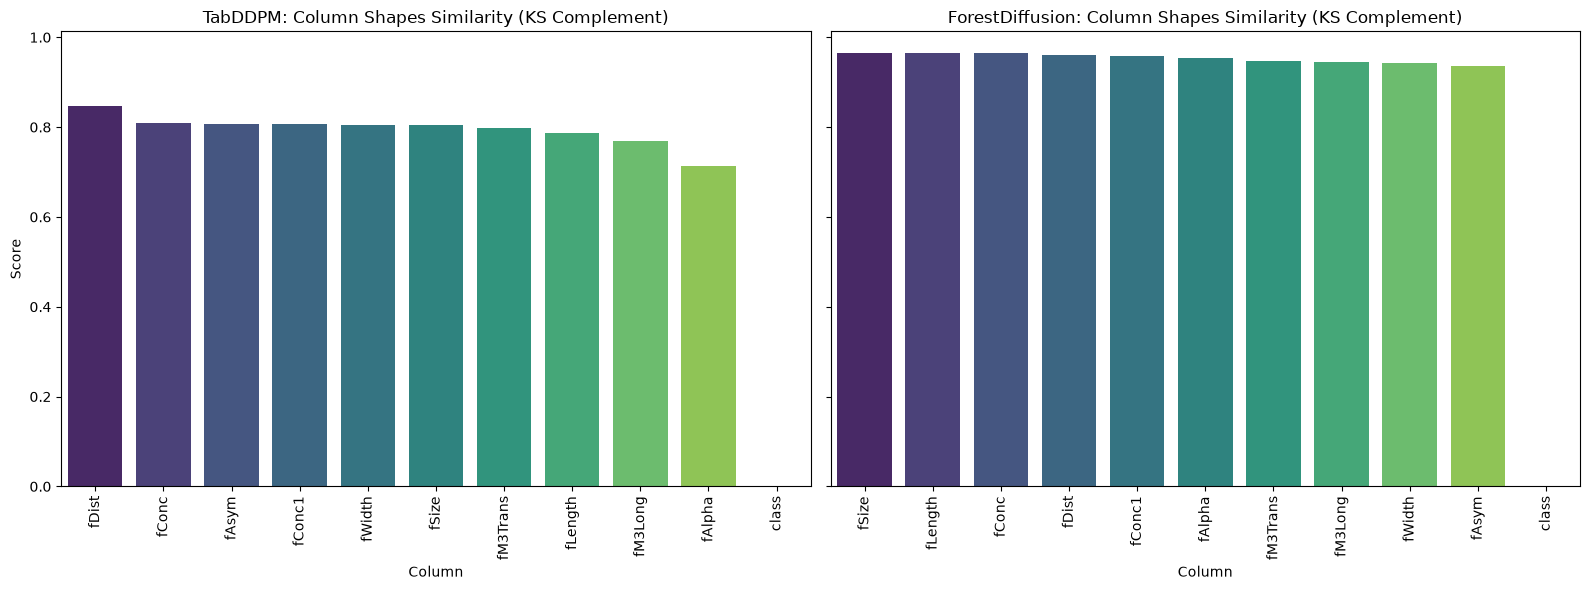

,Column,Metric,Score,Model
0,fDist,KSComplement,8.480000e-01,TabDDPM
1,fConc,KSComplement,8.090000e-01,TabDDPM
2,fAsym,KSComplement,8.070000e-01,TabDDPM
3,fConc1,KSComplement,8.070000e-01,TabDDPM
4,fWidth,KSComplement,8.050000e-01,TabDDPM
5,fSize,KSComplement,8.050000e-01,TabDDPM
6,fM3Trans,KSComplement,7.970000e-01,TabDDPM
7,fLength,KSComplement,7.880000e-01,TabDDPM
8,fM3Long,KSComplement,7.700000e-01,TabDDPM
9,fAlpha,KSComplement,7.130000e-01,TabDDPM


In [4]:
from sdv.evaluation.single_table import QualityReport
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sdv.metadata import SingleTableMetadata

# -----------------------------
# 1. Use cleaned data (no M/F, Subject ID, etc.)
# -----------------------------

# Make sure magic_data has already dropped unwanted columns:
# magic_data = data.drop(columns=["Subject ID", "M/F", "MRI ID", "Hand"], errors="ignore")
real_data = magic_data.copy()

metadata = SingleTableMetadata()
metadata.detect_from_dataframe(real_data)

model_order = ["TabDDPM", "ForestDiffusion"]
column_shape_details = {}
summary_rows = []

for model_name in model_order:
    qr = QualityReport()

    # Use model_name as the key in synthetic_outputs
    qr.generate(
        real_data=real_data,
        synthetic_data=synthetic_outputs[model_name],
        metadata=metadata.to_dict()
    )

    details = qr.get_details("Column Shapes").sort_values("Score", ascending=False)
    column_shape_details[model_name] = details

    summary_rows.append({
        "Model": model_name,
        "Average_Column_Shapes_Score": float(details["Score"].mean())
    })

# -----------------------------
# 2. Summary table (higher is better)
# -----------------------------

summary_df = pd.DataFrame(summary_rows).sort_values("Average_Column_Shapes_Score", ascending=False)
display(summary_df)

# -----------------------------
# 3. Plot column‑shape scores per model
# -----------------------------

fig, axes = plt.subplots(1, len(model_order), figsize=(16, 6), sharey=True)

for ax, model_name in zip(axes, model_order):
    details = column_shape_details[model_name]
    sns.barplot(
        x="Column",
        y="Score",
        data=details,
        palette="viridis",
        ax=ax
    )
    ax.set_title(f"{model_name}: Column Shapes Similarity (KS Complement)")
    ax.tick_params(axis="x", rotation=90)
    ax.set_xlabel("Column")
    ax.set_ylabel("Score")

plt.tight_layout()
plt.show()

# -----------------------------
# 4. Combined details table (top 20 rows)
# -----------------------------

combined_details = pd.concat(
    [df.assign(Model=name) for name, df in column_shape_details.items()],
    ignore_index=True
)
display(combined_details.head(20))


### 1.2. Jensen–Shannon divergence


In [5]:
from pandas.api.types import is_numeric_dtype
from scipy.spatial.distance import jensenshannon
from sklearn.preprocessing import MinMaxScaler

def _prob_vectors_numeric(real, synth, bins=30, eps=1e-12):
    """Convert numeric columns into comparable probability vectors."""
    real = pd.to_numeric(real, errors='coerce').dropna().to_numpy()
    synth = pd.to_numeric(synth, errors='coerce').dropna().to_numpy()

    edges = np.histogram_bin_edges(np.concatenate([real, synth]), bins=bins)
    r_hist, _ = np.histogram(real, bins=edges)
    s_hist, _ = np.histogram(synth, bins=edges)

    r = r_hist.astype(float) + eps
    s = s_hist.astype(float) + eps
    r /= r.sum()
    s /= s.sum()
    return r, s

def _prob_vectors_categorical(real, synth, eps=1e-12):
    """Convert categorical columns into comparable probability vectors."""
    r_counts = real.astype(str).value_counts(dropna=False)
    s_counts = synth.astype(str).value_counts(dropna=False)
    keys = r_counts.index.union(s_counts.index)
    r = r_counts.reindex(keys, fill_value=0).to_numpy(dtype=float) + eps
    s = s_counts.reindex(keys, fill_value=0).to_numpy(dtype=float) + eps
    r /= r.sum()
    s /= s.sum()
    return r, s, keys

def compute_js_divergence(real_df: pd.DataFrame,
                          synth_df: pd.DataFrame,
                          bins=30,
                          normalize=True) -> pd.DataFrame:
    """
    Compute Jensen–Shannon Divergence for each column between real and synthetic data.
    Returns a DataFrame with per-feature JS divergence values.
    """
    common_cols = [c for c in real_df.columns if c in synth_df.columns]
    real = real_df[common_cols].copy()
    synth = synth_df[common_cols].copy()

    # Optional normalization for numeric columns
    if normalize:
        num_cols = [c for c in common_cols if is_numeric_dtype(real[c])]
        scaler = MinMaxScaler()
        real[num_cols] = scaler.fit_transform(real[num_cols])
        synth[num_cols] = scaler.transform(synth[num_cols])

    results = []
    for col in common_cols:
        r_col, s_col = real[col], synth[col]

        if is_numeric_dtype(r_col):
            p, q = _prob_vectors_numeric(r_col, s_col, bins=bins)
        else:
            p, q, _ = _prob_vectors_categorical(r_col, s_col)

        # Jensen-Shannon divergence (base=2 → bounded [0,1])
        js_div = jensenshannon(p, q, base=2) ** 2

        results.append({"Feature": col, "JS_Divergence": js_div})

    return pd.DataFrame(results).sort_values("JS_Divergence")


C:\Users\Gopi.Battineni\AppData\Local\Temp\ipykernel_27640\1369252291.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(
C:\Users\Gopi.Battineni\AppData\Local\Temp\ipykernel_27640\1369252291.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


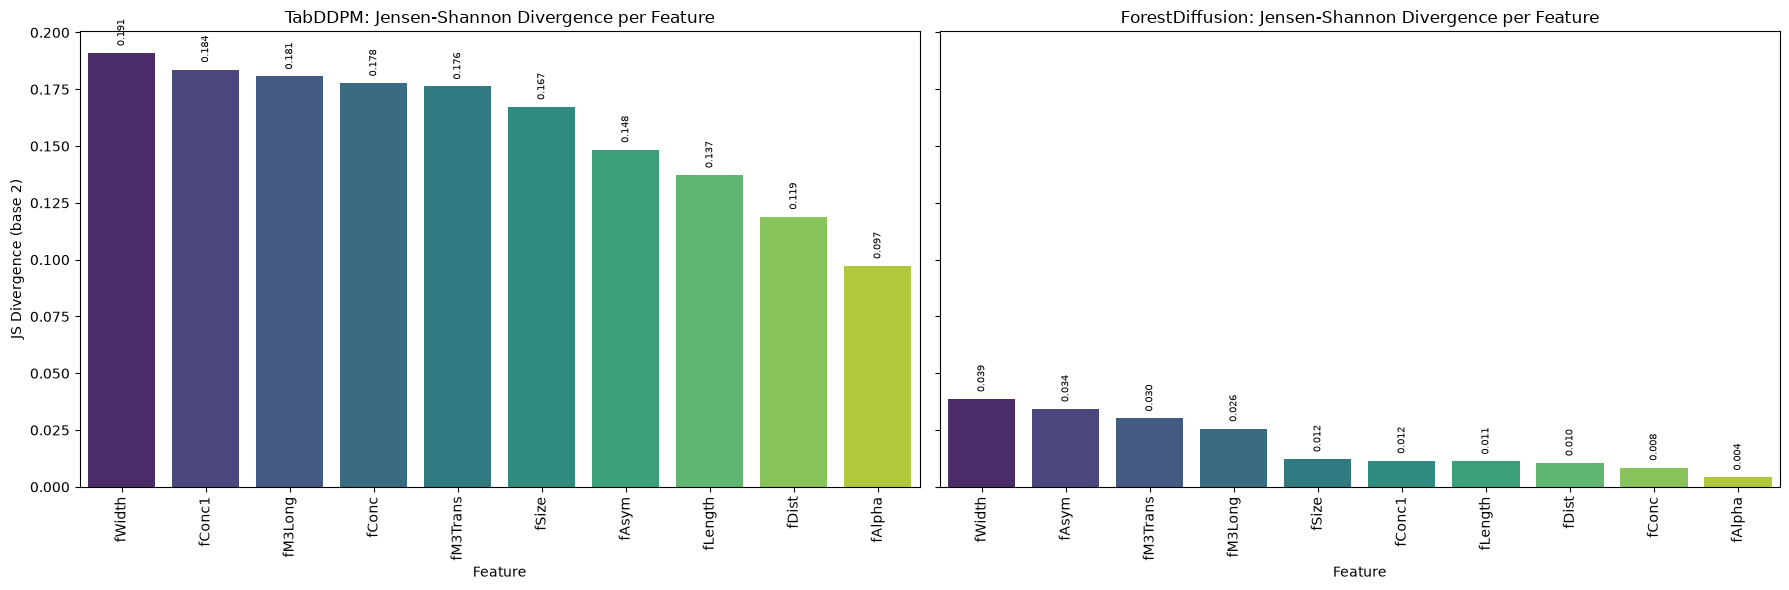

,Feature,JS_Divergence,Model
0,fWidth,0.190961,TabDDPM
1,fConc1,0.183698,TabDDPM
2,fM3Long,0.180634,TabDDPM
3,fConc,0.177629,TabDDPM
4,fM3Trans,0.176240,TabDDPM
5,fSize,0.167298,TabDDPM
6,fAsym,0.148391,TabDDPM
7,fLength,0.137247,TabDDPM
8,fDist,0.118979,TabDDPM
9,fAlpha,0.097282,TabDDPM


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# remove target column from the comparison
real_df = magic_data.drop(columns=["class"])

model_order = ["TabDDPM", "ForestDiffusion"]
js_results_by_model = {}

for model_name in model_order:
    synth_df = synthetic_outputs[model_name].drop(columns=["class"])
    js_df = compute_js_divergence(
        real_df,
        synth_df,
        bins="fd",
        normalize=True
    ).sort_values("JS_Divergence", ascending=False)
    js_results_by_model[model_name] = js_df

fig, axes = plt.subplots(1, len(model_order), figsize=(18, 6), sharey=True)

for ax, model_name in zip(axes, model_order):
    js_df = js_results_by_model[model_name]
    bars = sns.barplot(
        x="Feature",
        y="JS_Divergence",
        data=js_df,
        palette="viridis",
        ax=ax
    )

    for bar in bars.patches:
        yval = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            yval + 0.003,
            f"{yval:.3f}",
            ha="center",
            va="bottom",
            fontsize=7,
            rotation=90
        )

    ax.set_title(f"{model_name}: Jensen-Shannon Divergence per Feature")
    ax.set_xlabel("Feature")
    ax.set_ylabel("JS Divergence (base 2)")
    ax.tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

all_js = pd.concat(
    [df.assign(Model=name) for name, df in js_results_by_model.items()],
    ignore_index=True
)
display(all_js.head(20))


### 1.3 Wasserstein Distance



TabDDPM - Wasserstein Distance:
fLength: 0.1295
fWidth: 0.1278
fSize: 0.1167
fConc: 0.1006
fConc1: 0.1124
fAsym: 0.0813
fM3Long: 0.1166
fM3Trans: 0.1219
fAlpha: 0.1903
fDist: 0.0914

ForestDiffusion - Wasserstein Distance:
fLength: 0.0080
fWidth: 0.0107
fSize: 0.0110
fConc: 0.0168
fConc1: 0.0144
fAsym: 0.0072
fM3Long: 0.0108
fM3Trans: 0.0093
fAlpha: 0.0118
fDist: 0.0135

Model summary (lower is better):


,Model,Mean_Wasserstein,Median_Wasserstein,Max_Wasserstein
0,ForestDiffusion,0.01135,0.010908,0.016825
1,TabDDPM,0.11887,0.116660,0.190317


C:\Users\Gopi.Battineni\AppData\Local\Temp\ipykernel_27640\3883428140.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Gopi.Battineni\AppData\Local\Temp\ipykernel_27640\3883428140.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


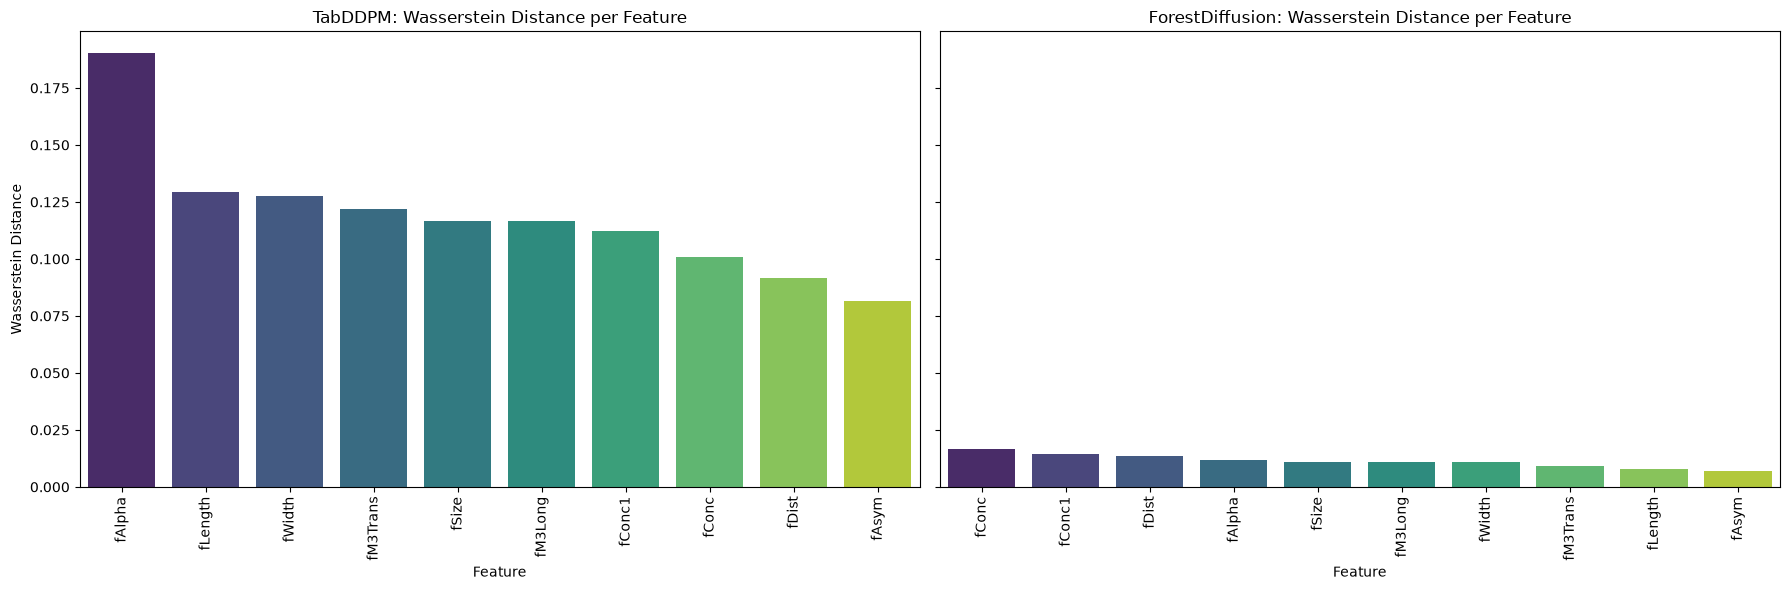

In [7]:
from scipy.stats import wasserstein_distance
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["TabDDPM", "ForestDiffusion"]

# remove target variable
real_df = magic_data.drop(columns=["class"])

scaler = MinMaxScaler()
real_scaled = pd.DataFrame(
    scaler.fit_transform(real_df),
    columns=real_df.columns
)

wasserstein_by_model = {}
summary_rows = []

for model_name in model_order:
    synth_df = synthetic_outputs[model_name].drop(columns=["class"])
    _common = [c for c in real_df.columns if c in synth_df.columns]

    synth_df = synth_df[_common]

    synthetic_scaled = pd.DataFrame(
        scaler.transform(synth_df),
        columns=synth_df.columns
    )

    dists = []
    print(f"\n{model_name} - Wasserstein Distance:")
    for col in real_df.columns:
        dist = wasserstein_distance(real_scaled[col], synthetic_scaled[col])
        dists.append((col, dist))
        print(f"{col}: {dist:.4f}")

    dist_df = pd.DataFrame(
        dists,
        columns=["Feature", "Wasserstein_Distance"]
    ).sort_values("Wasserstein_Distance", ascending=False)

    wasserstein_by_model[model_name] = dist_df

    summary_rows.append({
        "Model": model_name,
        "Mean_Wasserstein": dist_df["Wasserstein_Distance"].mean(),
        "Median_Wasserstein": dist_df["Wasserstein_Distance"].median(),
        "Max_Wasserstein": dist_df["Wasserstein_Distance"].max(),
    })

summary_df = pd.DataFrame(summary_rows).sort_values("Mean_Wasserstein").reset_index(drop=True)
print("\nModel summary (lower is better):")
display(summary_df)

fig, axes = plt.subplots(1, len(model_order), figsize=(18, 6), sharey=True)

for ax, model_name in zip(axes, model_order):
    df_plot = wasserstein_by_model[model_name]
    sns.barplot(
        x="Feature",
        y="Wasserstein_Distance",
        data=df_plot,
        palette="viridis",
        ax=ax
    )
    ax.set_title(f"{model_name}: Wasserstein Distance per Feature")
    ax.tick_params(axis="x", rotation=90)
    ax.set_xlabel("Feature")
    ax.set_ylabel("Wasserstein Distance")

plt.tight_layout()
plt.show()


### 1.4 Gower Distance


In [8]:
pip install gower

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
if 'metric_subsample_df' not in globals():
    METRIC_SAMPLE_SIZE = 2000
    METRIC_RANDOM_STATE = 42
    def metric_subsample_df(df, n_max=METRIC_SAMPLE_SIZE, random_state=METRIC_RANDOM_STATE):
        if len(df) <= n_max:
            return df.reset_index(drop=True)
        return df.sample(n=n_max, random_state=random_state).reset_index(drop=True)

import numpy as np
import pandas as pd
import gower

data = magic_data.copy()
model_order = ["TabDDPM", "ForestDiffusion"]
target_col = "class"

X_real = data.drop(columns=[target_col], errors="ignore")

gower_results = []

for model_name in model_order:
    X_synth = synthetic_outputs[model_name].drop(columns=[target_col], errors="ignore")

    common_cols = X_real.columns.intersection(X_synth.columns)
    Xr = metric_subsample_df(X_real[common_cols])
    Xs = X_synth[common_cols].reset_index(drop=True)

    gower_real = 1 - gower.gower_matrix(Xr)
    gower_synth = 1 - gower.gower_matrix(Xs)

    real_upper = gower_real[np.triu_indices_from(gower_real, k=1)]
    synth_upper = gower_synth[np.triu_indices_from(gower_synth, k=1)]

    max_intra_real = np.max(real_upper)
    avg_intra_real = np.mean(real_upper)
    max_intra_synth = np.max(synth_upper)
    avg_intra_synth = np.mean(synth_upper)

    combined = pd.concat([Xr, Xs], axis=0, ignore_index=True)
    gower_combined = 1 - gower.gower_matrix(combined)
    n_real = len(Xr)
    cross_block = gower_combined[:n_real, n_real:]

    max_cross = np.max(cross_block)
    avg_cross = np.mean(cross_block)

    print(f"\n{model_name} - Gower Similarity:")
    print("Intra-set Similarity (Real):")
    print(f"Max = {max_intra_real:.4f}, Avg = {avg_intra_real:.4f}\n")
    print("Intra-set Similarity (Synthetic):")
    print(f"Max = {max_intra_synth:.4f}, Avg = {avg_intra_synth:.4f}\n")
    print("Cross-set Similarity (Real vs Synthetic):")
    print(f"Max = {max_cross:.4f}, Avg = {avg_cross:.4f}")

    gower_results.append({
        "Model": model_name,
        "Max_Intra_Real": max_intra_real,
        "Avg_Intra_Real": avg_intra_real,
        "Max_Intra_Synth": max_intra_synth,
        "Avg_Intra_Synth": avg_intra_synth,
        "Max_Cross_Real_vs_Synth": max_cross,
        "Avg_Cross_Real_vs_Synth": avg_cross,
    })

gower_summary_df = pd.DataFrame(gower_results)
display(gower_summary_df)



TabDDPM - Gower Similarity:
Intra-set Similarity (Real):
Max = 0.9893, Avg = 0.8362

Intra-set Similarity (Synthetic):
Max = 1.0000, Avg = 0.6586

Cross-set Similarity (Real vs Synthetic):
Max = 0.9927, Avg = 0.7418

ForestDiffusion - Gower Similarity:
Intra-set Similarity (Real):
Max = 0.9893, Avg = 0.8362

Intra-set Similarity (Synthetic):
Max = 0.9922, Avg = 0.8397

Cross-set Similarity (Real vs Synthetic):
Max = 0.9984, Avg = 0.8425


,Model,Max_Intra_Real,Avg_Intra_Real,Max_Intra_Synth,Avg_Intra_Synth,Max_Cross_Real_vs_Synth,Avg_Cross_Real_vs_Synth
0,TabDDPM,0.989338,0.836157,1.00000,0.658567,0.992731,0.741751
1,ForestDiffusion,0.989338,0.836157,0.99216,0.839667,0.998441,0.842496


### 1.5 t-SNE Visualization


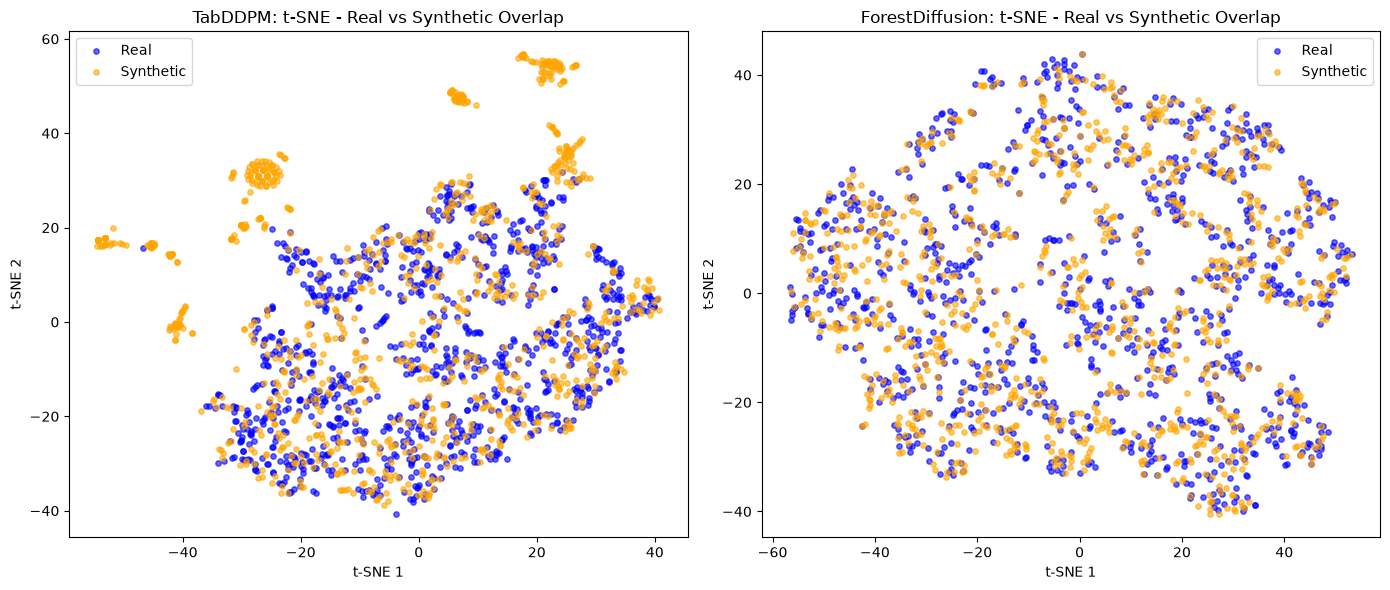

In [10]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

model_order = ["TabDDPM", "ForestDiffusion"]
target_col = "class"

# remove target from real data
X_real = data.drop(columns=[target_col], errors="ignore")

# scale real data once
scaler = MinMaxScaler()
real_scaled = pd.DataFrame(
    scaler.fit_transform(X_real),
    columns=X_real.columns
)

# create 1x2 t-SNE plots
fig, axes = plt.subplots(1, len(model_order), figsize=(14, 6))
axes = axes.flatten()

for ax, model_name in zip(axes, model_order):
    synth_df = synthetic_outputs[model_name].drop(columns=[target_col], errors="ignore")

    # keep same columns/order
    common_cols = X_real.columns.intersection(synth_df.columns)
    Xr = X_real[common_cols].reset_index(drop=True)

    synthetic_scaled = pd.DataFrame(
        scaler.transform(synth_df[common_cols]),
        columns=common_cols
    )

    combined = np.vstack([real_scaled[common_cols].values, synthetic_scaled.values])
    labels = np.array(["Real"] * len(real_scaled) + ["Synthetic"] * len(synthetic_scaled))

    tsne = TSNE(n_components=2, random_state=42)
    tsne_result = tsne.fit_transform(combined)

    ax.scatter(
        tsne_result[labels == "Real", 0],
        tsne_result[labels == "Real", 1],
        c="blue", alpha=0.6, s=15, label="Real"
    )
    ax.scatter(
        tsne_result[labels == "Synthetic", 0],
        tsne_result[labels == "Synthetic", 1],
        c="orange", alpha=0.6, s=15, label="Synthetic"
    )

    ax.set_title(f"{model_name}: t-SNE - Real vs Synthetic Overlap")
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.legend()

plt.tight_layout()
plt.show()


### 1.6 MMD (Maximum Mean Discrepancy)


In [11]:
if 'metric_subsample_df' not in globals():
    METRIC_SAMPLE_SIZE = 2000
    METRIC_RANDOM_STATE = 42
    def metric_subsample_df(df, n_max=METRIC_SAMPLE_SIZE, random_state=METRIC_RANDOM_STATE):
        if len(df) <= n_max:
            return df.reset_index(drop=True)
        return df.sample(n=n_max, random_state=random_state).reset_index(drop=True)

from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import rbf_kernel
import numpy as np
import pandas as pd

def mmd_rbf_sampled(X, Y, gamma=None):
    n, m = len(X), len(Y)
    if gamma is None:
        probe = np.vstack([X[: min(500, n)], Y[: min(500, m)]])
        d = np.sqrt(((probe[:, None, :] - probe[None, :, :]) ** 2).sum(-1))
        med = np.median(d[d > 0])
        gamma = 1.0 / (2 * (med ** 2 + 1e-12))
    Kxx = rbf_kernel(X, X, gamma=gamma)
    Kyy = rbf_kernel(Y, Y, gamma=gamma)
    Kxy = rbf_kernel(X, Y, gamma=gamma)
    term_xx = (Kxx.sum() - np.trace(Kxx)) / (n * (n - 1)) if n > 1 else 0.0
    term_yy = (Kyy.sum() - np.trace(Kyy)) / (m * (m - 1)) if m > 1 else 0.0
    return float(term_xx + term_yy - 2 * Kxy.mean())

data = magic_data.copy()
model_order = ["TabDDPM", "ForestDiffusion"]
target_col = "class"

real_features = data.drop(columns=[target_col], errors="ignore")
mmd_results = []

for model_name in model_order:
    synth_df = synthetic_outputs[model_name]
    synth_features = synth_df.drop(columns=[target_col], errors="ignore")

    common_cols = real_features.columns.intersection(synth_features.columns)
    X_real = metric_subsample_df(real_features[common_cols])
    X_synth = synth_features[common_cols].reset_index(drop=True)

    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real)
    X_synth_scaled = scaler.transform(X_synth)

    mmd_score = mmd_rbf_sampled(X_real_scaled, X_synth_scaled)
    mmd_results.append({"Model": model_name, "MMD_Score": mmd_score})
    print(f"{model_name} - MMD score (subsample n={len(X_real)}): {mmd_score:.4f}")

mmd_summary_df = pd.DataFrame(mmd_results).sort_values("MMD_Score").reset_index(drop=True)
print(f"\nMMD comparison on up to {METRIC_SAMPLE_SIZE} real rows (lower is better):")
display(mmd_summary_df)


TabDDPM - MMD score (subsample n=1000): 0.0731
ForestDiffusion - MMD score (subsample n=1000): 0.0014

MMD comparison on up to 2000 real rows (lower is better):


,Model,MMD_Score
0,ForestDiffusion,0.001385
1,TabDDPM,0.073068


### 1.7 Cosine Similarity


In [12]:
if 'metric_subsample_df' not in globals():
    METRIC_SAMPLE_SIZE = 2000
    METRIC_RANDOM_STATE = 42
    def metric_subsample_df(df, n_max=METRIC_SAMPLE_SIZE, random_state=METRIC_RANDOM_STATE):
        if len(df) <= n_max:
            return df.reset_index(drop=True)
        return df.sample(n=n_max, random_state=random_state).reset_index(drop=True)

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

model_order = ["TabDDPM", "ForestDiffusion"]
target_col = "class"

real_features = data.drop(columns=[target_col], errors="ignore")
similarity_results = []

for model_name in model_order:
    synth_df = synthetic_outputs[model_name].drop(columns=[target_col], errors="ignore")

    # Align columns/order
    common_cols = real_features.columns.intersection(synth_df.columns)
    X_real = metric_subsample_df(real_features[common_cols])
    X_synth = synth_df[common_cols].reset_index(drop=True)

    # Scale using real data stats
    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real)
    X_synth_scaled = scaler.transform(X_synth)

    # Pairwise cross similarity: all real vs all synthetic rows
    cross_sim = cosine_similarity(X_real_scaled, X_synth_scaled)
    avg_sim = np.mean(cross_sim)
    max_sim = np.max(cross_sim)

    print(f"\n{model_name} - Sample-Level Similarity:")
    print(f"Average cosine similarity: {avg_sim:.4f}")
    print(f"Maximum cosine similarity: {max_sim:.4f}")

    similarity_results.append({
        "Model": model_name,
        "Average_Cosine_Similarity": avg_sim,
        "Maximum_Cosine_Similarity": max_sim
    })

similarity_summary_df = pd.DataFrame(similarity_results).sort_values(
    "Average_Cosine_Similarity", ascending=False
).reset_index(drop=True)

print("\nCosine similarity comparison (higher means more similar):")
display(similarity_summary_df)



TabDDPM - Sample-Level Similarity:
Average cosine similarity: -0.0026
Maximum cosine similarity: 0.9954

ForestDiffusion - Sample-Level Similarity:
Average cosine similarity: 0.0257
Maximum cosine similarity: 1.0000

Cosine similarity comparison (higher means more similar):


,Model,Average_Cosine_Similarity,Maximum_Cosine_Similarity
0,ForestDiffusion,0.025724,0.999980
1,TabDDPM,-0.002602,0.995404


### 1.8 Nearest Neighbours


In [13]:
if 'metric_subsample_df' not in globals():
    METRIC_SAMPLE_SIZE = 2000
    METRIC_RANDOM_STATE = 42
    def metric_subsample_df(df, n_max=METRIC_SAMPLE_SIZE, random_state=METRIC_RANDOM_STATE):
        if len(df) <= n_max:
            return df.reset_index(drop=True)
        return df.sample(n=n_max, random_state=random_state).reset_index(drop=True)

from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

model_order = ["TabDDPM", "ForestDiffusion"]
target_col = "class"

real_features = data.drop(columns=[target_col], errors="ignore")
privacy_rows = []

for model_name in model_order:
    synth_df = synthetic_outputs[model_name].drop(columns=[target_col], errors="ignore")

    # Align columns/order
    common_cols = real_features.columns.intersection(synth_df.columns)
    X_real = metric_subsample_df(real_features[common_cols])
    X_synth = synth_df[common_cols].reset_index(drop=True)

    # Scale using real data statistics
    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real)
    X_synth_scaled = scaler.transform(X_synth)

    # Nearest-neighbor privacy check: Synthetic -> Real
    nn = NearestNeighbors(n_neighbors=1).fit(X_real_scaled)
    distances, _ = nn.kneighbors(X_synth_scaled)

    avg_nn_dist = np.mean(distances)
    min_nn_dist = np.min(distances)
    p5_nn_dist = np.percentile(distances, 5)

    print(f"\n{model_name} - Privacy Check:")
    print(f"Average NN Distance (Synthetic -> Real): {avg_nn_dist:.4f}")
    print(f"Minimum NN Distance (Synthetic -> Real): {min_nn_dist:.4f}")
    print(f"5th Percentile NN Distance: {p5_nn_dist:.4f}")

    privacy_rows.append({
        "Model": model_name,
        "Avg_NN_Distance": avg_nn_dist,
        "Min_NN_Distance": min_nn_dist,
        "P5_NN_Distance": p5_nn_dist
    })

privacy_summary_df = pd.DataFrame(privacy_rows).sort_values(
    "Avg_NN_Distance", ascending=False
).reset_index(drop=True)

print("\nPrivacy distance summary (higher generally safer):")
display(privacy_summary_df)



TabDDPM - Privacy Check:
Average NN Distance (Synthetic -> Real): 2.5395
Minimum NN Distance (Synthetic -> Real): 0.2753
5th Percentile NN Distance: 0.4918

ForestDiffusion - Privacy Check:
Average NN Distance (Synthetic -> Real): 0.7462
Minimum NN Distance (Synthetic -> Real): 0.0730
5th Percentile NN Distance: 0.3216

Privacy distance summary (higher generally safer):


,Model,Avg_NN_Distance,Min_NN_Distance,P5_NN_Distance
0,TabDDPM,2.539461,0.275261,0.491839
1,ForestDiffusion,0.746161,0.073036,0.321554


Average error by model


,Model,Mean Error %,Median Error %,Std Error %
0,TabDDPM,283.921016,61.866496,111.849351
1,ForestDiffusion,15.627090,3.100582,10.835374


C:\Users\Gopi.Battineni\AppData\Local\Temp\ipykernel_27640\2564862178.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_df, x="Model", y="Mean Error %", ax=axes[0], palette="viridis")
C:\Users\Gopi.Battineni\AppData\Local\Temp\ipykernel_27640\2564862178.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_df, x="Model", y="Median Error %", ax=axes[1], palette="viridis")
C:\Users\Gopi.Battineni\AppData\Local\Temp\ipykernel_27640\2564862178.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_df, x="Mo

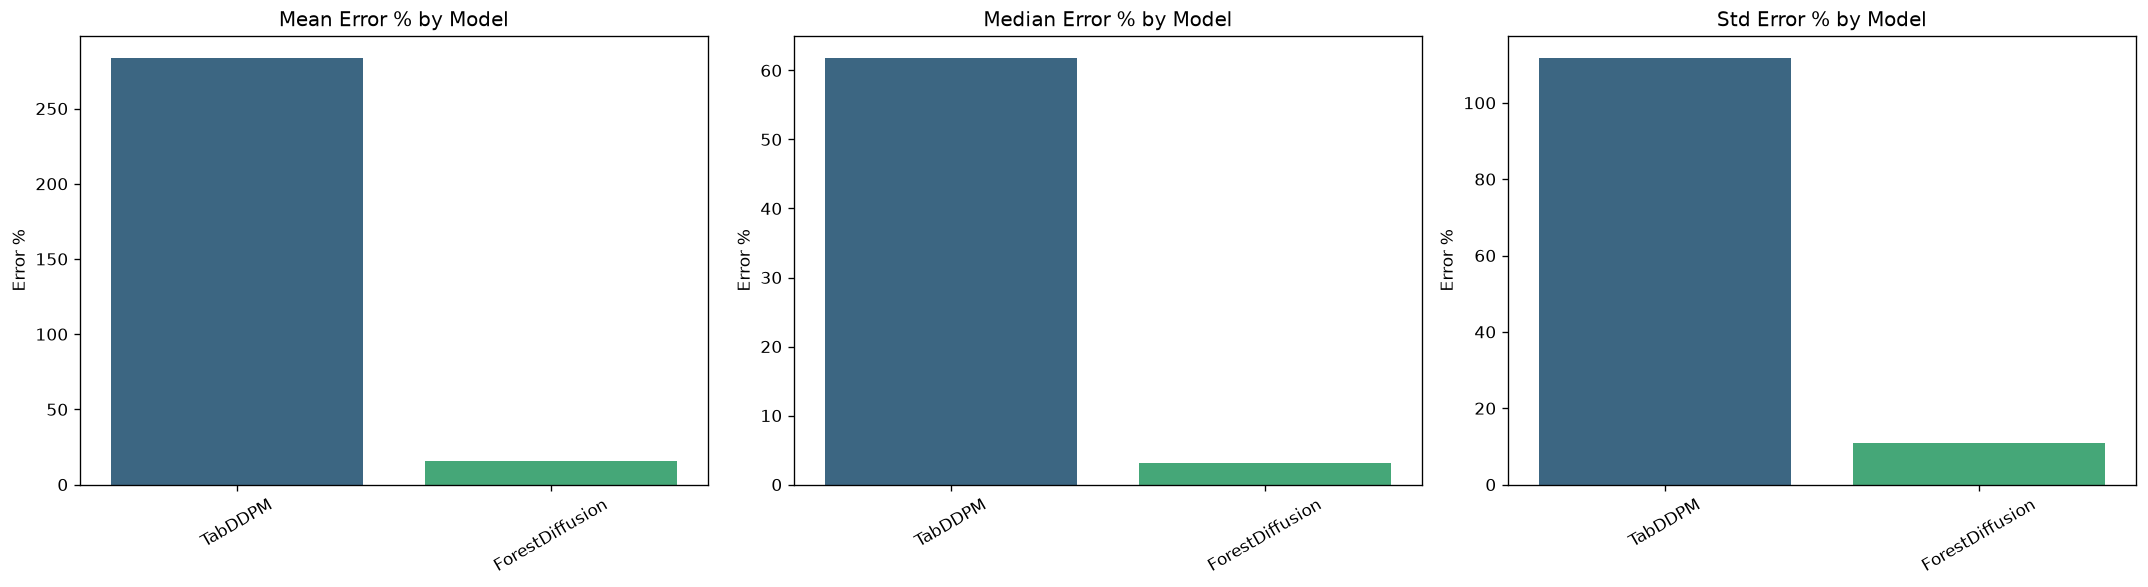

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["TabDDPM", "ForestDiffusion"]
target_col = "class"

real_df = data.copy()
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in num_cols:
    num_cols.remove(target_col)

summary_rows = []
feature_error_by_model = {}

for model_name in model_order:
    synth_df = synthetic_outputs[model_name].copy()
    _common = [c for c in real_df.columns if c in synth_df.columns]

    synth_df = synth_df[_common]

    real_means = real_df[num_cols].mean()
    synth_means = synth_df[num_cols].mean()

    real_stds = real_df[num_cols].std(ddof=1)
    synth_stds = synth_df[num_cols].std(ddof=1)

    mean_error_pct = (np.abs(synth_means - real_means) / real_means.replace(0, np.nan).abs()) * 100
    std_error_pct = (np.abs(synth_stds - real_stds) / real_stds.replace(0, np.nan).abs()) * 100

    feature_error_df = pd.DataFrame({
        "Feature": num_cols,
        "Mean_Error_%": mean_error_pct.values,
        "Std_Error_%": std_error_pct.values
    }).replace([np.inf, -np.inf], np.nan)

    model_summary = {
        "Model": model_name,
        "Mean Error %": feature_error_df["Mean_Error_%"].mean(skipna=True),
        "Median Error %": feature_error_df["Mean_Error_%"].median(skipna=True),
        "Std Error %": feature_error_df["Std_Error_%"].mean(skipna=True)
    }

    summary_rows.append(model_summary)
    feature_error_by_model[model_name] = feature_error_df

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.set_index("Model").loc[model_order].reset_index()

print("Average error by model")
display(summary_df)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=120)

sns.barplot(data=summary_df, x="Model", y="Mean Error %", ax=axes[0], palette="viridis")
axes[0].set_title("Mean Error % by Model")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(data=summary_df, x="Model", y="Median Error %", ax=axes[1], palette="viridis")
axes[1].set_title("Median Error % by Model")
axes[1].tick_params(axis="x", rotation=30)

sns.barplot(data=summary_df, x="Model", y="Std Error %", ax=axes[2], palette="viridis")
axes[2].set_title("Std Error % by Model")
axes[2].tick_params(axis="x", rotation=30)

for ax in axes:
    ax.set_xlabel("")
    ax.set_ylabel("Error %")

plt.tight_layout()
plt.show()


C:\Users\Gopi.Battineni\AppData\Local\Temp\ipykernel_27640\521707326.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x="Model", y="Mean Error %", palette="viridis")


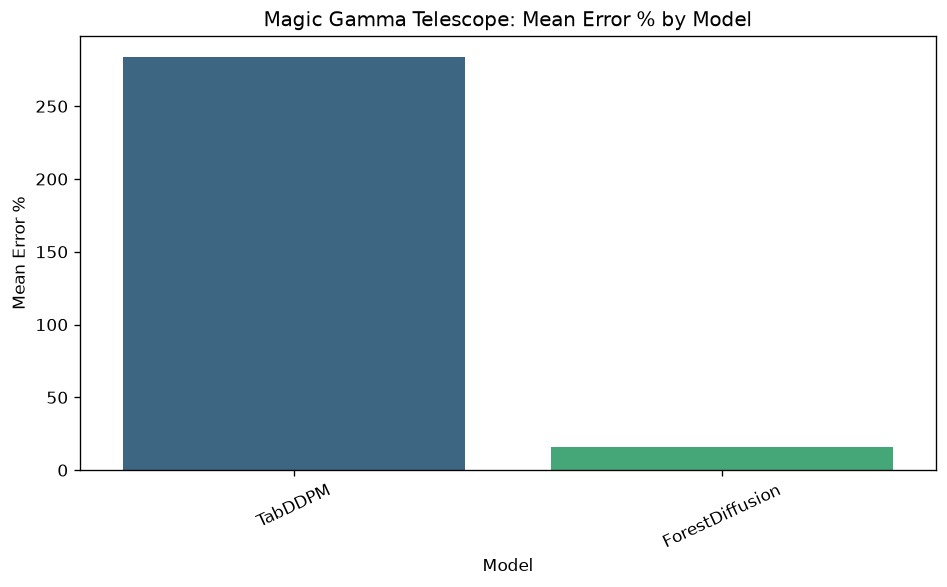

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = summary_df[["Model", "Mean Error %"]].copy()

plt.figure(figsize=(8, 5), dpi=120)
sns.barplot(data=plot_df, x="Model", y="Mean Error %", palette="viridis")
plt.title("Magic Gamma Telescope: Mean Error % by Model")
plt.xlabel("Model")
plt.ylabel("Mean Error %")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()


C:\Users\Gopi.Battineni\AppData\Local\Temp\ipykernel_27640\1932673921.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dist_df, x="Model", y="Mean_Error_%", palette="viridis")


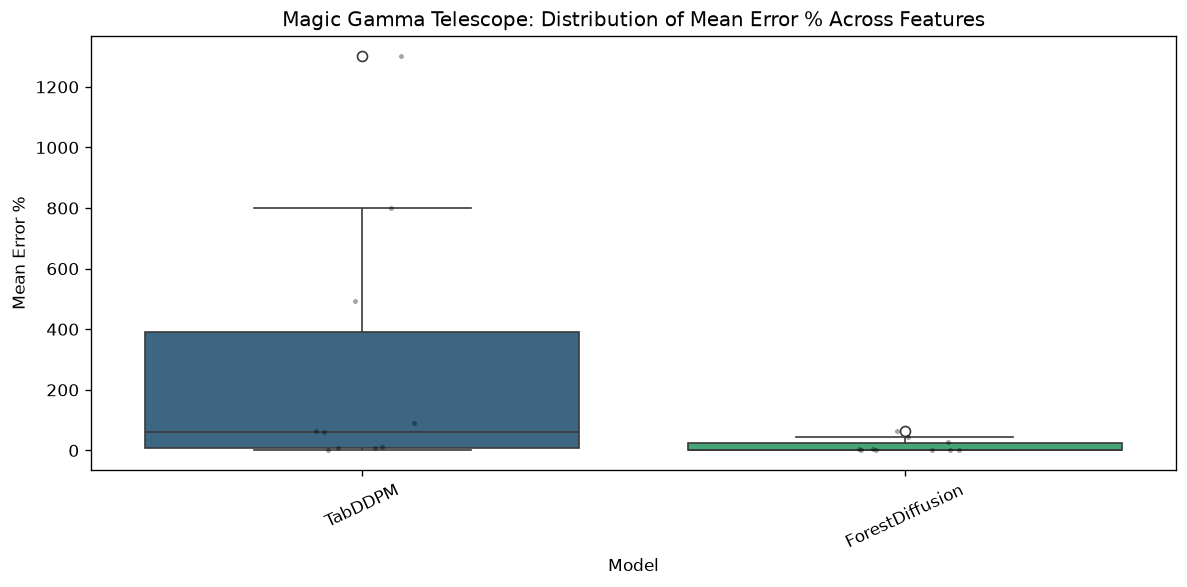

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_list = ["TabDDPM", "ForestDiffusion"]
target_col = "class"

dist_df = pd.concat(
    [
        feature_error_by_model[m][["Feature", "Mean_Error_%"]].assign(Model=m)
        for m in model_list
        if m in feature_error_by_model
    ],
    ignore_index=True
).replace([float("inf"), float("-inf")], pd.NA).dropna(subset=["Mean_Error_%"])

plt.figure(figsize=(10, 5), dpi=120)
sns.boxplot(data=dist_df, x="Model", y="Mean_Error_%", palette="viridis")
sns.stripplot(data=dist_df, x="Model", y="Mean_Error_%", color="black", alpha=0.35, size=3)
plt.title("Magic Gamma Telescope: Distribution of Mean Error % Across Features")
plt.xlabel("Model")
plt.ylabel("Mean Error %")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()


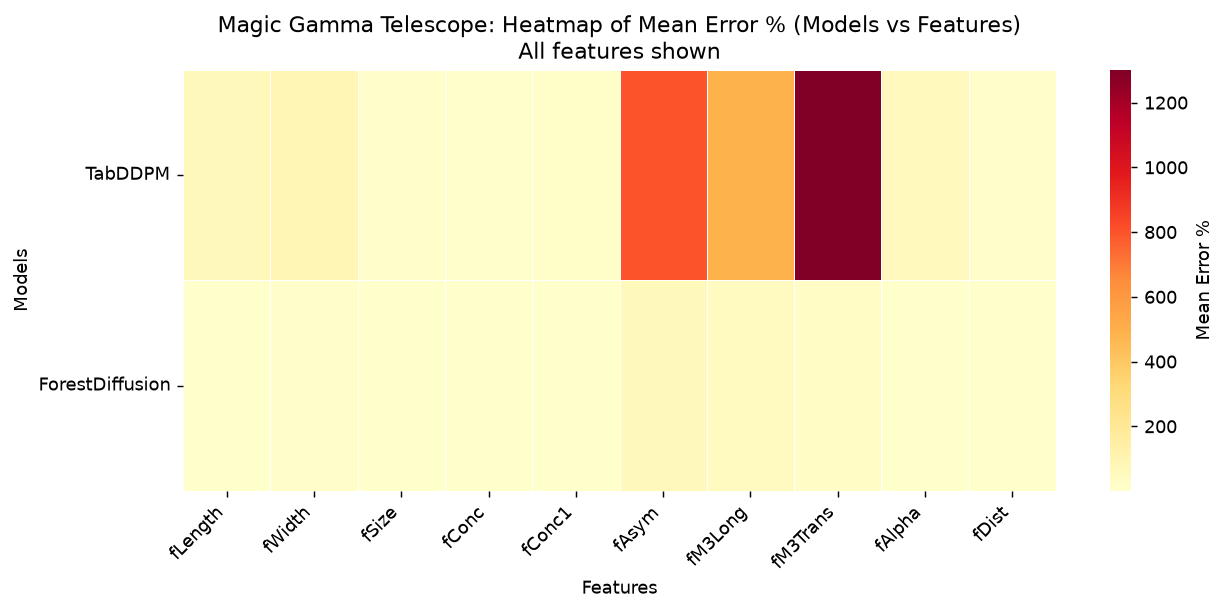

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["TabDDPM", "ForestDiffusion"]

heatmap_df = pd.DataFrame({
    m: feature_error_by_model[m].set_index("Feature")["Mean_Error_%"]
    for m in model_order
    if m in feature_error_by_model
}).T

heatmap_df = heatmap_df.replace([np.inf, -np.inf], np.nan)

max_features = 20
if heatmap_df.shape[1] > max_features:
    top_features = heatmap_df.mean(axis=0, skipna=True).sort_values(ascending=False).head(max_features).index
    heatmap_plot_df = heatmap_df[top_features]
    truncated_note = f"Top {max_features} features shown (of {heatmap_df.shape[1]} total)"
else:
    heatmap_plot_df = heatmap_df.copy()
    truncated_note = "All features shown"

def truncate_label(s, max_len=18):
    s = str(s)
    return s if len(s) <= max_len else s[:max_len - 1] + "..."

display_labels = [truncate_label(c, max_len=18) for c in heatmap_plot_df.columns]

plt.figure(figsize=(max(10, 0.55 * len(display_labels)), 4.8), dpi=130)
sns.heatmap(
    heatmap_plot_df,
    cmap="YlOrRd",
    annot=False,
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "Mean Error %"}
)

plt.title(f"Magic Gamma Telescope: Heatmap of Mean Error % (Models vs Features)\n{truncated_note}")
plt.xlabel("Features")
plt.ylabel("Models")
plt.xticks(np.arange(len(display_labels)) + 0.5, display_labels, rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


# 2 Bivariate Analysis


In [18]:
from itertools import combinations
from scipy import stats
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np

def bivariate_quality_cancer(real_df, synth_df, target=None):
    """Compute bivariate quality metrics for cancer data."""

    if target is None:
        for cand in ["class", "Class", "Group", "target", "Target"]:
            if cand in real_df.columns:
                target = cand
                break

    if target is None or target not in real_df.columns or target not in synth_df.columns:
        raise KeyError("Target column not found in both real_df and synth_df.")

    num_cols = [
        c for c in real_df.columns
        if c != target and pd.api.types.is_numeric_dtype(real_df[c]) and pd.api.types.is_numeric_dtype(synth_df[c])
    ]

    scaler = MinMaxScaler()
    real_scaled = real_df.copy()
    synth_scaled = synth_df.copy()

    real_scaled[num_cols] = scaler.fit_transform(real_df[num_cols])
    synth_scaled[num_cols] = scaler.transform(synth_df[num_cols])

    results_corr = []
    results_target = []

    for a, b in combinations(num_cols, 2):
        r_corr = real_scaled[[a, b]].corr().iloc[0, 1]
        s_corr = synth_scaled[[a, b]].corr().iloc[0, 1]
        results_corr.append({
            "var_a": a,
            "var_b": b,
            "delta_corr": abs(r_corr - s_corr)
        })

    for col in num_cols:
        r_groups = [g[col].values for _, g in real_scaled.groupby(target)]
        s_groups = [g[col].values for _, g in synth_scaled.groupby(target)]

        if len(r_groups) == 2 and len(s_groups) == 2:
            d_real = stats.wasserstein_distance(*r_groups)
            d_synth = stats.wasserstein_distance(*s_groups)
            results_target.append({
                "feature": col,
                "delta_wasserstein": abs(d_real - d_synth)
            })

    corr_df = pd.DataFrame(results_corr).sort_values("delta_corr", ascending=False)
    target_df = pd.DataFrame(results_target).sort_values("delta_wasserstein", ascending=False)

    return corr_df, target_df


In [19]:
import pandas as pd
import numpy as np

model_order = ["TabDDPM", "ForestDiffusion"]

possible_targets = ["class", "Class", "Group", "target", "Target"]
target_col = next((c for c in possible_targets if c in data.columns), None)

if target_col is None:
    raise KeyError(f"No target column found in data. Available columns: {list(data.columns)}")

real_df = data.copy()

all_corr_results = {}
all_target_results = {}
summary_rows = []

for model_name in model_order:
    synth_df = synthetic_outputs[model_name].copy()

    # keep target column if it exists, but align numeric features separately inside the function
    if target_col not in synth_df.columns:
        raise KeyError(f"{target_col} not found in synthetic data for {model_name}")

    corr_results, target_results = bivariate_quality_cancer(
        real_df=real_df,
        synth_df=synth_df,
        target=target_col
    )

    all_corr_results[model_name] = corr_results
    all_target_results[model_name] = target_results

    print(f"\n{model_name} - Largest differences in pairwise correlations:")
    display(corr_results.head(10))
    print("=" * 60)
    print(f"{model_name} - Features that differ most by class (gamma/hadron):")
    display(target_results.head(10))
    print("=" * 60)

    corr_metric_col = next((c for c in ["delta_corr", "AbsDiff", "abs_diff", "Difference", "diff"] if c in corr_results.columns), None)
    target_metric_col = next((c for c in ["delta_wasserstein", "AbsDiff", "abs_diff", "Difference", "diff"] if c in target_results.columns), None)

    summary_rows.append({
        "Model": model_name,
        "TopCorrDiff": corr_results[corr_metric_col].iloc[0] if corr_metric_col and not corr_results.empty else None,
        "MeanTop10CorrDiff": corr_results[corr_metric_col].head(10).mean() if corr_metric_col and not corr_results.empty else None,
        "TopTargetDiff": target_results[target_metric_col].iloc[0] if target_metric_col and not target_results.empty else None,
        "MeanTop10TargetDiff": target_results[target_metric_col].head(10).mean() if target_metric_col and not target_results.empty else None,
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)



TabDDPM - Largest differences in pairwise correlations:


,var_a,var_b,delta_corr
34,fConc1,fDist,0.649311
23,fSize,fDist,0.620552
29,fConc,fDist,0.617662
16,fWidth,fDist,0.523025
37,fAsym,fAlpha,0.503147
8,fLength,fDist,0.449281
40,fM3Long,fAlpha,0.420551
7,fLength,fAlpha,0.417100
35,fAsym,fM3Long,0.399456
38,fAsym,fDist,0.382963


TabDDPM - Features that differ most by class (gamma/hadron):


,feature,delta_wasserstein
8,fAlpha,0.249601
0,fLength,0.097939
6,fM3Long,0.043862
1,fWidth,0.043467
2,fSize,0.025841
9,fDist,0.025261
5,fAsym,0.023536
4,fConc1,0.002289
3,fConc,0.000589
7,fM3Trans,0.000406



ForestDiffusion - Largest differences in pairwise correlations:


,var_a,var_b,delta_corr
5,fLength,fM3Long,0.188133
20,fSize,fM3Long,0.178911
35,fAsym,fM3Long,0.161474
39,fM3Long,fM3Trans,0.160319
26,fConc,fM3Long,0.135160
31,fConc1,fM3Long,0.130468
13,fWidth,fM3Long,0.110814
4,fLength,fAsym,0.089119
12,fWidth,fAsym,0.078793
23,fSize,fDist,0.072587


ForestDiffusion - Features that differ most by class (gamma/hadron):


,feature,delta_wasserstein
8,fAlpha,0.031298
1,fWidth,0.024068
2,fSize,0.020698
0,fLength,0.020352
6,fM3Long,0.019868
7,fM3Trans,0.012812
5,fAsym,0.010996
9,fDist,0.010707
3,fConc,0.007423
4,fConc1,0.005963


,Model,TopCorrDiff,MeanTop10CorrDiff,TopTargetDiff,MeanTop10TargetDiff
0,TabDDPM,0.649311,0.498305,0.249601,0.051279
1,ForestDiffusion,0.188133,0.130578,0.031298,0.016418


### 3 Multivariate Analysis


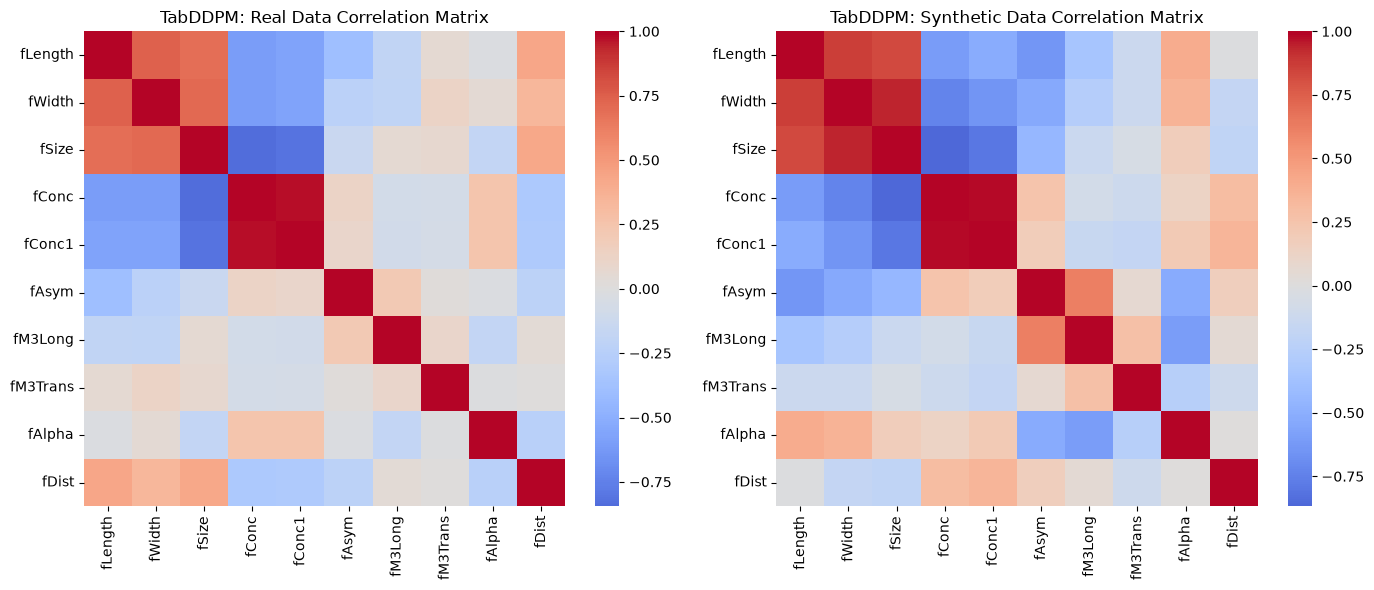

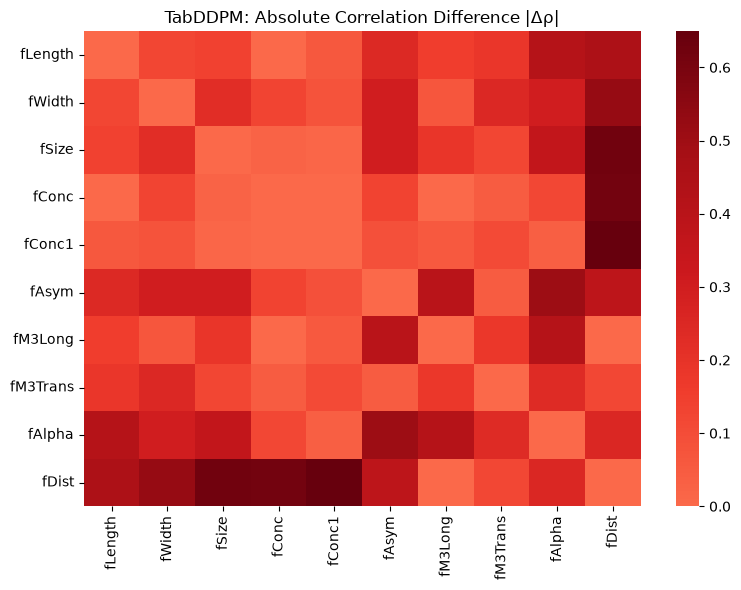

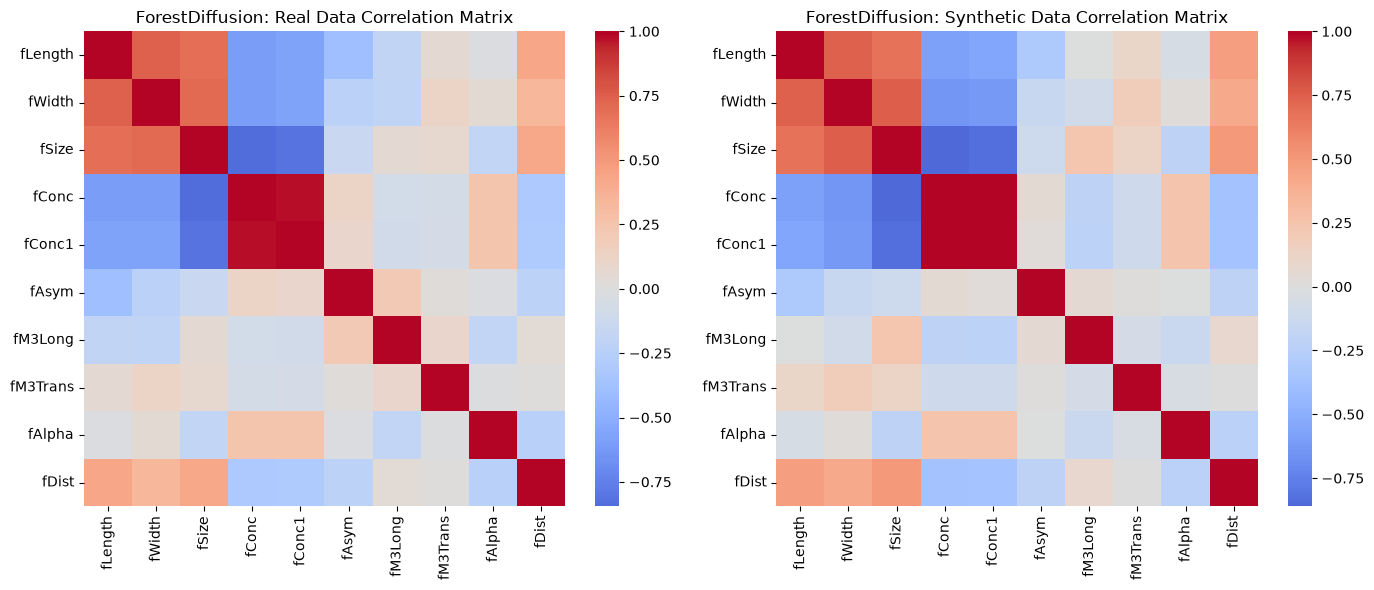

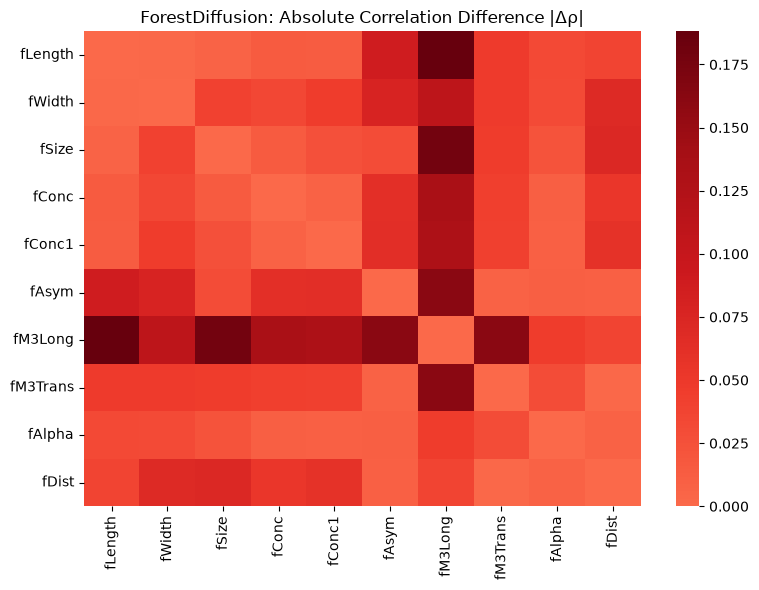

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

model_order = ["TabDDPM", "ForestDiffusion"]

target_col = "class"

real_df = data.copy()
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()

# remove target if it ended up in numeric columns
if target_col in num_cols:
    num_cols.remove(target_col)

real_corr = real_df[num_cols].corr()

for model_name in model_order:
    synth_df = synthetic_outputs[model_name].copy()

    # align columns safely
    common_cols = real_df.columns.intersection(synth_df.columns)
    synth_df = synth_df[common_cols]

    # keep only numeric columns for correlation
    synth_num_cols = [c for c in num_cols if c in synth_df.columns]
    synth_corr = synth_df[synth_num_cols].corr()

    # make sure both matrices use the same order
    common_num_cols = [c for c in num_cols if c in synth_corr.columns]
    real_corr_plot = real_corr.loc[common_num_cols, common_num_cols]
    synth_corr_plot = synth_corr.loc[common_num_cols, common_num_cols]

    # 1) Real vs Synthetic correlation matrices
    fig, axes = plt.subplots(1, len(model_order), figsize=(14, 6))
    sns.heatmap(real_corr_plot, cmap="coolwarm", center=0, ax=axes[0])
    axes[0].set_title(f"{model_name}: Real Data Correlation Matrix")

    sns.heatmap(synth_corr_plot, cmap="coolwarm", center=0, ax=axes[1])
    axes[1].set_title(f"{model_name}: Synthetic Data Correlation Matrix")

    plt.tight_layout()
    plt.show()

    # 2) Absolute correlation difference heatmap
    diff_corr = (real_corr_plot - synth_corr_plot).abs()
    plt.figure(figsize=(8, 6))
    sns.heatmap(diff_corr, cmap="Reds", center=0)
    plt.title(f"{model_name}: Absolute Correlation Difference |Δρ|")
    plt.tight_layout()
    plt.show()



TabDDPM - Global MMD (RBF): 0.066392


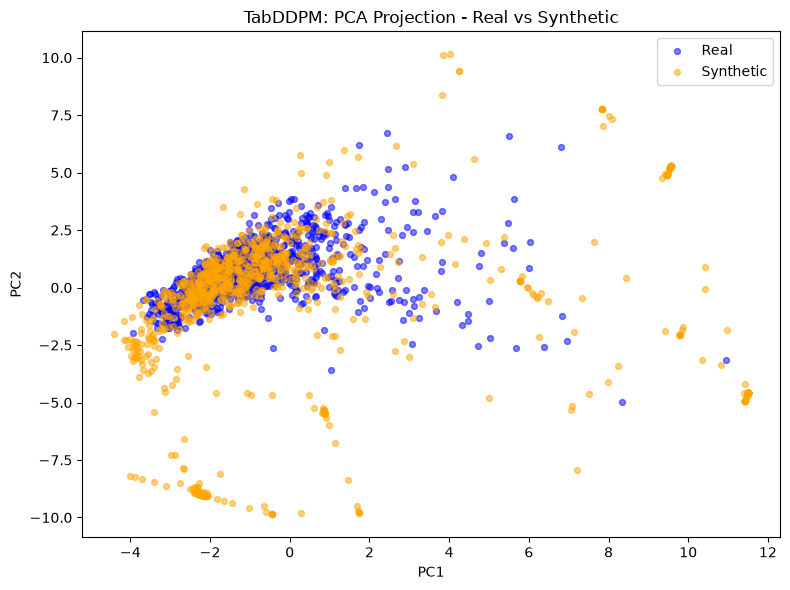

TabDDPM - Two-Sample Classifier Accuracy: 0.7000

ForestDiffusion - Global MMD (RBF): 0.001326


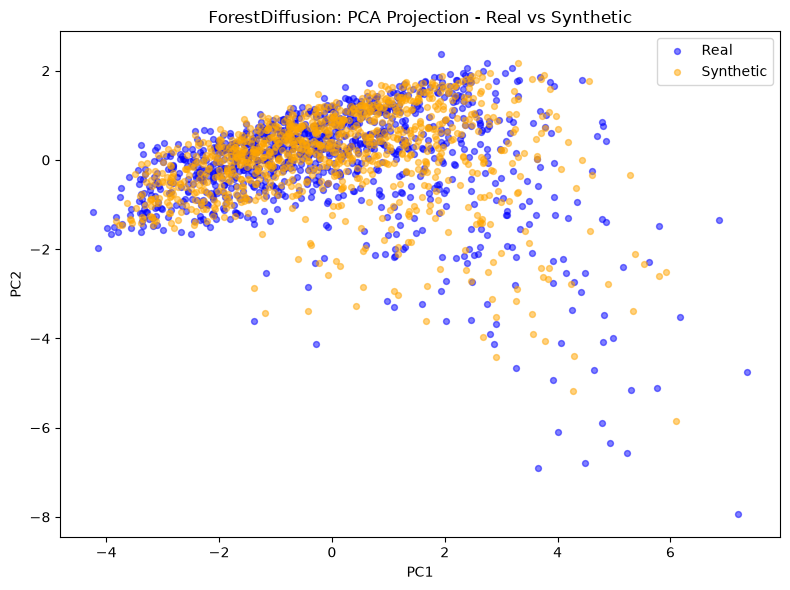

ForestDiffusion - Two-Sample Classifier Accuracy: 0.5650

Summary (lower MMD and lower C2ST accuracy generally indicate better overlap):


,Model,Global_MMD_RBF,C2ST_Accuracy
0,ForestDiffusion,0.001326,0.565
1,TabDDPM,0.066392,0.700


In [21]:
if 'metric_subsample_df' not in globals():
    METRIC_SAMPLE_SIZE = 2000
    METRIC_RANDOM_STATE = 42
    def metric_subsample_df(df, n_max=METRIC_SAMPLE_SIZE, random_state=METRIC_RANDOM_STATE):
        if len(df) <= n_max:
            return df.reset_index(drop=True)
        return df.sample(n=n_max, random_state=random_state).reset_index(drop=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

model_order = ["TabDDPM", "ForestDiffusion"]

def mmd_rbf(X, Y, gamma=None):
    if gamma is None:
        Z = np.vstack([X, Y])
        probe = Z[: min(1000, len(Z))]
        dists = np.sqrt(((probe[:, None, :] - probe[None, :, :]) ** 2).sum(-1))
        med = np.median(dists[dists > 0])
        gamma = 1.0 / (2 * (med ** 2)) if med > 0 else 1.0
    Kxx = rbf_kernel(X, X, gamma=gamma)
    Kyy = rbf_kernel(Y, Y, gamma=gamma)
    Kxy = rbf_kernel(X, Y, gamma=gamma)
    n, m = len(X), len(Y)
    return ((Kxx.sum() - np.trace(Kxx)) / (n * (n - 1))
            + (Kyy.sum() - np.trace(Kyy)) / (m * (m - 1))
            - 2 * Kxy.mean())

target_col = "class"
X_real_df = data.drop(columns=[target_col], errors="ignore")
X_real_df = X_real_df.select_dtypes(include=[np.number])

results = []

for model_name in model_order:
    synth_df = synthetic_outputs[model_name].copy()
    synth_df = synth_df.drop(columns=[target_col], errors="ignore")
    synth_df = synth_df.select_dtypes(include=[np.number])

    common_cols = X_real_df.columns.intersection(synth_df.columns)
    X_real = metric_subsample_df(X_real_df[common_cols]).values
    X_synth = synth_df[common_cols].values

    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real)
    X_synth_scaled = scaler.transform(X_synth)

    mmd_value = mmd_rbf(X_real_scaled, X_synth_scaled)
    print(f"\n{model_name} - Global MMD (RBF): {mmd_value:.6f}")

    pca = PCA(n_components=2, random_state=42)
    X_all = np.vstack([X_real_scaled, X_synth_scaled])
    labels = np.array(["Real"] * len(X_real_scaled) + ["Synthetic"] * len(X_synth_scaled))
    X_pca = pca.fit_transform(X_all)

    plt.figure(figsize=(8, 6))
    plt.scatter(X_pca[labels == "Real", 0], X_pca[labels == "Real", 1],
                color="blue", alpha=0.5, label="Real", s=18)
    plt.scatter(X_pca[labels == "Synthetic", 0], X_pca[labels == "Synthetic", 1],
                color="orange", alpha=0.5, label="Synthetic", s=18)
    plt.title(f"{model_name}: PCA Projection - Real vs Synthetic")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.tight_layout()
    plt.show()

    y_real = np.ones(len(X_real_scaled))
    y_synth = np.zeros(len(X_synth_scaled))
    X_c2st = np.vstack([X_real_scaled, X_synth_scaled])
    y_c2st = np.hstack([y_real, y_synth])

    X_train, X_test, y_train, y_test = train_test_split(
        X_c2st, y_c2st, test_size=0.3, stratify=y_c2st, random_state=42
    )

    clf = RandomForestClassifier(n_estimators=200, random_state=42)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print(f"{model_name} - Two-Sample Classifier Accuracy: {acc:.4f}")

    results.append({
        "Model": model_name,
        "Global_MMD_RBF": mmd_value,
        "C2ST_Accuracy": acc
    })

results_df = pd.DataFrame(results).sort_values("Global_MMD_RBF").reset_index(drop=True)
print("\nSummary (lower MMD and lower C2ST accuracy generally indicate better overlap):")
display(results_df)


# 4 Utility with 10 classifiers


In [22]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

models = {
    "LogReg": LogisticRegression(max_iter=5000, solver="liblinear", random_state=42),
    "SVM-RBF": SVC(kernel="rbf", probability=True, random_state=42),
    "KNN": KNeighborsClassifier(),
    "NaiveBayes": GaussianNB(),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(random_state=42),
    "ExtraTrees": ExtraTreesClassifier(random_state=42),
    "GradientBoost": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "MLP": MLPClassifier(max_iter=2000, random_state=42),
}

def evaluate_models(train_df, test_df, label_col, models=models, test_size=0.2, seed=42):
    def _coerce_class_labels(y):
        y = pd.Series(y).copy()
        text_map = {
            "Demented": 1, "Nondemented": 0, "Converted": 1,
            "g": 1, "h": 0, "B": 0, "M": 1,
        }
        if y.dtype == object or str(y.dtype) == "string":
            mapped = y.astype(str).str.strip().map(text_map)
            if mapped.notna().sum() >= max(1, int(0.5 * len(y))):
                y = mapped
            else:
                y = pd.to_numeric(y, errors="coerce")
        else:
            y = pd.to_numeric(y, errors="coerce")
        return y.round()

    def _prepare_xy(df):
        X = df.drop(columns=[label_col])
        y = _coerce_class_labels(df[label_col])
        mask = y.notna()
        return X.loc[mask], y.loc[mask].astype(int)

    X_train, y_train = _prepare_xy(train_df)
    X_test, y_test = _prepare_xy(test_df)

    strat_train = y_train if y_train.nunique() > 1 else None
    strat_test = y_test if y_test.nunique() > 1 else None

    X_train, _, y_train, _ = train_test_split(
        X_train, y_train, test_size=test_size, random_state=seed, stratify=strat_train
    )
    _, X_test, _, y_test = train_test_split(
        X_test, y_test, test_size=test_size, random_state=seed, stratify=strat_test
    )

    scaler = StandardScaler().fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_test_s = scaler.transform(X_test)

    rows = []
    for name, clf in models.items():
        clf.fit(X_train_s, y_train)
        y_pred = clf.predict(X_test_s)

        if hasattr(clf, "predict_proba"):
            y_prob = clf.predict_proba(X_test_s)[:, 1]
        elif hasattr(clf, "decision_function"):
            scores = clf.decision_function(X_test_s)
            y_prob = (scores - scores.min()) / (scores.max() - scores.min() + 1e-12)
        else:
            y_prob = None

        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_prob) if y_prob is not None else float("nan")

        rows.append({"Model": name, "Accuracy": acc, "F1": f1, "AUC": auc})

    return pd.DataFrame(rows).sort_values(by="AUC", ascending=False)


In [23]:
import pandas as pd

label_col = "class"

# Only the models you actually trained
model_order = ["TabDDPM", "ForestDiffusion"]

# First: evaluate on real data (TRTR)
trtr_results = evaluate_models(
    train_df=magic_data,
    test_df=magic_data,
    label_col=label_col,
    models=models
)

print("TRTR (Train Real, Test Real)")
display(trtr_results)
print("=" * 70)

all_comparisons = []

for synth_name in model_order:
    # Evaluate: train on synthetic, test on real (TSTR)
    tstr_results = evaluate_models(
        train_df=synthetic_outputs[synth_name],
        test_df=magic_data,
        label_col=label_col,
        models=models
    )

    print(f"{synth_name} - TSTR (Train Synthetic, Test Real)")
    display(tstr_results)

    # Compare with TRTR performance
    comparison = trtr_results.merge(
        tstr_results, on="Model", suffixes=("_TRTR", "_TSTR")
    )

    # AUC drop (loss of predictive power when training on synthetic)
    comparison["AUC_Drop"] = comparison["AUC_TRTR"] - comparison["AUC_TSTR"]

    # Optional drops if columns exist
    if "F1_TRTR" in comparison.columns and "F1_TSTR" in comparison.columns:
        comparison["F1_Drop"] = comparison["F1_TRTR"] - comparison["F1_TSTR"]

    if "Accuracy_TRTR" in comparison.columns and "Accuracy_TSTR" in comparison.columns:
        comparison["Accuracy_Drop"] = comparison["Accuracy_TRTR"] - comparison["Accuracy_TSTR"]

    comparison["Synthetic_Model"] = synth_name
    comparison = comparison.sort_values("AUC_Drop", ascending=False)

    print(f"{synth_name} - TRTR vs TSTR Comparison")
    display(comparison)
    print("=" * 70)

    all_comparisons.append(comparison)

# Combine all synthetic‑model comparisons into one table
combined_comparison = pd.concat(all_comparisons, ignore_index=True)

# Summary: average AUC drop by synthetic model (lower = better)
summary = (
    combined_comparison
    .groupby("Synthetic_Model", as_index=False)["AUC_Drop"]
    .mean()
    .sort_values("AUC_Drop")
)

print("Average AUC drop by synthetic generator (lower is better):")
display(summary)


c:\Users\Gopi.Battineni\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


TRTR (Train Real, Test Real)


c:\Users\Gopi.Battineni\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(


,Model,Accuracy,F1,AUC
5,RandomForest,0.860,0.898551,0.897610
6,ExtraTrees,0.855,0.896057,0.894734
1,SVM-RBF,0.865,0.905263,0.892245
7,GradientBoost,0.840,0.884058,0.878748
8,AdaBoost,0.835,0.879121,0.861434
9,MLP,0.805,0.855019,0.842129
0,LogReg,0.830,0.878571,0.829959
2,KNN,0.830,0.880282,0.821551
3,NaiveBayes,0.770,0.840278,0.781724
4,DecisionTree,0.805,0.857143,0.765405


c:\Users\Gopi.Battineni\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


...

,Model,Accuracy,F1,AUC
5,RandomForest,0.830,0.875000,0.862872
1,SVM-RBF,0.885,0.918728,0.862374
6,ExtraTrees,0.865,0.904594,0.855017
7,GradientBoost,0.810,0.862319,0.851200
8,AdaBoost,0.795,0.850909,0.837703
0,LogReg,0.830,0.878571,0.834827
9,MLP,0.805,0.852830,0.824317
2,KNN,0.820,0.875862,0.802578
3,NaiveBayes,0.765,0.833922,0.785706
4,DecisionTree,0.755,0.810811,0.734097


ForestDiffusion - TRTR vs TSTR Comparison


,Model,Accuracy_TRTR,F1_TRTR,AUC_TRTR,Accuracy_TSTR,F1_TSTR,AUC_TSTR,AUC_Drop,F1_Drop,Accuracy_Drop,Synthetic_Model
1,ExtraTrees,0.855,0.896057,0.894734,0.865,0.904594,0.855017,0.039717,-0.008536,-0.010,ForestDiffusion
0,RandomForest,0.860,0.898551,0.897610,0.830,0.875000,0.862872,0.034738,0.023551,0.030,ForestDiffusion
9,DecisionTree,0.805,0.857143,0.765405,0.755,0.810811,0.734097,0.031309,0.046332,0.050,ForestDiffusion
2,SVM-RBF,0.865,0.905263,0.892245,0.885,0.918728,0.862374,0.029871,-0.013465,-0.020,ForestDiffusion
3,GradientBoost,0.840,0.884058,0.878748,0.810,0.862319,0.851200,0.027547,0.021739,0.030,ForestDiffusion
4,AdaBoost,0.835,0.879121,0.861434,0.795,0.850909,0.837703,0.023731,0.028212,0.040,ForestDiffusion
7,KNN,0.830,0.880282,0.821551,0.820,0.875862,0.802578,0.018973,0.004420,0.010,ForestDiffusion
5,MLP,0.805,0.855019,0.842129,0.805,0.852830,0.824317,0.017812,0.002188,0.000,ForestDiffusion
8,NaiveBayes,0.770,0.840278,0.781724,0.765,0.833922,0.785706,-0.003983,0.006356,0.005,ForestDiffusion
6,LogReg,0.830,0.878571,0.829959,0.830,0.878571,0.834827,-0.004868,0.000000,0.000,ForestDiffusion


Average AUC drop by synthetic generator (lower is better):


,Synthetic_Model,AUC_Drop
0,ForestDiffusion,0.021485
1,TabDDPM,0.308674


c:\Users\Gopi.Battineni\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Gopi.Battineni\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Gopi.Battineni\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(



TabDDPM - TSTR


,Model,Accuracy,F1,AUC
3,NaiveBayes,0.660,0.793939,0.762916
0,LogReg,0.655,0.791541,0.593871
5,RandomForest,0.650,0.774194,0.577000
6,ExtraTrees,0.630,0.756579,0.537172
2,KNN,0.570,0.688406,0.515931
7,GradientBoost,0.610,0.745098,0.499723
4,DecisionTree,0.550,0.659091,0.498728
8,AdaBoost,0.655,0.785047,0.494800
1,SVM-RBF,0.655,0.791541,0.459343
9,MLP,0.650,0.772727,0.439319


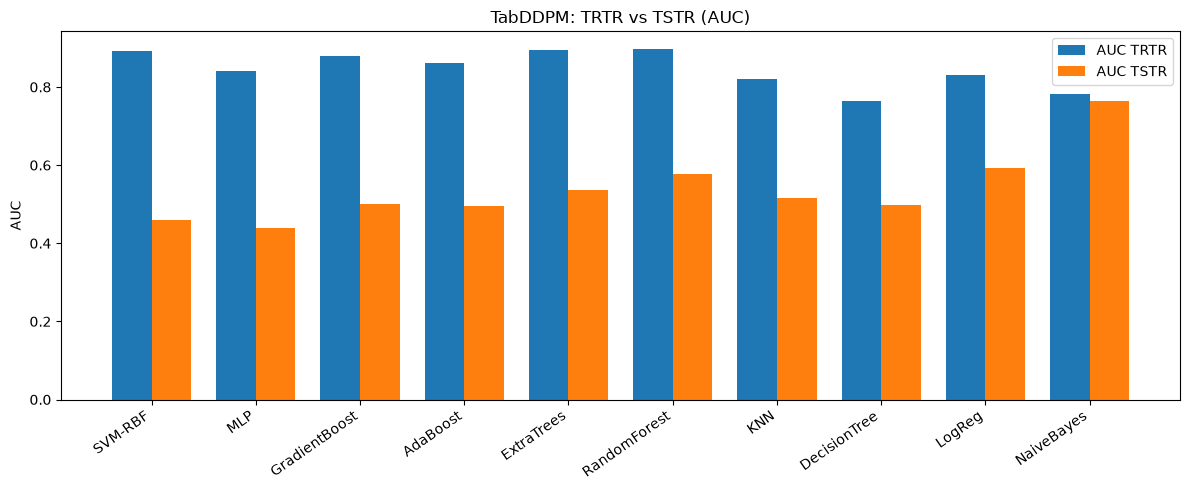

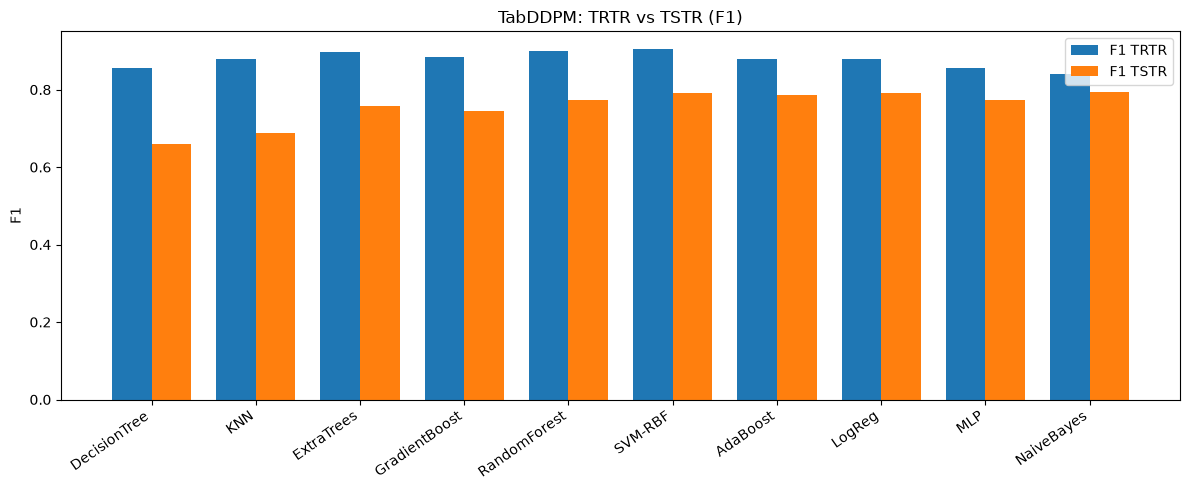

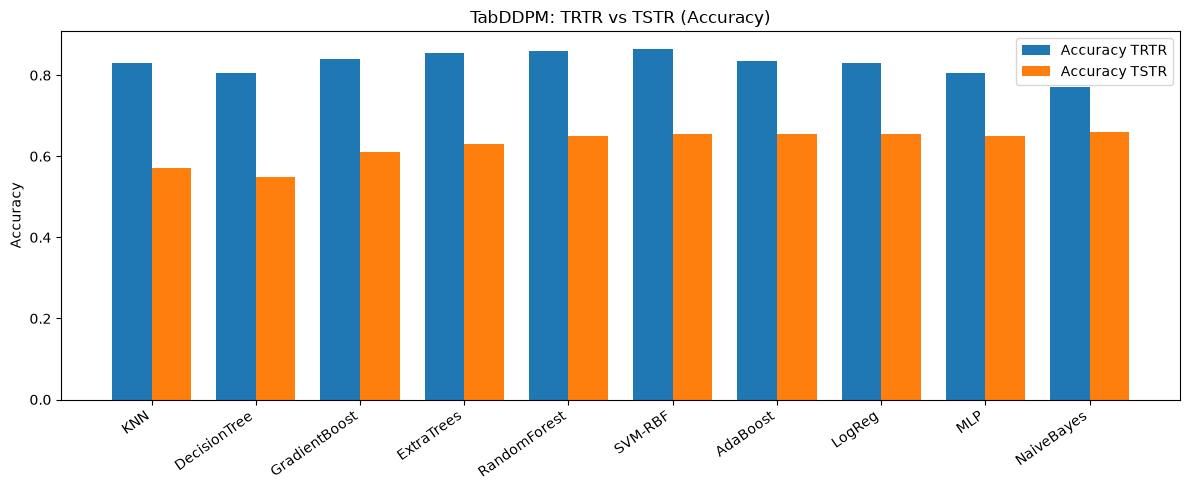

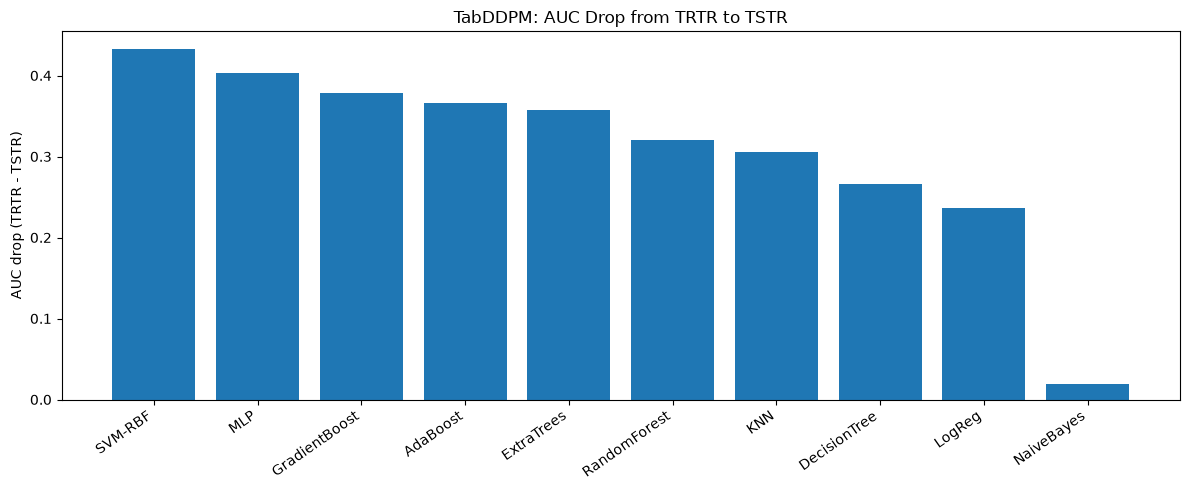

c:\Users\Gopi.Battineni\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(



ForestDiffusion - TSTR


c:\Users\Gopi.Battineni\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(


,Model,Accuracy,F1,AUC
5,RandomForest,0.830,0.875000,0.862872
1,SVM-RBF,0.885,0.918728,0.862374
6,ExtraTrees,0.865,0.904594,0.855017
7,GradientBoost,0.810,0.862319,0.851200
8,AdaBoost,0.795,0.850909,0.837703
0,LogReg,0.830,0.878571,0.834827
9,MLP,0.805,0.852830,0.824317
2,KNN,0.820,0.875862,0.802578
3,NaiveBayes,0.765,0.833922,0.785706
4,DecisionTree,0.755,0.810811,0.734097


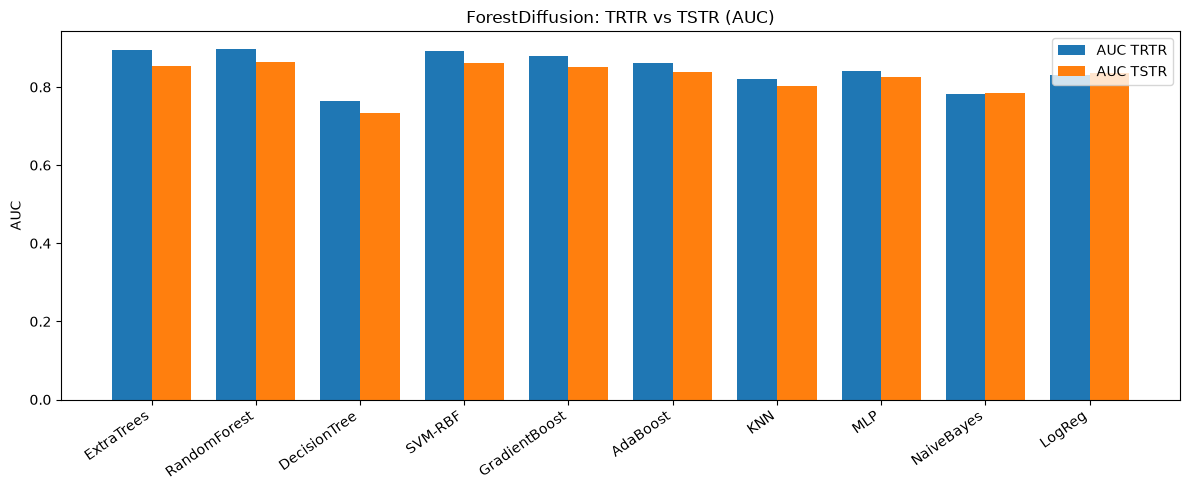

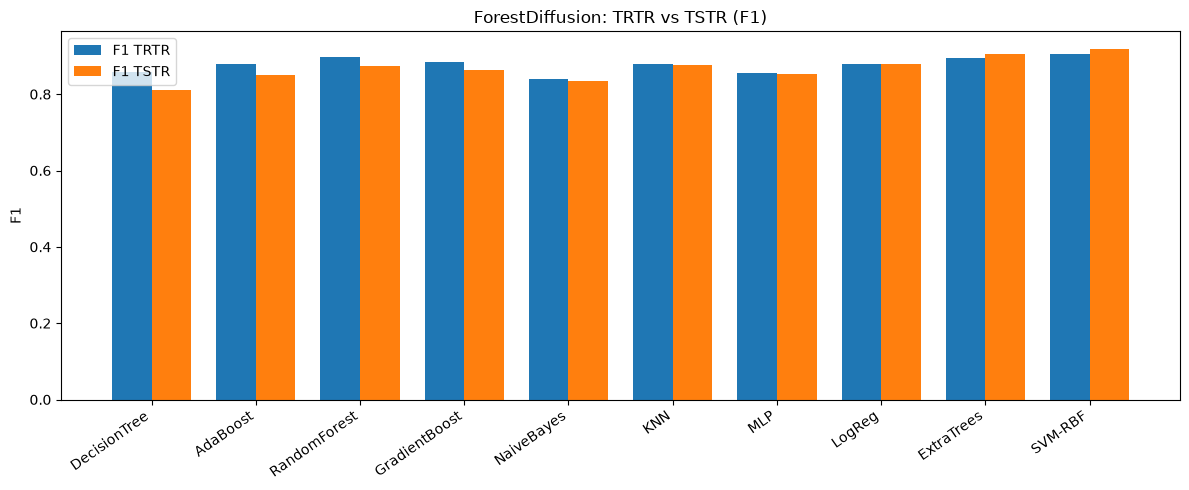

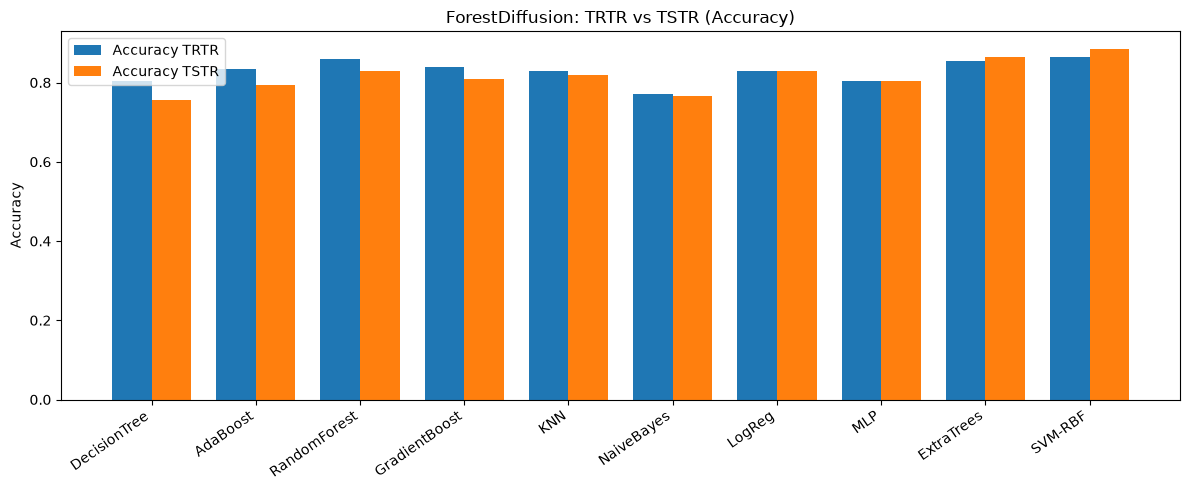

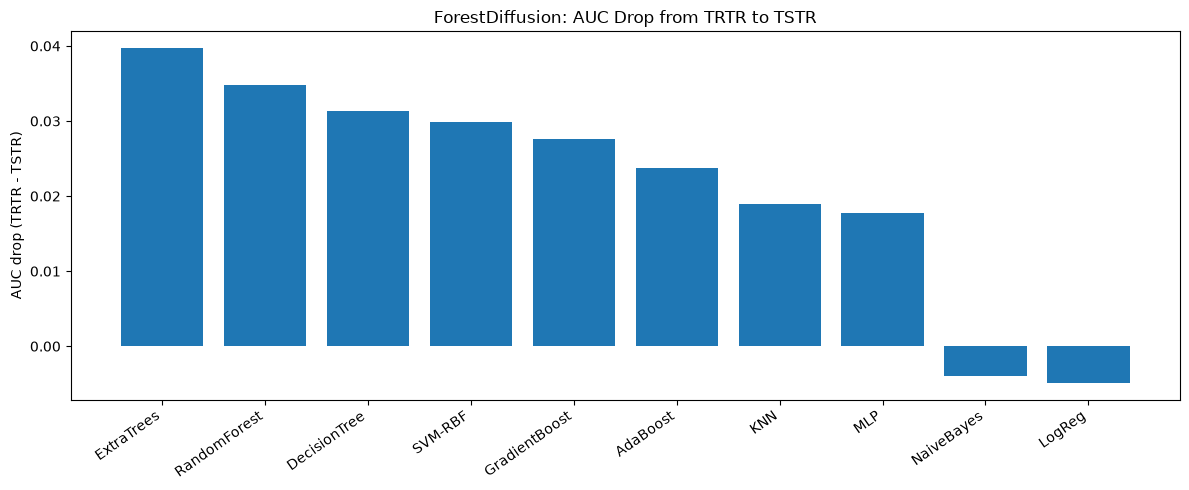


Average AUC drop by synthetic generator:


,Synthetic_Model,AUC_Drop
0,ForestDiffusion,0.021485
1,TabDDPM,0.308674


In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_trtr_vs_tstr(trtr_results, tstr_results, synth_name, metric="AUC"):
    if metric not in trtr_results.columns or metric not in tstr_results.columns:
        return

    df = trtr_results[["Model", metric]].merge(
        tstr_results[["Model", metric]],
        on="Model",
        suffixes=("_TRTR", "_TSTR")
    )
    df["Drop"] = df[f"{metric}_TRTR"] - df[f"{metric}_TSTR"]
    df = df.sort_values("Drop", ascending=False)

    x = np.arange(len(df))
    w = 0.38

    plt.figure(figsize=(12, 5))
    plt.bar(x - w/2, df[f"{metric}_TRTR"], w, label=f"{metric} TRTR")
    plt.bar(x + w/2, df[f"{metric}_TSTR"], w, label=f"{metric} TSTR")
    plt.xticks(x, df["Model"], rotation=35, ha="right")
    plt.ylabel(metric)
    plt.title(f"{synth_name}: TRTR vs TSTR ({metric})")
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_auc_drop(comparison_df, synth_name):
    if "AUC_Drop" not in comparison_df.columns:
        return

    df = comparison_df.sort_values("AUC_Drop", ascending=False)
    x = np.arange(len(df))

    plt.figure(figsize=(12, 5))
    plt.bar(x, df["AUC_Drop"])
    plt.xticks(x, df["Model"], rotation=35, ha="right")
    plt.ylabel("AUC drop (TRTR - TSTR)")
    plt.title(f"{synth_name}: AUC Drop from TRTR to TSTR")
    plt.tight_layout()
    plt.show()

label_col = "class"
model_order = ["TabDDPM", "ForestDiffusion"]

data_eval = data.copy()

synthetic_eval = {}
for name in model_order:
    df = synthetic_outputs[name].copy()
    synthetic_eval[name] = df

trtr_results = evaluate_models(
    train_df=data_eval,
    test_df=data_eval,
    label_col=label_col,
    models=models
)

all_comp = []

for synth_name in model_order:
    tstr_results = evaluate_models(
        train_df=synthetic_eval[synth_name],
        test_df=data_eval,
        label_col=label_col,
        models=models
    )

    comparison = trtr_results.merge(
        tstr_results, on="Model", suffixes=("_TRTR", "_TSTR")
    )
    comparison["AUC_Drop"] = comparison["AUC_TRTR"] - comparison["AUC_TSTR"]
    comparison["Synthetic_Model"] = synth_name
    all_comp.append(comparison)

    print(f"\n{synth_name} - TSTR")
    display(tstr_results)

    for metric in ["AUC", "F1", "Accuracy"]:
        plot_trtr_vs_tstr(trtr_results, tstr_results, synth_name, metric=metric)

    plot_auc_drop(comparison, synth_name)

combined_comparison = pd.concat(all_comp, ignore_index=True)

summary_auc = (
    combined_comparison.groupby("Synthetic_Model", as_index=False)["AUC_Drop"]
    .mean()
    .sort_values("AUC_Drop")
)

print("\nAverage AUC drop by synthetic generator:")
display(summary_auc)


c:\Users\Gopi.Battineni\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Gopi.Battineni\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Gopi.Battineni\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


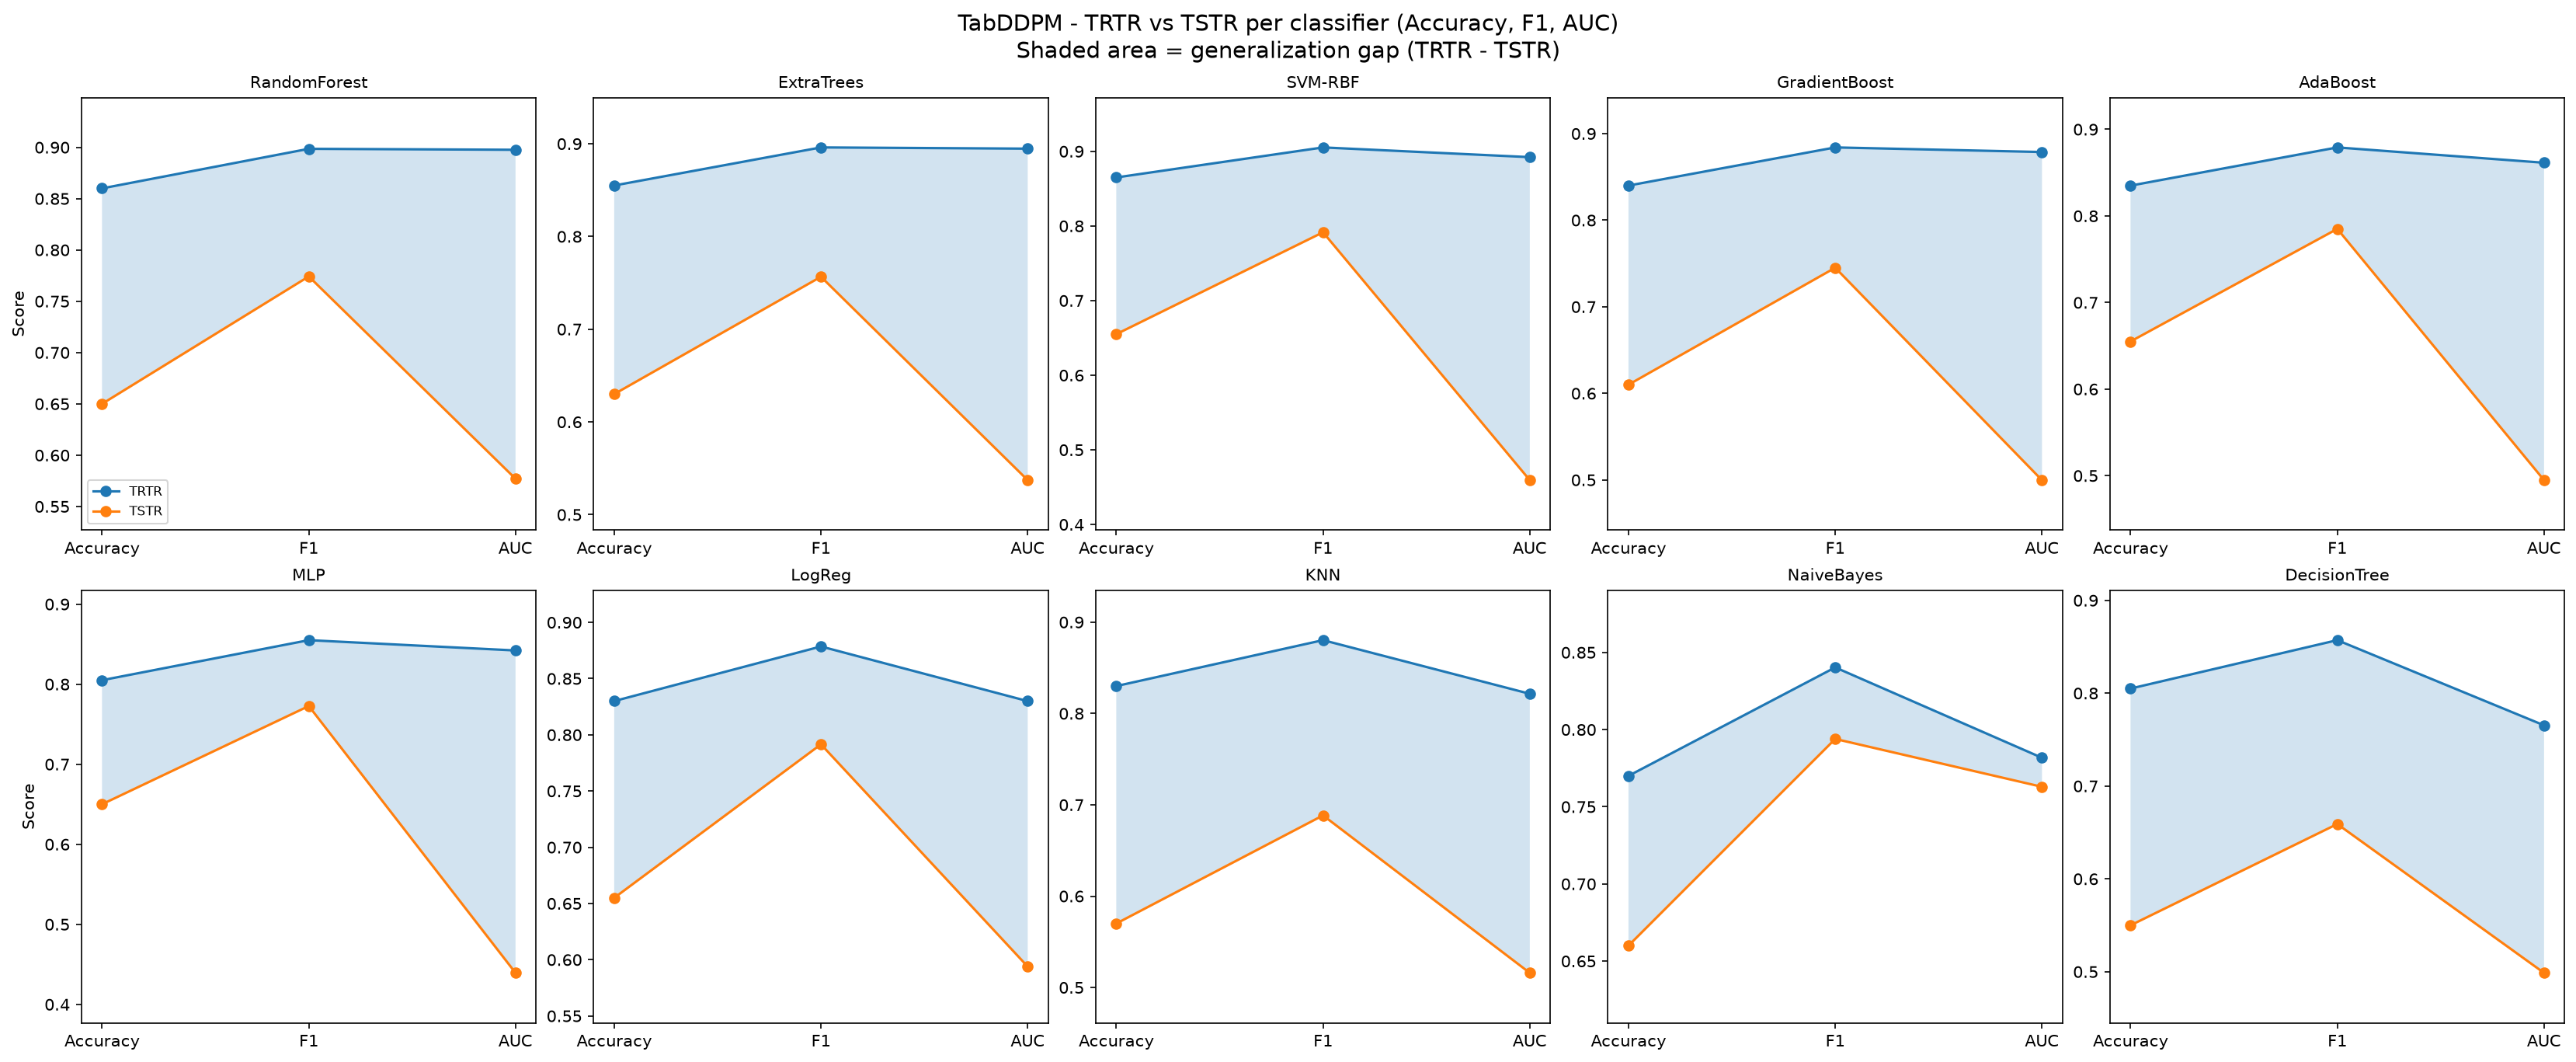

c:\Users\Gopi.Battineni\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Gopi.Battineni\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(


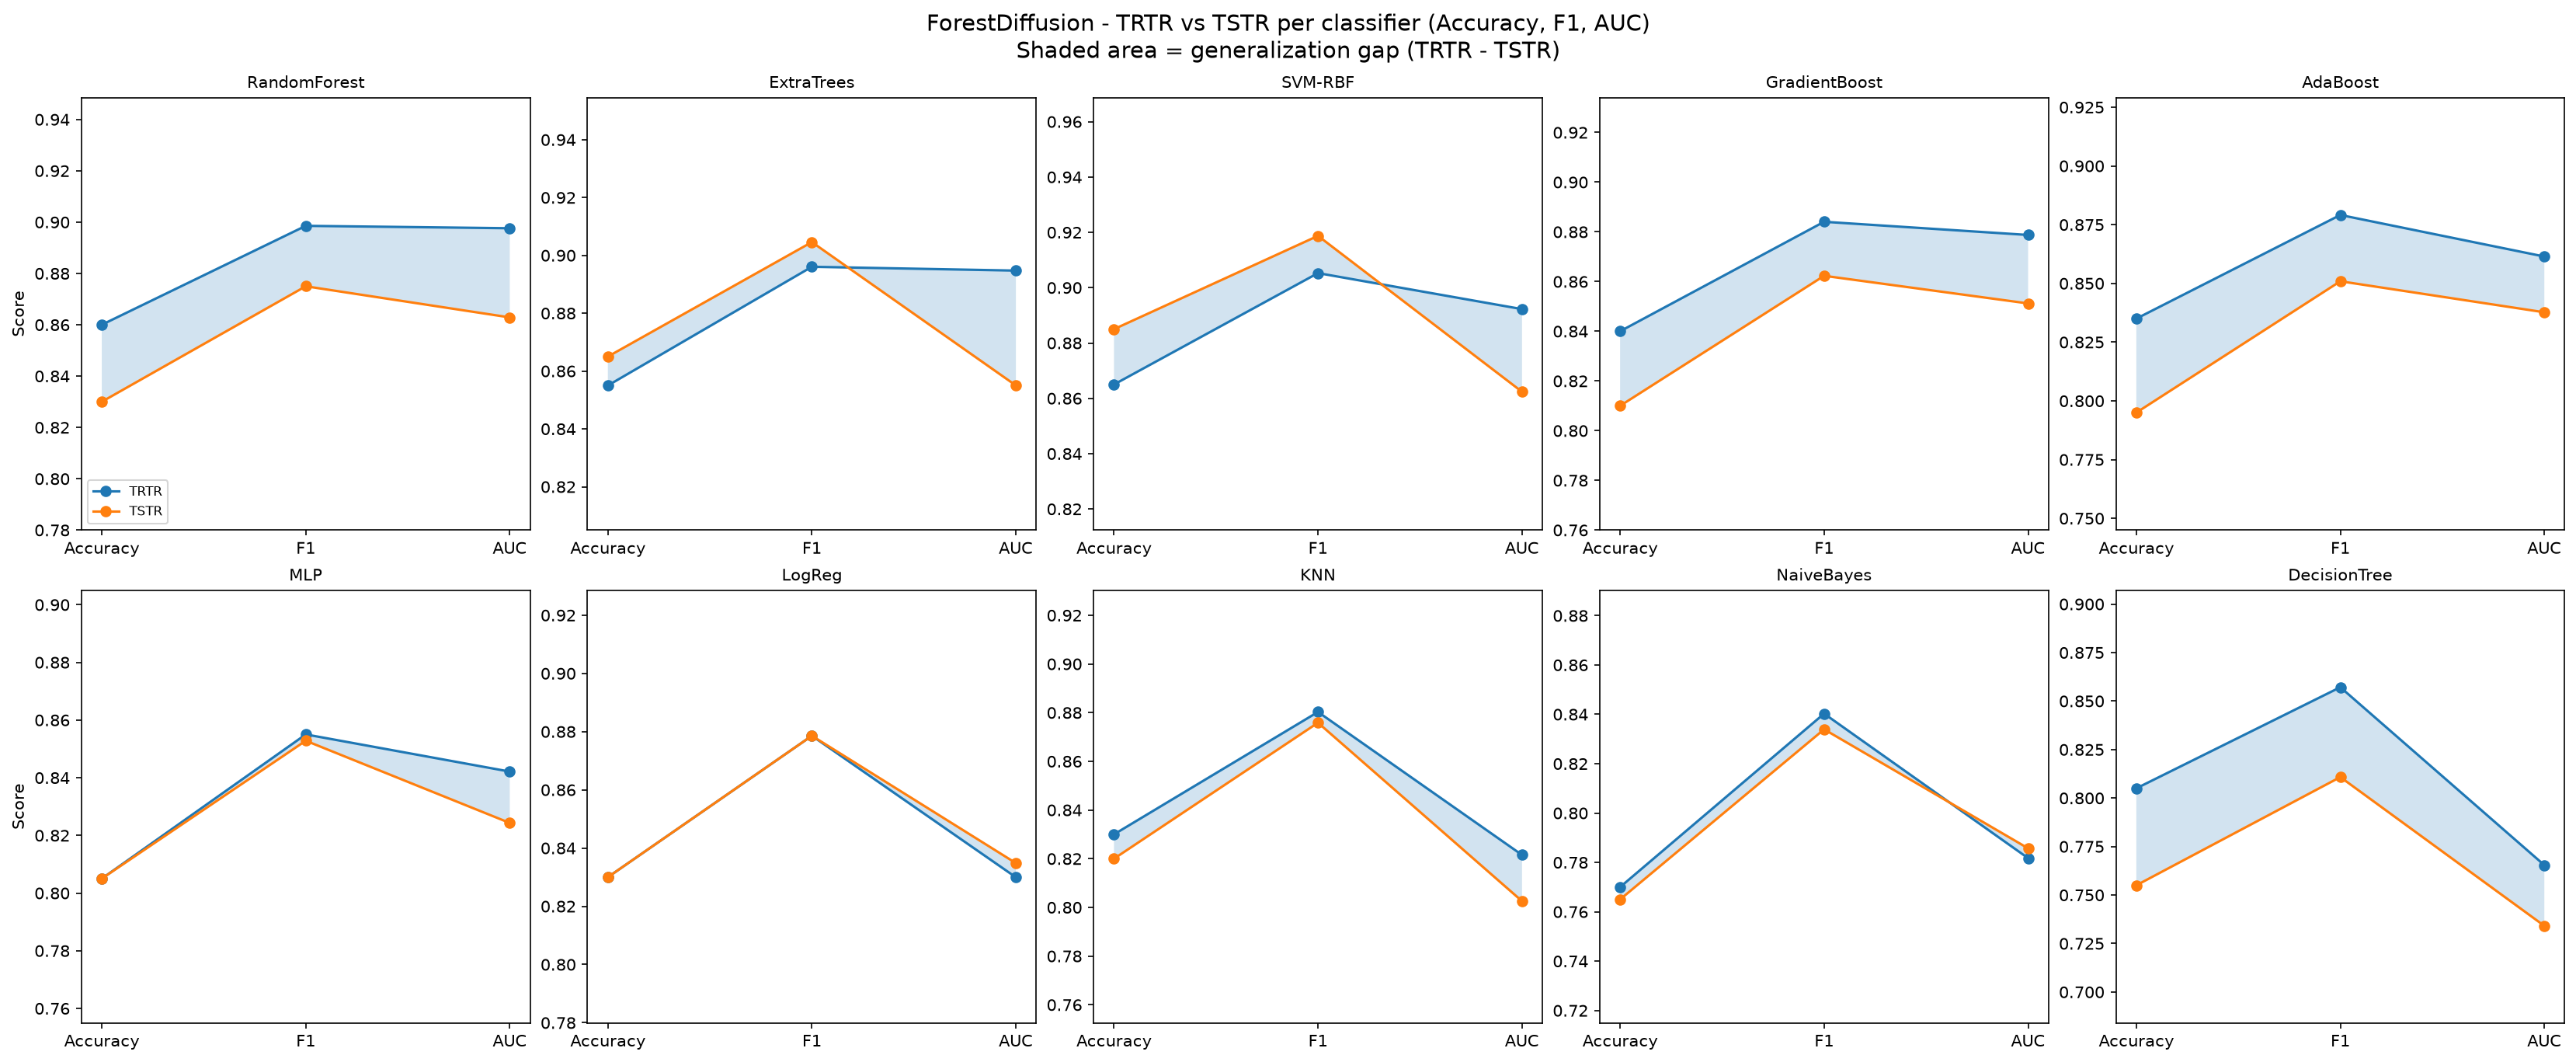

In [25]:
import numpy as np
import matplotlib.pyplot as plt

def plot_grid_line_metrics_with_gap(
    trtr_results,
    tstr_results,
    generator_name,
    ncols=5
):
    metrics = ["Accuracy", "F1", "AUC"]
    x = np.arange(len(metrics))

    trtr = trtr_results.set_index("Model")[metrics]
    tstr = tstr_results.set_index("Model")[metrics]
    models_local = [m for m in trtr.index if m in tstr.index]

    n = len(models_local)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(22, 9),
        dpi=150,
        constrained_layout=True
    )
    axes = np.array(axes).reshape(-1)

    for i, m in enumerate(models_local):
        ax = axes[i]
        a = trtr.loc[m].values.astype(float)
        b = tstr.loc[m].values.astype(float)

        ax.plot(x, a, marker="o", label="TRTR")
        ax.plot(x, b, marker="o", label="TSTR")
        ax.fill_between(x, b, a, alpha=0.2)

        ax.set_title(m, fontsize=10)
        ax.set_xticks(x)
        ax.set_xticklabels(metrics)
        lo = float(np.nanmin(np.concatenate([a, b])))
        hi = float(np.nanmax(np.concatenate([a, b])))
        pad = max((hi - lo) * 0.15, 0.05) if hi > lo else 0.1
        ax.set_ylim(lo - pad, hi + pad)

        if i % ncols == 0:
            ax.set_ylabel("Score")
        if i == 0:
            ax.legend(fontsize=8, loc="lower left")

    for j in range(n, len(axes)):
        axes[j].axis("off")

    fig.suptitle(
        f"{generator_name} - TRTR vs TSTR per classifier (Accuracy, F1, AUC)\n"
        f"Shaded area = generalization gap (TRTR - TSTR)",
        fontsize=14
    )
    plt.show()

label_col = "class"
generators = ["TabDDPM", "ForestDiffusion"]

data_eval = data.copy()

trtr_results = evaluate_models(
    train_df=data_eval,
    test_df=data_eval,
    label_col=label_col,
    models=models
)

for gen in generators:
    synth_eval = synthetic_outputs[gen].copy()

    tstr_results = evaluate_models(
        train_df=synth_eval,
        test_df=data_eval,
        label_col=label_col,
        models=models
    )

    plot_grid_line_metrics_with_gap(
        trtr_results,
        tstr_results,
        generator_name=gen,
        ncols=5
    )


# 5 Statistical similarity tests


Average error by model


,Model,Mean Error %,Median Error %,Std Error %
0,TabDDPM,283.921016,61.866496,111.849351
1,ForestDiffusion,15.627090,3.100582,10.835374


C:\Users\Gopi.Battineni\AppData\Local\Temp\ipykernel_27640\449980662.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_df, x="Model", y="Mean Error %", ax=axes[0], palette="viridis")
C:\Users\Gopi.Battineni\AppData\Local\Temp\ipykernel_27640\449980662.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_df, x="Model", y="Median Error %", ax=axes[1], palette="viridis")
C:\Users\Gopi.Battineni\AppData\Local\Temp\ipykernel_27640\449980662.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_df, x="Model

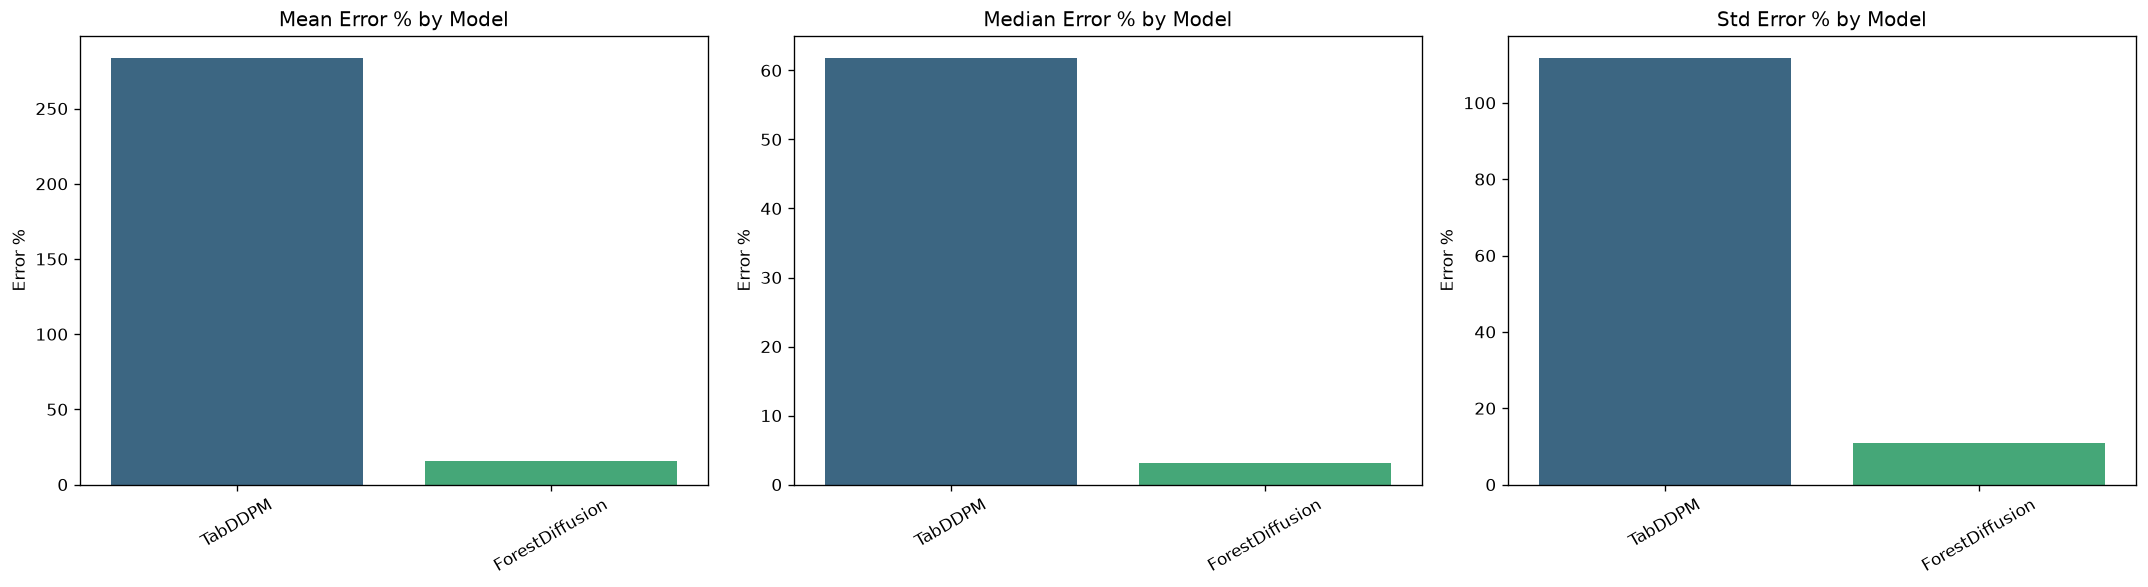

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["TabDDPM", "ForestDiffusion"]

target_col = "class"

real_df = data.copy()
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in num_cols:
    num_cols.remove(target_col)

summary_rows = []
feature_error_by_model = {}

for model_name in model_order:
    synth_df = synthetic_outputs[model_name].copy()
    _common = [c for c in real_df.columns if c in synth_df.columns]

    synth_df = synth_df[_common]

    real_means = real_df[num_cols].mean()
    synth_means = synth_df[num_cols].mean()

    real_stds = real_df[num_cols].std(ddof=1)
    synth_stds = synth_df[num_cols].std(ddof=1)

    mean_error_pct = (np.abs(synth_means - real_means) / real_means.replace(0, np.nan).abs()) * 100
    std_error_pct = (np.abs(synth_stds - real_stds) / real_stds.replace(0, np.nan).abs()) * 100

    feature_error_df = pd.DataFrame({
        "Feature": num_cols,
        "Mean_Error_%": mean_error_pct.values,
        "Std_Error_%": std_error_pct.values
    })

    feature_error_df = feature_error_df.replace([np.inf, -np.inf], np.nan)

    model_summary = {
        "Model": model_name,
        "Mean Error %": feature_error_df["Mean_Error_%"].mean(skipna=True),
        "Median Error %": feature_error_df["Mean_Error_%"].median(skipna=True),
        "Std Error %": feature_error_df["Std_Error_%"].mean(skipna=True)
    }

    summary_rows.append(model_summary)
    feature_error_by_model[model_name] = feature_error_df

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.set_index("Model").loc[model_order].reset_index()

print("Average error by model")
display(summary_df)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=120)

sns.barplot(data=summary_df, x="Model", y="Mean Error %", ax=axes[0], palette="viridis")
axes[0].set_title("Mean Error % by Model")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(data=summary_df, x="Model", y="Median Error %", ax=axes[1], palette="viridis")
axes[1].set_title("Median Error % by Model")
axes[1].tick_params(axis="x", rotation=30)

sns.barplot(data=summary_df, x="Model", y="Std Error %", ax=axes[2], palette="viridis")
axes[2].set_title("Std Error % by Model")
axes[2].tick_params(axis="x", rotation=30)

for ax in axes:
    ax.set_xlabel("")
    ax.set_ylabel("Error %")

plt.tight_layout()
plt.show()


C:\Users\Gopi.Battineni\AppData\Local\Temp\ipykernel_27640\521707326.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x="Model", y="Mean Error %", palette="viridis")


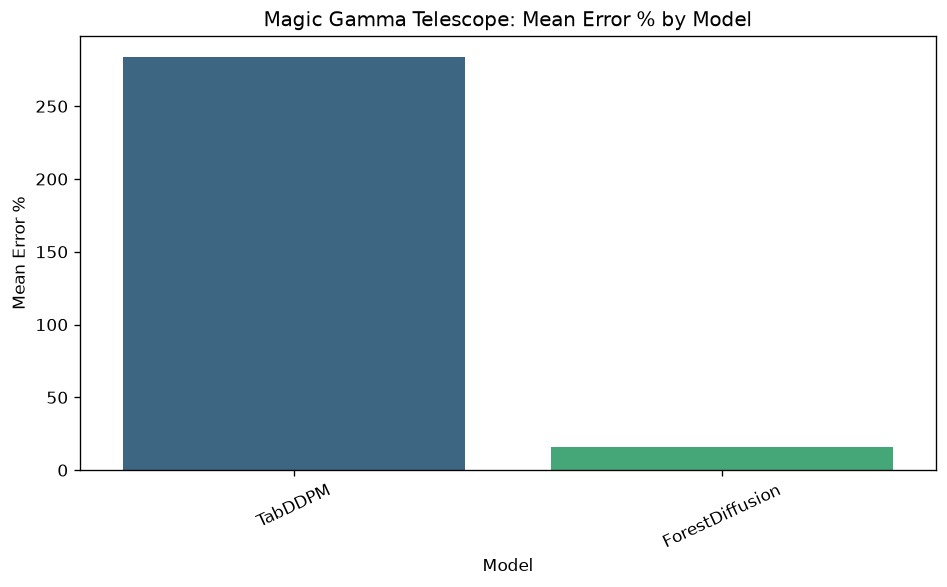

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = summary_df[["Model", "Mean Error %"]].copy()

plt.figure(figsize=(8, 5), dpi=120)
sns.barplot(data=plot_df, x="Model", y="Mean Error %", palette="viridis")
plt.title("Magic Gamma Telescope: Mean Error % by Model")
plt.xlabel("Model")
plt.ylabel("Mean Error %")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()


Average error by model


,Model,Mean Error %,Median Error %,Std Error %
0,TabDDPM,283.921016,61.866496,111.849351
1,ForestDiffusion,15.627090,3.100582,10.835374


C:\Users\Gopi.Battineni\AppData\Local\Temp\ipykernel_27640\449980662.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_df, x="Model", y="Mean Error %", ax=axes[0], palette="viridis")
C:\Users\Gopi.Battineni\AppData\Local\Temp\ipykernel_27640\449980662.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_df, x="Model", y="Median Error %", ax=axes[1], palette="viridis")
C:\Users\Gopi.Battineni\AppData\Local\Temp\ipykernel_27640\449980662.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_df, x="Model

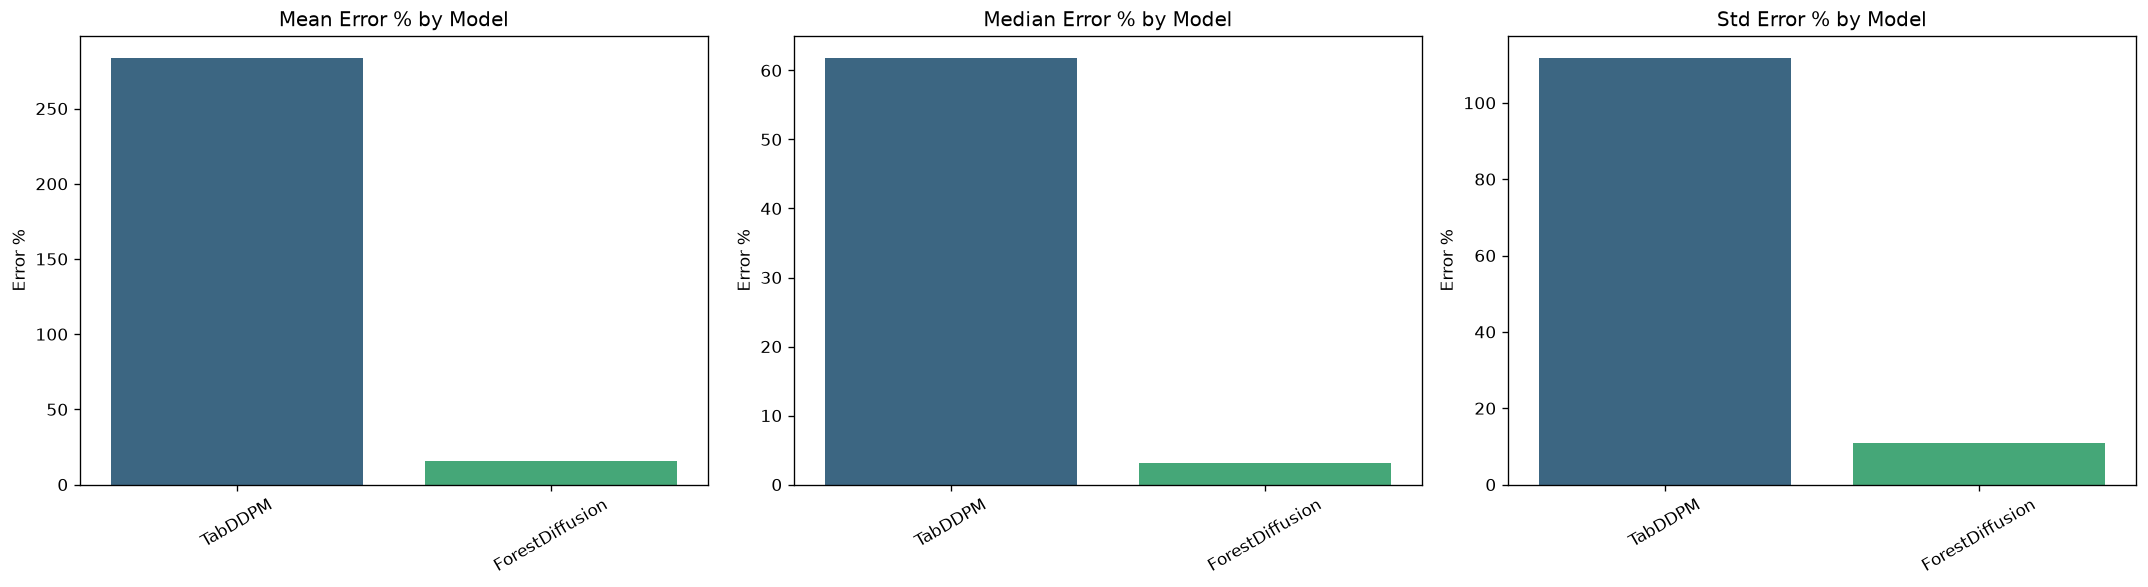

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["TabDDPM", "ForestDiffusion"]

target_col = "class"

real_df = data.copy()
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in num_cols:
    num_cols.remove(target_col)

summary_rows = []
feature_error_by_model = {}

for model_name in model_order:
    synth_df = synthetic_outputs[model_name].copy()
    _common = [c for c in real_df.columns if c in synth_df.columns]

    synth_df = synth_df[_common]

    real_means = real_df[num_cols].mean()
    synth_means = synth_df[num_cols].mean()

    real_stds = real_df[num_cols].std(ddof=1)
    synth_stds = synth_df[num_cols].std(ddof=1)

    mean_error_pct = (np.abs(synth_means - real_means) / real_means.replace(0, np.nan).abs()) * 100
    std_error_pct = (np.abs(synth_stds - real_stds) / real_stds.replace(0, np.nan).abs()) * 100

    feature_error_df = pd.DataFrame({
        "Feature": num_cols,
        "Mean_Error_%": mean_error_pct.values,
        "Std_Error_%": std_error_pct.values
    })

    feature_error_df = feature_error_df.replace([np.inf, -np.inf], np.nan)

    model_summary = {
        "Model": model_name,
        "Mean Error %": feature_error_df["Mean_Error_%"].mean(skipna=True),
        "Median Error %": feature_error_df["Mean_Error_%"].median(skipna=True),
        "Std Error %": feature_error_df["Std_Error_%"].mean(skipna=True)
    }

    summary_rows.append(model_summary)
    feature_error_by_model[model_name] = feature_error_df

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.set_index("Model").loc[model_order].reset_index()

print("Average error by model")
display(summary_df)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=120)

sns.barplot(data=summary_df, x="Model", y="Mean Error %", ax=axes[0], palette="viridis")
axes[0].set_title("Mean Error % by Model")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(data=summary_df, x="Model", y="Median Error %", ax=axes[1], palette="viridis")
axes[1].set_title("Median Error % by Model")
axes[1].tick_params(axis="x", rotation=30)

sns.barplot(data=summary_df, x="Model", y="Std Error %", ax=axes[2], palette="viridis")
axes[2].set_title("Std Error % by Model")
axes[2].tick_params(axis="x", rotation=30)

for ax in axes:
    ax.set_xlabel("")
    ax.set_ylabel("Error %")

plt.tight_layout()
plt.show()


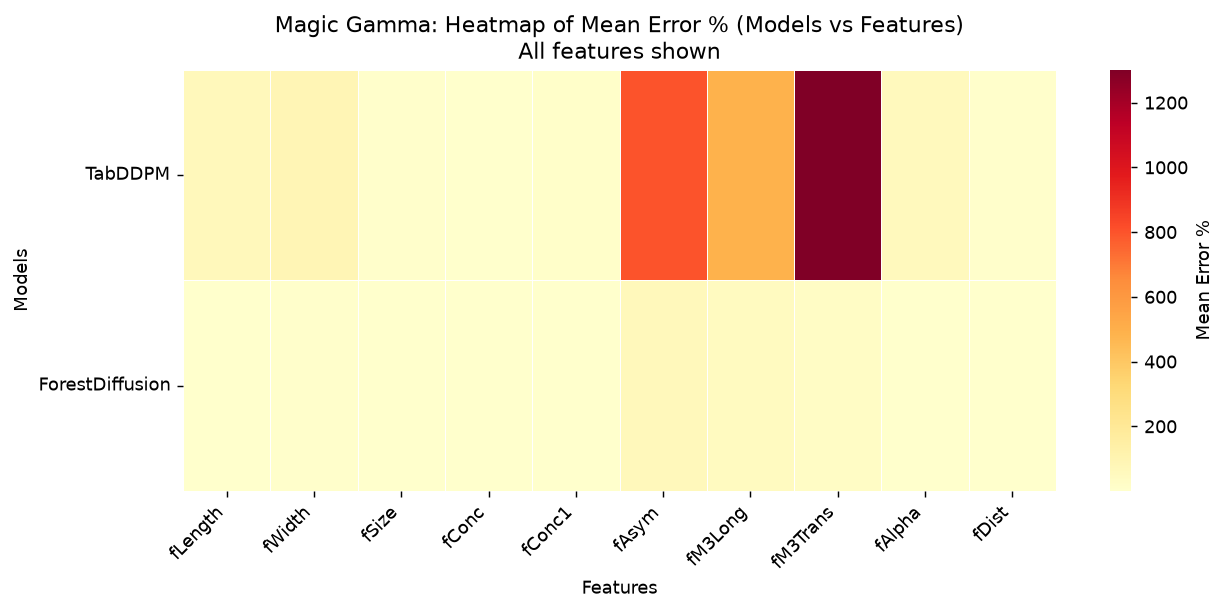

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["TabDDPM", "ForestDiffusion"]

heatmap_df = pd.DataFrame({
    m: feature_error_by_model[m].set_index("Feature")["Mean_Error_%"]
    for m in model_order
    if m in feature_error_by_model
}).T

heatmap_df = heatmap_df.replace([np.inf, -np.inf], np.nan)

max_features = 20
if heatmap_df.shape[1] > max_features:
    top_features = heatmap_df.mean(axis=0, skipna=True).sort_values(ascending=False).head(max_features).index
    heatmap_plot_df = heatmap_df[top_features]
    truncated_note = f"Top {max_features} features shown (of {heatmap_df.shape[1]} total)"
else:
    heatmap_plot_df = heatmap_df.copy()
    truncated_note = "All features shown"

def truncate_label(s, max_len=18):
    s = str(s)
    return s if len(s) <= max_len else s[:max_len - 1] + "..."

display_labels = [truncate_label(c, max_len=18) for c in heatmap_plot_df.columns]

plt.figure(figsize=(max(10, 0.55 * len(display_labels)), 4.8), dpi=130)
sns.heatmap(
    heatmap_plot_df,
    cmap="YlOrRd",
    annot=False,
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "Mean Error %"}
)

plt.title(f"Magic Gamma: Heatmap of Mean Error % (Models vs Features)\n{truncated_note}")
plt.xlabel("Features")
plt.ylabel("Models")
plt.xticks(np.arange(len(display_labels)) + 0.5, display_labels, rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


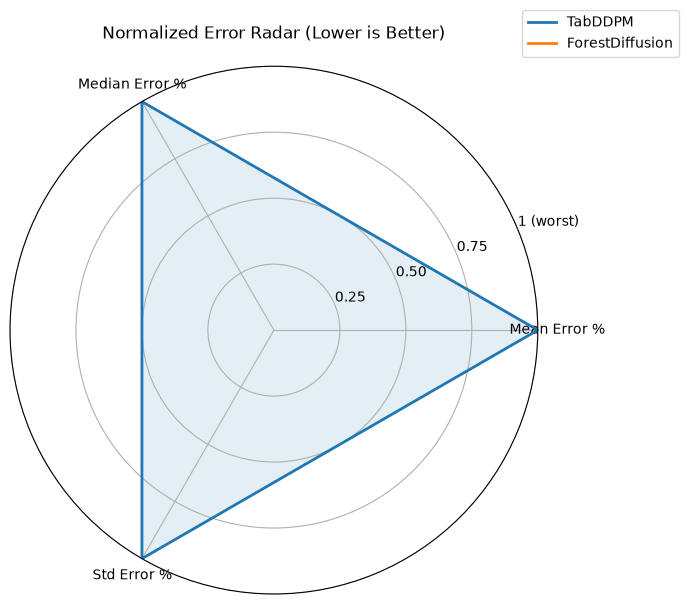

,Model,Mean Error %,Median Error %,Std Error %
0,TabDDPM,1.0,1.0,1.0
1,ForestDiffusion,0.0,0.0,0.0


In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Requires summary_df with columns:
# ["Model", "Mean Error %", "Median Error %", "Std Error %"]

metrics = ["Mean Error %", "Median Error %", "Std Error %"]
radar_df = summary_df[["Model"] + metrics].copy()

# Min-max normalize each metric across models (0 = best / lowest error, 1 = worst / highest error)
norm_df = radar_df.copy()
for m in metrics:
    mn, mx = norm_df[m].min(), norm_df[m].max()
    if mx > mn:
        norm_df[m] = (norm_df[m] - mn) / (mx - mn)
    else:
        norm_df[m] = 0.0

labels = metrics
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]  # close the loop

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for _, row in norm_df.iterrows():
    values = row[metrics].tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=row["Model"])
    ax.fill(angles, values, alpha=0.12)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
ax.set_ylim(0, 1)
ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["0 (best)", "0.25", "0.50", "0.75", "1 (worst)"])
ax.set_title("Normalized Error Radar (Lower is Better)", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.28, 1.12))
plt.tight_layout()
plt.show()

display(norm_df)


Average absolute difference in outlier counts (Real vs Synthetic) by model:


,Model,Avg_Abs_Diff_Outlier_Count,Median_Abs_Diff_Outlier_Count,Max_Abs_Diff_Outlier_Count
0,ForestDiffusion,8.6,7.0,27
1,TabDDPM,69.4,42.0,250


C:\Users\Gopi.Battineni\AppData\Local\Temp\ipykernel_27640\3255319757.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=outlier_summary_df, x="Model", y="Avg_Abs_Diff_Outlier_Count", palette="viridis")


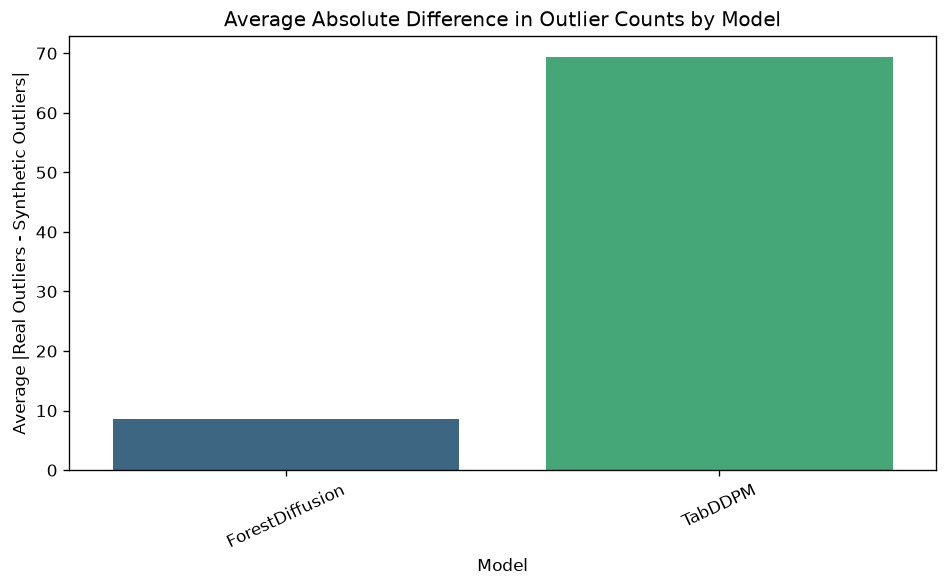

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["TabDDPM", "ForestDiffusion"]

target_col = "class"

real_df = data.copy()
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in num_cols:
    num_cols.remove(target_col)

def outlier_count_iqr(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lo = q1 - 1.5 * iqr
    hi = q3 + 1.5 * iqr
    return ((series < lo) | (series > hi)).sum()

rows = []
feature_diff_by_model = {}

real_outliers = {c: outlier_count_iqr(real_df[c]) for c in num_cols}

for model in model_order:
    synth_df = synthetic_outputs[model].copy()

    # keep only shared columns and numeric features
    common_cols = real_df.columns.intersection(synth_df.columns)
    synth_df = synth_df[common_cols]
    synth_num_cols = [c for c in num_cols if c in synth_df.columns]

    synth_outliers = {c: outlier_count_iqr(synth_df[c]) for c in synth_num_cols}

    feat_df = pd.DataFrame({
        "Feature": synth_num_cols,
        "Real_Outliers": [real_outliers[c] for c in synth_num_cols],
        "Synthetic_Outliers": [synth_outliers[c] for c in synth_num_cols]
    })
    feat_df["Abs_Diff_Outlier_Count"] = (feat_df["Real_Outliers"] - feat_df["Synthetic_Outliers"]).abs()

    feature_diff_by_model[model] = feat_df
    rows.append({
        "Model": model,
        "Avg_Abs_Diff_Outlier_Count": feat_df["Abs_Diff_Outlier_Count"].mean(),
        "Median_Abs_Diff_Outlier_Count": feat_df["Abs_Diff_Outlier_Count"].median(),
        "Max_Abs_Diff_Outlier_Count": feat_df["Abs_Diff_Outlier_Count"].max()
    })

outlier_summary_df = pd.DataFrame(rows).sort_values("Avg_Abs_Diff_Outlier_Count").reset_index(drop=True)

print("Average absolute difference in outlier counts (Real vs Synthetic) by model:")
display(outlier_summary_df)

plt.figure(figsize=(8, 5), dpi=120)
sns.barplot(data=outlier_summary_df, x="Model", y="Avg_Abs_Diff_Outlier_Count", palette="viridis")
plt.title("Average Absolute Difference in Outlier Counts by Model")
plt.xlabel("Model")
plt.ylabel("Average |Real Outliers - Synthetic Outliers|")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()


# 6. Cosine Similarity with Hungraian Mapping


In [32]:
from numpy.linalg import norm
import numpy as np
import pandas as pd

def normalize_rows(X):
    X = np.asarray(X, dtype=float)
    return X / (norm(X, axis=1, keepdims=True) + 1e-12)

def cosine_similarity_matrix(real_df, synth_df, num_cols=None, target_col=None):
    if num_cols is None:
        num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
    if target_col is None:
        target_col = "class" if "Group" in real_df.columns else "Group"
    if target_col in num_cols:
        num_cols.remove(target_col)

    R = real_df[num_cols].to_numpy(dtype=float)
    S = synth_df[num_cols].to_numpy(dtype=float)
    return normalize_rows(R) @ normalize_rows(S).T

# Map your synthetic outputs here
synthetic_data = synthetic_outputs

cosine_results = {}
cosine_dfs = {}

model_order = ["TabDDPM", "ForestDiffusion"]
target_col = "class"
num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
if target_col in num_cols:
    num_cols.remove(target_col)

real_matrix = normalize_rows(data[num_cols].to_numpy(dtype=float))

for model_name in model_order:
    if model_name not in synthetic_data:
        raise KeyError(f"{model_name} not found in synthetic_data. Available keys: {list(synthetic_data.keys())}")

    synth_df = synthetic_data[model_name].copy()

    missing_cols = [c for c in data.columns if c not in synth_df.columns]
    if missing_cols:
        raise ValueError(f"{model_name} is missing columns: {missing_cols}")

    synth_df = synth_df[data.columns].copy()
    print(f"Building cosine similarity DataFrame for {model_name}...")

    synth_matrix = normalize_rows(synth_df[num_cols].to_numpy(dtype=float))
    cosine_matrix = real_matrix @ synth_matrix.T

    block_n = 10
    n = min(block_n, cosine_matrix.shape[0], cosine_matrix.shape[1])

    cosine_df = pd.DataFrame(
        cosine_matrix[:n, :n],
        index=[f"R{i+1}" for i in range(n)],
        columns=[f"S{j+1}" for j in range(n)]
    )

    cosine_dfs[model_name] = cosine_df
    cosine_results[model_name] = {
        "avg_cosine": float(cosine_matrix.mean()),
        "max_cosine": float(cosine_matrix.max())
    }

    print(cosine_df, "\n")

display(pd.DataFrame(cosine_results).T)


Building cosine similarity DataFrame for TabDDPM...
           S1        S2        S3        S4        S5        S6        S7  \
R1   0.900735  0.969932  0.951136  0.941539  0.718953  0.969587  0.901763   
R2   0.808400  0.937208  0.984601  0.986365  0.807274  0.989662  0.863913   
R3   0.898210  0.986431  0.964743  0.961592  0.744369  0.992026  0.826195   
R4   0.799347  0.921771  0.995076  0.994287  0.856170  0.985420  0.815894   
R5   0.647373  0.563895  0.701336  0.642418  0.787693  0.593684  0.411550   
R6   0.887077  0.909035  0.956082  0.930593  0.864832  0.939413  0.675597   
R7   0.902892  0.963085  0.913475  0.913336  0.641886  0.932104  0.893922   
R8   0.702796  0.590978  0.720344  0.667051  0.736422  0.622428  0.635126   
R9   0.833335  0.888281  0.980166  0.958940  0.869849  0.948889  0.860256   
R10  0.909132  0.993866  0.933322  0.931077  0.679079  0.978782  0.822876   

           S8        S9       S10  
R1   0.919096  0.763776  0.922458  
R2   0.929374  0.812089  0.8

,avg_cosine,max_cosine
TabDDPM,0.755010,0.999838
ForestDiffusion,0.869211,0.999998


In [33]:
import numpy as np
import pandas as pd
from numpy.linalg import norm

def normalize_rows(X):
    X = np.asarray(X, dtype=float)
    return X / (norm(X, axis=1, keepdims=True) + 1e-12)

def associate_real_with_synthetic(real_data: pd.DataFrame, synthetic_data: pd.DataFrame):
    num_cols = real_data.select_dtypes(include=["number"]).columns.tolist()
    target_col = "class" if "Group" in real_data.columns else "Group"
    if target_col in num_cols:
        num_cols.remove(target_col)

    R = real_data[num_cols].to_numpy(dtype=float)
    S = synthetic_data[num_cols].to_numpy(dtype=float)

    R_norm = normalize_rows(R)
    S_norm = normalize_rows(S)

    cos_sim = R_norm @ S_norm.T
    best_s_idx = np.argmax(cos_sim, axis=1)
    best_sim = cos_sim[np.arange(len(R)), best_s_idx]

    return best_s_idx, best_sim, cos_sim

data = data.copy()
results = {}

for name, synth_df in synthetic_data.items():
    synth_df = synth_df[data.columns]
    best_indices, best_sims, cos_matrix = associate_real_with_synthetic(data, synth_df)

    results[name] = {
        "best_indices": best_indices,
        "best_sims": best_sims,
        "cos_matrix": cos_matrix,
    }

    top_idx = np.argsort(best_sims)[::-1][:10]

    print(f"\n{name} - Top 10 Real -> Synthetic Matchings")
    for rank, i in enumerate(top_idx, 1):
        print(f"{rank:02d}. R{i+1} -> S{best_indices[i]+1}   cosine similarity = {best_sims[i]:.4f}")



TabDDPM - Top 10 Real -> Synthetic Matchings
01. R650 -> S255   cosine similarity = 0.9998
02. R177 -> S846   cosine similarity = 0.9998
03. R910 -> S824   cosine similarity = 0.9997
04. R106 -> S239   cosine similarity = 0.9997
05. R753 -> S139   cosine similarity = 0.9997
06. R668 -> S402   cosine similarity = 0.9997
07. R444 -> S23   cosine similarity = 0.9997
08. R466 -> S974   cosine similarity = 0.9996
09. R767 -> S660   cosine similarity = 0.9996
10. R679 -> S964   cosine similarity = 0.9996

ForestDiffusion - Top 10 Real -> Synthetic Matchings
01. R480 -> S865   cosine similarity = 1.0000
02. R758 -> S156   cosine similarity = 1.0000
03. R67 -> S138   cosine similarity = 0.9999
04. R150 -> S561   cosine similarity = 0.9999
05. R624 -> S78   cosine similarity = 0.9999
06. R625 -> S260   cosine similarity = 0.9999
07. R316 -> S934   cosine similarity = 0.9999
08. R64 -> S794   cosine similarity = 0.9999
09. R618 -> S855   cosine similarity = 0.9999
10. R195 -> S802   cosine simi

In [34]:
import numpy as np
import pandas as pd
from numpy.linalg import norm
from scipy.optimize import linear_sum_assignment

def normalize_rows(X: np.ndarray) -> np.ndarray:
    norms = norm(X, axis=1, keepdims=True) + 1e-12
    return X / norms

def cosine_similarity_matrix(real_df: pd.DataFrame, synth_df: pd.DataFrame, num_cols=None) -> np.ndarray:
    if num_cols is None:
        num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()

    target_col = "class" if "Group" in real_df.columns else "Group"
    if target_col in num_cols:
        num_cols.remove(target_col)

    R = real_df[num_cols].to_numpy(dtype=float)
    S = synth_df[num_cols].to_numpy(dtype=float)
    return normalize_rows(R) @ normalize_rows(S).T

def hungarian_match(real_df: pd.DataFrame, synth_df: pd.DataFrame, num_cols=None):
    cos_sim = cosine_similarity_matrix(real_df, synth_df, num_cols)
    n_real, n_synth = cos_sim.shape

    if n_real <= n_synth:
        row_ind, col_ind = linear_sum_assignment(1.0 - cos_sim)
    else:
        col_ind, row_ind = linear_sum_assignment(1.0 - cos_sim.T)

    sims = cos_sim[row_ind, col_ind]
    avg_sim = float(sims.mean())
    return row_ind, col_ind, sims, avg_sim, cos_sim

real_df = data.copy()

# Use your actual synthetic DataFrames here
# Use TabDDPM and ForestDiffusion synthetic outputs
synthetic_data = {
    "TabDDPM": synthetic_outputs["TabDDPM"],
    "ForestDiffusion": synthetic_outputs["ForestDiffusion"],
}

results = {}

for name, synth_df in synthetic_data.items():
    print(f"\n==============================")
    print(f"{name}: Hungarian matching (cosine, numeric features)")
    print(f"==============================")

    _common = [c for c in real_df.columns if c in synth_df.columns]

    synth_df = synth_df[_common].copy()

    row_ind, col_ind, sims, avg_sim, cos_matrix = hungarian_match(real_df, synth_df)

    results[name] = {
        "row_ind": row_ind,
        "col_ind": col_ind,
        "similarities": sims,
        "avg_similarity": avg_sim,
        "cos_matrix": cos_matrix,
    }

    print(f"Average cosine similarity (Hungarian match): {avg_sim:.4f}\n")

    order = np.argsort(sims)[::-1]
    top_k = min(10, len(order))
    for r in range(top_k):
        k = order[r]
        print(f"R{row_ind[k]+1} <-> S{col_ind[k]+1}   cosine similarity = {sims[k]:.4f}")

summary_df = pd.DataFrame(
    [{"Model": name, "Avg_Hungarian_Cosine": info["avg_similarity"]} for name, info in results.items()]
).sort_values("Avg_Hungarian_Cosine", ascending=False)

display(summary_df)



TabDDPM: Hungarian matching (cosine, numeric features)
Average cosine similarity (Hungarian match): 0.9238

R910 <-> S824   cosine similarity = 0.9997
R668 <-> S402   cosine similarity = 0.9997
R203 <-> S4   cosine similarity = 0.9994
R308 <-> S390   cosine similarity = 0.9994
R126 <-> S168   cosine similarity = 0.9994
R767 <-> S256   cosine similarity = 0.9994
R142 <-> S448   cosine similarity = 0.9993
R54 <-> S91   cosine similarity = 0.9992
R933 <-> S223   cosine similarity = 0.9992
R42 <-> S935   cosine similarity = 0.9991

ForestDiffusion: Hungarian matching (cosine, numeric features)
Average cosine similarity (Hungarian match): 0.9926

R480 <-> S865   cosine similarity = 1.0000
R758 <-> S156   cosine similarity = 1.0000
R150 <-> S561   cosine similarity = 0.9999
R624 <-> S78   cosine similarity = 0.9999
R316 <-> S934   cosine similarity = 0.9999
R618 <-> S855   cosine similarity = 0.9999
R195 <-> S802   cosine similarity = 0.9999
R745 <-> S484   cosine similarity = 0.9998
R781 <

,Model,Avg_Hungarian_Cosine
1,ForestDiffusion,0.992639
0,TabDDPM,0.923839


In [35]:
pip install xlsxwriter

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [36]:
import pandas as pd
import numpy as np

real_df = data.copy()
feature_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()

target_col = "class" if "Group" in real_df.columns else "Group"
if target_col in feature_cols:
    feature_cols.remove(target_col)

# Smart synthetic source detection
if "synthetic_outputs" in globals():
    synth_source = synthetic_outputs
elif "synthetic_data" in globals():
    synth_source = synthetic_data
elif "synthetic_tables" in globals():
    synth_source = synthetic_outputs
else:
    raise NameError("No synthetic source found. Expected `synthetic_outputs`, `synthetic_data`, or `synthetic_tables`.")

model_order = ["TabDDPM", "ForestDiffusion"]  # ← FIXED: Match your results keys
output_file = "Hungarian_Matchings_All_Models.xlsx"

combined_rows = []
summary_rows = []

with pd.ExcelWriter(output_file, engine="xlsxwriter") as writer:
    for model_name in model_order:
        if model_name not in results:
            print(f"Skipping {model_name}: no Hungarian results found")
            continue
        if model_name not in synth_source:
            print(f"Skipping {model_name}: no synthetic data found")
            continue

        row_ind = results[model_name]["row_ind"]
        col_ind = results[model_name]["col_ind"]
        sims = results[model_name]["similarities"]

        mapping_df = pd.DataFrame({
            "Model": model_name,
            "real_index": row_ind,
            "synthetic_index": col_ind,
            "real_label": [f"R{i+1}" for i in row_ind],
            "synthetic_label": [f"S{j+1}" for j in col_ind],
            "cosine_similarity": sims
        })

        real_part = real_df.iloc[row_ind][feature_cols].reset_index(drop=True)
        real_part.insert(0, "real_label", [f"R{i+1}" for i in row_ind])

        synth_df = synth_source[model_name][real_df.columns]
        synth_part = synth_df.iloc[col_ind][feature_cols].reset_index(drop=True)
        synth_part.insert(0, "synthetic_label", [f"S{j+1}" for j in col_ind])

        side_by_side = pd.concat(
            [
                mapping_df.reset_index(drop=True),
                real_part.add_prefix("real_"),
                synth_part.add_prefix("synth_")
            ],
            axis=1
        )

        sheet_name = model_name[:31]
        side_by_side.to_excel(writer, sheet_name=sheet_name, index=False)

        combined_rows.append(side_by_side)
        summary_rows.append({
            "Model": model_name,
            "Num_Matches": len(sims),
            "Avg_Cosine_Similarity": float(np.mean(sims)),
            "Median_Cosine_Similarity": float(np.median(sims)),
            "Min_Cosine_Similarity": float(np.min(sims)),
            "Max_Cosine_Similarity": float(np.max(sims)),
        })

    if combined_rows:
        combined_df = pd.concat(combined_rows, ignore_index=True)
        combined_df.to_excel(writer, sheet_name="All_Models_Combined", index=False)

    if summary_rows:
        summary_df = pd.DataFrame(summary_rows).sort_values("Avg_Cosine_Similarity", ascending=False)
        summary_df.to_excel(writer, sheet_name="Summary", index=False)
        display(summary_df)  # ← FIXED: Moved inside with block

print(f"Saved: {output_file}")


,Model,Num_Matches,Avg_Cosine_Similarity,Median_Cosine_Similarity,Min_Cosine_Similarity,Max_Cosine_Similarity
1,ForestDiffusion,1000,0.992639,0.997047,0.870135,0.999998
0,TabDDPM,1000,0.923839,0.988421,0.351964,0.999718


Saved: Hungarian_Matchings_All_Models.xlsx


# 7. Mahalanobis distance with Hungrain Mapping  


In [37]:
import numpy as np
from numpy.linalg import inv, LinAlgError

def fit_mahalanobis_params(real_matrix, reg=1e-6):
    mu = np.mean(real_matrix, axis=0)
    cov = np.cov(real_matrix, rowvar=False)
    if cov.ndim == 0:
        cov = np.array([[cov]])
    p = cov.shape[0]
    try:
        inv_cov = inv(cov + reg * np.eye(p))
    except LinAlgError:
        inv_cov = np.linalg.pinv(cov + reg * np.eye(p))
    return mu, inv_cov

def mahalanobis_distances_to_distribution(synth_matrix, mu, inv_cov):
    delta = synth_matrix - mu
    d2 = np.einsum("ij,jk,ik->i", delta, inv_cov, delta)
    return np.sqrt(np.maximum(d2, 0.0))

target_col = "class"

data_numeric = data.select_dtypes(include=[np.number]).dropna().copy()
if target_col in data_numeric.columns:
    data_numeric = data_numeric.drop(columns=[target_col])

real_matrix = data_numeric.to_numpy(dtype=float)

mu_real, inv_cov_real = fit_mahalanobis_params(real_matrix)
print("Fitted mean and inverse covariance on real data.")
print(f"Mean shape: {mu_real.shape}, Inv_cov shape: {inv_cov_real.shape}")


Fitted mean and inverse covariance on real data.
Mean shape: (10,), Inv_cov shape: (10, 10)


In [38]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import mahalanobis

# First compute real distribution statistics (you need these first)
real_numeric = data[num_cols].to_numpy(dtype=float)
mu_real = np.mean(real_numeric, axis=0)
cov_real = np.cov(real_numeric, rowvar=False)
inv_cov_real = np.linalg.inv(cov_real + 1e-6 * np.eye(cov_real.shape[0]))  # Stabilize

# Smart synthetic source detection (same as your Excel cell)
if "synthetic_outputs" in globals():
    synth_source = synthetic_outputs
elif "synthetic_data" in globals():
    synth_source = synthetic_data
elif "synthetic_tables" in globals():
    synth_source = synthetic_outputs
else:
    raise NameError("No synthetic source found.")

target_col = "class"
num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
if target_col in num_cols:
    num_cols.remove(target_col)

mahalanobis_results = {}
available_models = []

for name in ["TabDDPM", "ForestDiffusion"]:
    if name in synth_source:
        synth_df = synth_source[name][num_cols].copy()
        synth_numeric = synth_df.to_numpy(dtype=float)

        # Compute Mahalanobis distances
        dists = [mahalanobis(x, mu_real, inv_cov_real) for x in synth_numeric]
        dists = np.array(dists)

        mahalanobis_results[name] = {
            "mean": float(np.mean(dists)),
            "median": float(np.median(dists)),
            "std": float(np.std(dists)),
            "min": float(np.min(dists)),
            "max": float(np.max(dists)),
            "distances": dists,
        }
        available_models.append(name)
        print(f"✓ {name}: mean Mahalanobis = {np.mean(dists):.3f}")
    else:
        print(f"✗ {name} not found in synthetic source. Available: {list(synth_source.keys())}")

# Create summary only for available models
if mahalanobis_results:
    summary = pd.DataFrame({
        name: [r["mean"], r["median"], r["std"], r["min"], r["max"]]
        for name, r in mahalanobis_results.items()
    }, index=["mean_dist", "median_dist", "std_dist", "min_dist", "max_dist"]).T

    summary.index.name = "Model"
    summary = summary.sort_values("mean_dist")

    print("Mahalanobis distance to real distribution (lower is better):")
    display(summary)
else:
    print("No valid synthetic data found for Mahalanobis analysis.")


✓ TabDDPM: mean Mahalanobis = 5.698
✓ ForestDiffusion: mean Mahalanobis = 2.490
Mahalanobis distance to real distribution (lower is better):


,mean_dist,median_dist,std_dist,min_dist,max_dist
Model,,,,,
ForestDiffusion,2.490291,2.184316,1.221971,0.858808,14.067729
TabDDPM,5.697540,3.278735,4.400934,1.021248,26.309693


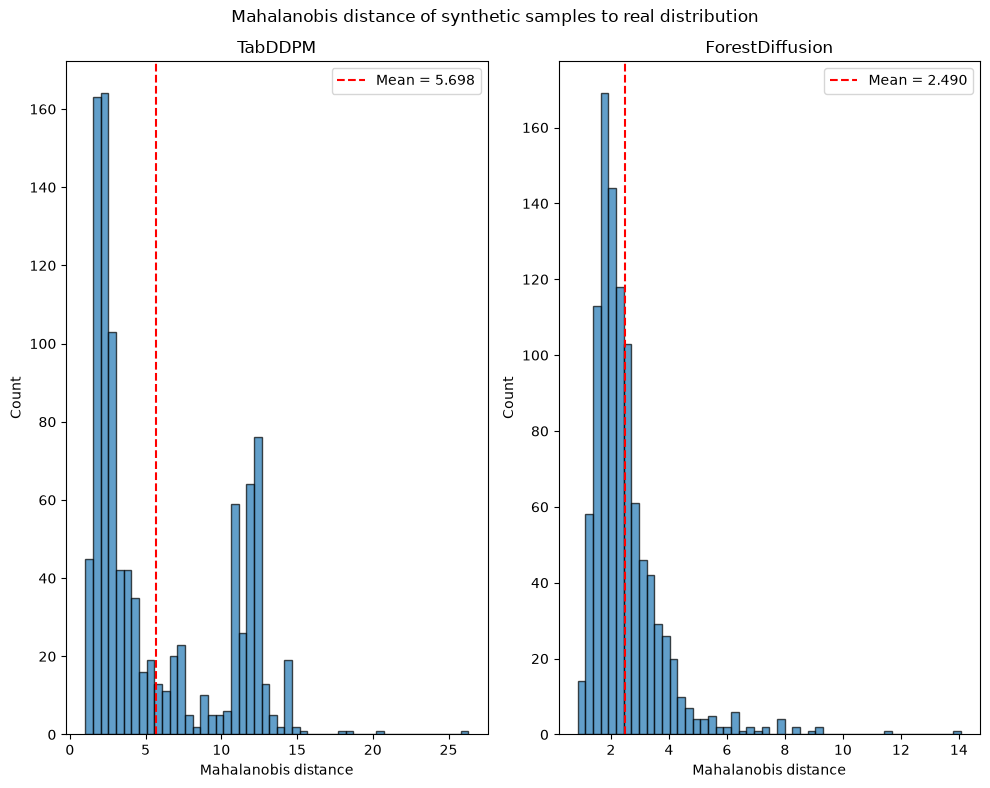

In [39]:
import os
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(model_order), figsize=(10, 8))
axes = axes.ravel()

for ax, (name, res) in zip(axes, mahalanobis_results.items()):
    ax.hist(res["distances"], bins=50, edgecolor="black", alpha=0.7)
    ax.axvline(res["mean"], color="red", linestyle="--", label=f"Mean = {res['mean']:.3f}")
    ax.set_title(name)
    ax.set_xlabel("Mahalanobis distance")
    ax.set_ylabel("Count")
    ax.legend()

for j in range(len(mahalanobis_results), len(axes)):
    axes[j].axis("off")

plt.suptitle("Mahalanobis distance of synthetic samples to real distribution", fontsize=12)
plt.tight_layout()

ROOT = os.getcwd()
os.makedirs(os.path.join(ROOT, "figures"), exist_ok=True)
plt.savefig(
    os.path.join(ROOT, "figures", "mahalanobis_cancer_by_model.png"),
    dpi=150,
    bbox_inches="tight"
)

plt.show()


In [40]:
if 'metric_subsample_df' not in globals():
    METRIC_SAMPLE_SIZE = 2000
    METRIC_RANDOM_STATE = 42
    def metric_subsample_df(df, n_max=METRIC_SAMPLE_SIZE, random_state=METRIC_RANDOM_STATE):
        if len(df) <= n_max:
            return df.reset_index(drop=True)
        return df.sample(n=n_max, random_state=random_state).reset_index(drop=True)

from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment
import numpy as np
import pandas as pd

def pairwise_mahalanobis(real_matrix, synth_matrix, inv_cov):
    return cdist(real_matrix, synth_matrix, metric="mahalanobis", VI=inv_cov)

# Compute numeric features (exclude target)
num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
target_col = "class"
if target_col in num_cols:
    num_cols.remove(target_col)

real_matrix = metric_subsample_df(data)[num_cols].to_numpy(dtype=float)

# Compute real covariance inverse (if not already done)
if 'inv_cov_real' not in globals():
    cov_real = np.cov(real_matrix, rowvar=False)
    inv_cov_real = np.linalg.inv(cov_real + 1e-6 * np.eye(cov_real.shape[0]))

hungarian_results = {}
available_models = []

# Updated for your models
for name in ["TabDDPM", "ForestDiffusion"]:
    if name in synth_source:
        synth_df = synth_source[name][num_cols].copy()
        synth_numeric = synth_df.to_numpy(dtype=float)

        # REMOVED size check - use min(real, synth) samples
        n_matches = min(real_matrix.shape[0], synth_numeric.shape[0])
        print(f"✓ Processing {name} ({n_matches} matches from {synth_numeric.shape[0]} synth samples)")

        D = pairwise_mahalanobis(real_matrix, synth_numeric, inv_cov_real)
        row_ind, col_ind = linear_sum_assignment(D)
        matched_distances = D[row_ind, col_ind]

        hungarian_results[name] = {
            "total_distance": float(matched_distances.sum()),
            "mean_distance_per_match": float(matched_distances.mean()),
            "median_distance_per_match": float(np.median(matched_distances)),
            "std_distance_per_match": float(np.std(matched_distances)),
            "max_distance_per_match": float(matched_distances.max()),
            "matched_distances": matched_distances,
            "row_ind": row_ind,
            "col_ind": col_ind,
            "n_matches": n_matches
        }
        available_models.append(name)
    else:
        print(f"✗ {name} not in synthetic source. Available: {list(synth_source.keys())}")

# Summary table (only for successful models)
if hungarian_results:
    hungarian_summary = pd.DataFrame(
        {
            name: [
                r["mean_distance_per_match"],
                r["median_distance_per_match"],
                r["std_distance_per_match"],
                r["max_distance_per_match"],
                r["n_matches"]
            ]
            for name, r in hungarian_results.items()
        },
        index=[
            "mean_distance_per_match",
            "median_distance_per_match",
            "std_distance_per_match",
            "max_distance_per_match",
            "n_matches"
        ],
    ).T

    hungarian_summary.index.name = "Model"
    hungarian_summary = hungarian_summary.sort_values("mean_distance_per_match")

    print("Hungarian matching using Mahalanobis distance (lower is better):")
    display(hungarian_summary)
else:
    print("No valid models found for Mahalanobis Hungarian matching.")


✓ Processing TabDDPM (1000 matches from 1000 synth samples)
✓ Processing ForestDiffusion (1000 matches from 1000 synth samples)
Hungarian matching using Mahalanobis distance (lower is better):


,mean_distance_per_match,median_distance_per_match,std_distance_per_match,max_distance_per_match,n_matches
Model,,,,,
ForestDiffusion,1.307832,1.066825,0.947632,10.011533,1000.0
TabDDPM,4.284836,1.848010,4.155762,21.365905,1000.0


In [41]:
if 'metric_subsample_df' not in globals():
    METRIC_SAMPLE_SIZE = 2000
    METRIC_RANDOM_STATE = 42
    def metric_subsample_df(df, n_max=METRIC_SAMPLE_SIZE, random_state=METRIC_RANDOM_STATE):
        if len(df) <= n_max:
            return df.reset_index(drop=True)
        return df.sample(n=n_max, random_state=random_state).reset_index(drop=True)

from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment
import numpy as np
import pandas as pd

def pairwise_mahalanobis(real_matrix, synth_matrix, inv_cov):
    return cdist(real_matrix, synth_matrix, metric="mahalanobis", VI=inv_cov)

# Smart synthetic source detection
if "synthetic_outputs" in globals():
    synth_source = synthetic_outputs
elif "synthetic_data" in globals():
    synth_source = synthetic_data
elif "synthetic_tables" in globals():
    synth_source = synthetic_outputs
else:
    raise NameError("No synthetic source found. Expected `synthetic_outputs`, `synthetic_data`, or `synthetic_tables`.")

# Compute numeric features (exclude target)
num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
target_col = "class"
if target_col in num_cols:
    num_cols.remove(target_col)

real_matrix = metric_subsample_df(data)[num_cols].to_numpy(dtype=float)

# Compute real covariance inverse (if not already done)
if 'inv_cov_real' not in globals():
    cov_real = np.cov(real_matrix, rowvar=False)
    inv_cov_real = np.linalg.inv(cov_real + 1e-6 * np.eye(cov_real.shape[0]))

hungarian_results = {}
available_models = []

# Your GAN models
for name in ["TabDDPM", "ForestDiffusion"]:
    if name in synth_source:
        synth_df = synth_source[name][num_cols].copy()
        synth_numeric = synth_df.to_numpy(dtype=float)

        # REMOVED size check - Hungarian handles rectangular matrices automatically
        n_real, n_synth = real_matrix.shape[0], synth_numeric.shape[0]
        n_matches = min(n_real, n_synth)
        print(f"✓ Processing {name}: {n_real} real vs {n_synth} synth → {n_matches} matches")

        D = pairwise_mahalanobis(real_matrix, synth_numeric, inv_cov_real)
        row_ind, col_ind = linear_sum_assignment(D)
        matched_distances = D[row_ind, col_ind]

        hungarian_results[name] = {
            "total_distance": float(matched_distances.sum()),
            "mean_distance_per_match": float(matched_distances.mean()),
            "median_distance_per_match": float(np.median(matched_distances)),
            "std_distance_per_match": float(np.std(matched_distances)),
            "max_distance_per_match": float(matched_distances.max()),
            "matched_distances": matched_distances,
            "row_ind": row_ind,
            "col_ind": col_ind,
            "n_real": n_real,
            "n_synth": n_synth,
            "n_matches": n_matches
        }
        available_models.append(name)
    else:
        print(f"✗ {name} not in synthetic source. Available: {list(synth_source.keys())}")

# Summary table (only for successful models)
if hungarian_results:
    hungarian_summary = pd.DataFrame(
        {
            name: [
                r["mean_distance_per_match"],
                r["median_distance_per_match"],
                r["std_distance_per_match"],
                r["max_distance_per_match"],
                r["n_matches"]
            ]
            for name, r in hungarian_results.items()
        },
        index=[
            "mean_distance_per_match",
            "median_distance_per_match",
            "std_distance_per_match",
            "max_distance_per_match",
            "n_matches"
        ],
    ).T

    hungarian_summary.index.name = "Model"
    hungarian_summary = hungarian_summary.sort_values("mean_distance_per_match")

    print("Hungarian matching using Mahalanobis distance (lower is better):")
    display(hungarian_summary)
else:
    print("No valid models found for Mahalanobis Hungarian matching.")


✓ Processing TabDDPM: 1000 real vs 1000 synth → 1000 matches
✓ Processing ForestDiffusion: 1000 real vs 1000 synth → 1000 matches
Hungarian matching using Mahalanobis distance (lower is better):


,mean_distance_per_match,median_distance_per_match,std_distance_per_match,max_distance_per_match,n_matches
Model,,,,,
ForestDiffusion,1.307832,1.066825,0.947632,10.011533,1000.0
TabDDPM,4.284836,1.848010,4.155762,21.365905,1000.0


In [42]:
if 'metric_subsample_df' not in globals():
    METRIC_SAMPLE_SIZE = 2000
    METRIC_RANDOM_STATE = 42
    def metric_subsample_df(df, n_max=METRIC_SAMPLE_SIZE, random_state=METRIC_RANDOM_STATE):
        if len(df) <= n_max:
            return df.reset_index(drop=True)
        return df.sample(n=n_max, random_state=random_state).reset_index(drop=True)

import numpy as np
import pandas as pd

def greedy_one_to_one_matching(D):
    n_rows, n_cols = D.shape
    n = min(n_rows, n_cols)

    used_rows = set()
    used_cols = set()
    pairs = []

    for _ in range(n):
        best_val = np.inf
        best_i, best_j = -1, -1

        for i in range(n_rows):
            if i in used_rows:
                continue
            for j in range(n_cols):
                if j in used_cols:
                    continue
                if D[i, j] < best_val:
                    best_val = D[i, j]
                    best_i, best_j = i, j

        if best_i < 0:
            break

        used_rows.add(best_i)
        used_cols.add(best_j)
        pairs.append((best_i, best_j, best_val))

    distances = np.array([p[2] for p in pairs], dtype=float)
    total_distance = float(distances.sum()) if len(distances) else np.nan
    mean_distance = float(distances.mean()) if len(distances) else np.nan
    return total_distance, mean_distance, pairs

# Smart synthetic source detection (same as previous cells)
if "synthetic_outputs" in globals():
    synth_source = synthetic_outputs
elif "synthetic_data" in globals():
    synth_source = synthetic_data
elif "synthetic_tables" in globals():
    synth_source = synthetic_outputs
else:
    raise NameError("No synthetic source found.")

# Use same numeric columns as previous Mahalanobis cell
num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
target_col = "class"
if target_col in num_cols:
    num_cols.remove(target_col)

real_matrix = metric_subsample_df(data)[num_cols].to_numpy(dtype=float)

greedy_results = {}
comparison_rows = []

# Your GAN models
for name in ["TabDDPM", "ForestDiffusion"]:
    if name in synth_source and name in hungarian_results:
        synth_df = synth_source[name][num_cols].copy()
        synth_numeric = synth_df.to_numpy(dtype=float)

        print(f"✓ Processing {name}: {real_matrix.shape[0]} real vs {synth_numeric.shape[0]} synth")

        D = pairwise_mahalanobis(real_matrix, synth_numeric, inv_cov_real)
        total_g, mean_g, _ = greedy_one_to_one_matching(D)

        greedy_results[name] = {
            "total_distance": total_g,
            "mean_distance": mean_g
        }

        # Compare with Hungarian results
        h_total = hungarian_results[name]["total_distance"]
        h_mean = hungarian_results[name]["mean_distance_per_match"]

        comparison_rows.append({
            "Model": name,
            "Greedy total": total_g,
            "Hungarian total": h_total,
            "Greedy mean": mean_g,
            "Hungarian mean": h_mean,
            "Total diff (Greedy - Hungarian)": total_g - h_total,
            "Mean diff (Greedy - Hungarian)": mean_g - h_mean,
        })
        print(f"  Greedy mean: {mean_g:.4f} vs Hungarian: {h_mean:.4f} (diff: {mean_g-h_mean:.4f})")
    else:
        print(f"✗ Skipping {name} (missing data or Hungarian results)")

# Greedy summary
if greedy_results:
    greedy_summary = pd.DataFrame({
        name: [greedy_results[name]["total_distance"], greedy_results[name]["mean_distance"]]
        for name in greedy_results
    }, index=["total_distance", "mean_distance"]).T
    greedy_summary.index.name = "Model"

    print("Greedy one-to-one matching (Mahalanobis distance):")
    display(greedy_summary)

    print("\nComparison: Greedy vs Hungarian (lower is better; Greedy should be >= Hungarian):")
    comparison_df = pd.DataFrame(comparison_rows).set_index("Model")
    display(comparison_df)
else:
    print("No valid models for greedy matching.")


✓ Processing TabDDPM: 1000 real vs 1000 synth
  Greedy mean: 4.5721 vs Hungarian: 4.2848 (diff: 0.2872)
✓ Processing ForestDiffusion: 1000 real vs 1000 synth
  Greedy mean: 1.4320 vs Hungarian: 1.3078 (diff: 0.1242)
Greedy one-to-one matching (Mahalanobis distance):


,total_distance,mean_distance
Model,,
TabDDPM,4572.058298,4.572058
ForestDiffusion,1432.026985,1.432027



Comparison: Greedy vs Hungarian (lower is better; Greedy should be >= Hungarian):


,Greedy total,Hungarian total,Greedy mean,Hungarian mean,Total diff (Greedy - Hungarian),Mean diff (Greedy - Hungarian)
Model,,,,,,
TabDDPM,4572.058298,4284.835836,4.572058,4.284836,287.222462,0.287222
ForestDiffusion,1432.026985,1307.832355,1.432027,1.307832,124.194630,0.124195


In [43]:
if 'metric_subsample_df' not in globals():
    METRIC_SAMPLE_SIZE = 2000
    METRIC_RANDOM_STATE = 42
    def metric_subsample_df(df, n_max=METRIC_SAMPLE_SIZE, random_state=METRIC_RANDOM_STATE):
        if len(df) <= n_max:
            return df.reset_index(drop=True)
        return df.sample(n=n_max, random_state=random_state).reset_index(drop=True)

import numpy as np
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment

# Use your data and dynamic target detection
real_df = metric_subsample_df(data)
target_col = "class"
feature_cols = [c for c in data.select_dtypes(include=[np.number]).columns if c != target_col]

X_real = real_df[feature_cols].to_numpy(dtype=float)

# Covariance with regularization (pinv is better than inv for stability)
cov_real = np.cov(X_real, rowvar=False)
inv_cov_real = np.linalg.pinv(cov_real + 1e-6 * np.eye(cov_real.shape[0]))

# Your GAN models
model_order = ["TabDDPM", "ForestDiffusion"]
hungarian_results = {}

for model_name in model_order:
    if model_name in synth_source:
        synth_df = synth_source[model_name][real_df.columns].copy()
        X_synth = synth_df[feature_cols].to_numpy(dtype=float)

        print(f"✓ Processing {model_name}: {X_real.shape[0]} real vs {X_synth.shape[0]} synth")

        D = cdist(X_real, X_synth, metric="mahalanobis", VI=inv_cov_real)
        D = np.nan_to_num(D, nan=1e10, posinf=1e10, neginf=1e10)

        # Hungarian handles rectangular matrices automatically
        row_ind, col_ind = linear_sum_assignment(D)
        dists = D[row_ind, col_ind]

        hungarian_results[model_name] = {
            "row_ind": row_ind,
            "col_ind": col_ind,
            "dists": dists
        }

        # Top matches
        order = np.argsort(dists)
        top_k = min(20, len(order))
        print(f"\n{model_name} - Top {top_k} Hungarian matchings (lowest Mahalanobis distance):")
        for rank, k in enumerate(order[:top_k], 1):
            print(f"{rank:02d}. R{row_ind[k] + 1} -> S{col_ind[k] + 1}   distance = {dists[k]:.4f}")
    else:
        print(f"✗ {model_name} not in synthetic source. Available: {list(synth_source.keys())}")

# Summary stats
if hungarian_results:
    summary_stats = pd.DataFrame({
        model_name: {
            "mean_dist": np.mean(hungarian_results[model_name]["dists"]),
            "median_dist": np.median(hungarian_results[model_name]["dists"]),
            "min_dist": np.min(hungarian_results[model_name]["dists"])
        }
        for model_name in hungarian_results
    }).T.sort_values("mean_dist")
    print("\nSummary Mahalanobis distances (lower is better):")
    display(summary_stats)


✓ Processing TabDDPM: 1000 real vs 1000 synth

TabDDPM - Top 20 Hungarian matchings (lowest Mahalanobis distance):
01. R273 -> S988   distance = 0.4712
02. R381 -> S769   distance = 0.4838
03. R801 -> S278   distance = 0.5069
04. R602 -> S660   distance = 0.5078
05. R988 -> S255   distance = 0.5135
06. R618 -> S511   distance = 0.5298
07. R680 -> S482   distance = 0.5518
08. R713 -> S841   distance = 0.5574
09. R520 -> S533   distance = 0.5589
10. R933 -> S622   distance = 0.5663
11. R245 -> S90   distance = 0.5764
12. R724 -> S931   distance = 0.5876
13. R222 -> S472   distance = 0.5987
14. R839 -> S630   distance = 0.6018
15. R111 -> S430   distance = 0.6032
16. R377 -> S808   distance = 0.6034
17. R748 -> S871   distance = 0.6118
18. R54 -> S91   distance = 0.6159
19. R562 -> S683   distance = 0.6471
20. R805 -> S545   distance = 0.6476
✓ Processing ForestDiffusion: 1000 real vs 1000 synth

ForestDiffusion - Top 20 Hungarian matchings (lowest Mahalanobis distance):
01. R480 -> S865 

,mean_dist,median_dist,min_dist
ForestDiffusion,1.307832,1.066825,0.093491
TabDDPM,4.284836,1.848010,0.471186


In [44]:
if 'metric_subsample_df' not in globals():
    METRIC_SAMPLE_SIZE = 2000
    METRIC_RANDOM_STATE = 42
    def metric_subsample_df(df, n_max=METRIC_SAMPLE_SIZE, random_state=METRIC_RANDOM_STATE):
        if len(df) <= n_max:
            return df.reset_index(drop=True)
        return df.sample(n=n_max, random_state=random_state).reset_index(drop=True)

import numpy as np
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment
import pandas as pd

# Smart synthetic source detection
if "synthetic_outputs" in globals():
    synth_source = synthetic_outputs
elif "synthetic_data" in globals():
    synth_source = synthetic_data
elif "synthetic_tables" in globals():
    synth_source = synthetic_outputs
else:
    raise NameError("No synthetic source found.")

# Use your data with dynamic target detection
real_df = metric_subsample_df(data)
target_col = "class"
feature_cols = [c for c in data.select_dtypes(include=[np.number]).columns if c != target_col]

X_real = real_df[feature_cols].to_numpy(dtype=float)

# Covariance with regularization
cov_real = np.cov(X_real, rowvar=False)
inv_cov_real = np.linalg.pinv(cov_real + 1e-6 * np.eye(cov_real.shape[0]))

# Your GAN models
model_order = ["TabDDPM", "ForestDiffusion"]

for model_name in model_order:
    if model_name in synth_source:
        synth_df = synth_source[model_name][real_df.columns].copy()
        X_synth = synth_df[feature_cols].to_numpy(dtype=float)

        print(f"\n{'='*60}")
        print(f"{model_name}: {X_real.shape[0]} real vs {X_synth.shape[0]} synth")
        print(f"{'='*60}")

        D = cdist(X_real, X_synth, metric="mahalanobis", VI=inv_cov_real)
        D = np.nan_to_num(D, nan=1e10, posinf=1e10, neginf=1e10)

        # Simplified Hungarian (handles rectangular matrices automatically)
        row_ind, col_ind = linear_sum_assignment(D)
        dists = D[row_ind, col_ind]

        r_to_match = {r: (s, d) for r, s, d in zip(row_ind, col_ind, dists)}

        print(f"{model_name} - Hungarian mappings for R1 to R20:")
        for r in range(20):
            if r in r_to_match:
                s, dist = r_to_match[r]
                print(f"R{r+1} -> S{s+1}   distance = {dist:.4f}")
            else:
                print(f"R{r+1} -> No match found")

        # Summary stats for this model
        print(f"  Summary: mean={np.mean(dists):.4f}, median={np.median(dists):.4f}, min={np.min(dists):.4f}")
    else:
        print(f"✗ {model_name} not in synthetic source. Available: {list(synth_source.keys())}")



TabDDPM: 1000 real vs 1000 synth
TabDDPM - Hungarian mappings for R1 to R20:
R1 -> S868   distance = 1.4034
R2 -> S832   distance = 2.4341
R3 -> S65   distance = 1.1129
R4 -> S367   distance = 1.2026
R5 -> S550   distance = 8.8850
R6 -> S727   distance = 1.4149
R7 -> S998   distance = 12.1324
R8 -> S205   distance = 1.8416
R9 -> S597   distance = 1.3241
R10 -> S541   distance = 1.1090
R11 -> S419   distance = 12.7367
R12 -> S254   distance = 2.0569
R13 -> S929   distance = 1.7496
R14 -> S288   distance = 2.5380
R15 -> S859   distance = 1.0484
R16 -> S764   distance = 1.8364
R17 -> S812   distance = 10.0714
R18 -> S424   distance = 1.6298
R19 -> S501   distance = 12.5776
R20 -> S146   distance = 9.8490
  Summary: mean=4.2848, median=1.8480, min=0.4712

ForestDiffusion: 1000 real vs 1000 synth
ForestDiffusion - Hungarian mappings for R1 to R20:
R1 -> S659   distance = 1.7012
R2 -> S248   distance = 1.0615
R3 -> S924   distance = 1.0591
R4 -> S71   distance = 1.2185
R5 -> S199   distance


Processing TabDDPM: 1000 real vs 1000 synth


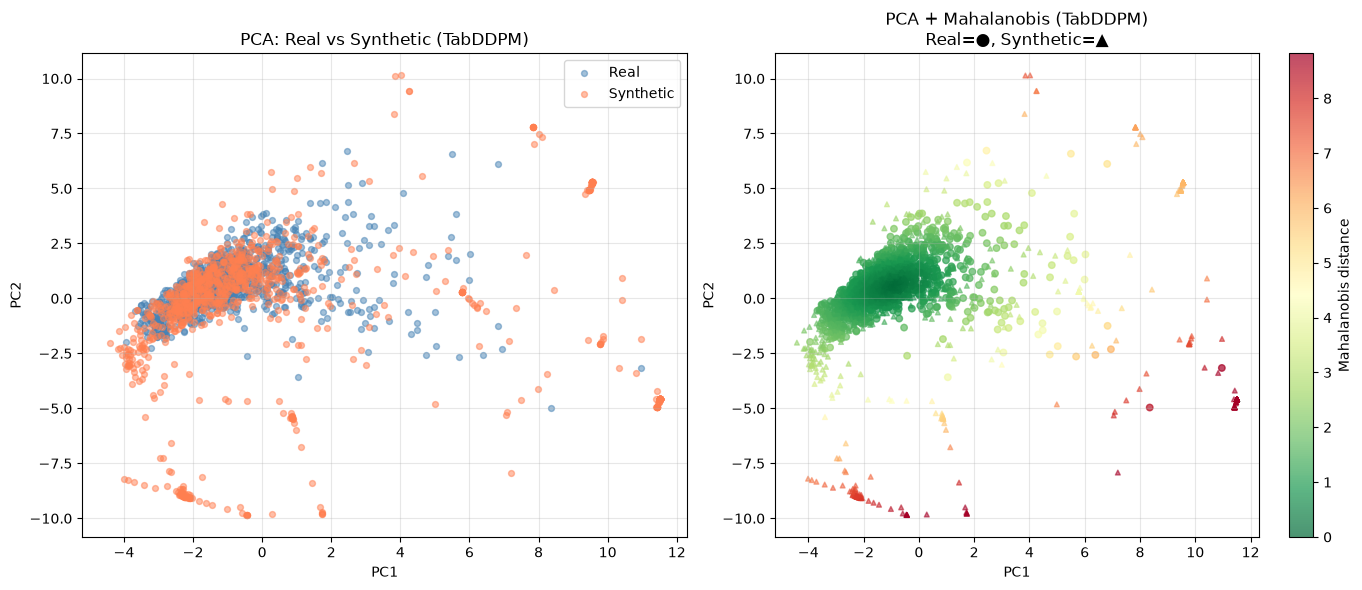

  Real mean MD: 1.1128, Synth mean MD: 3.0257, Delta: +1.9129

Processing ForestDiffusion: 1000 real vs 1000 synth


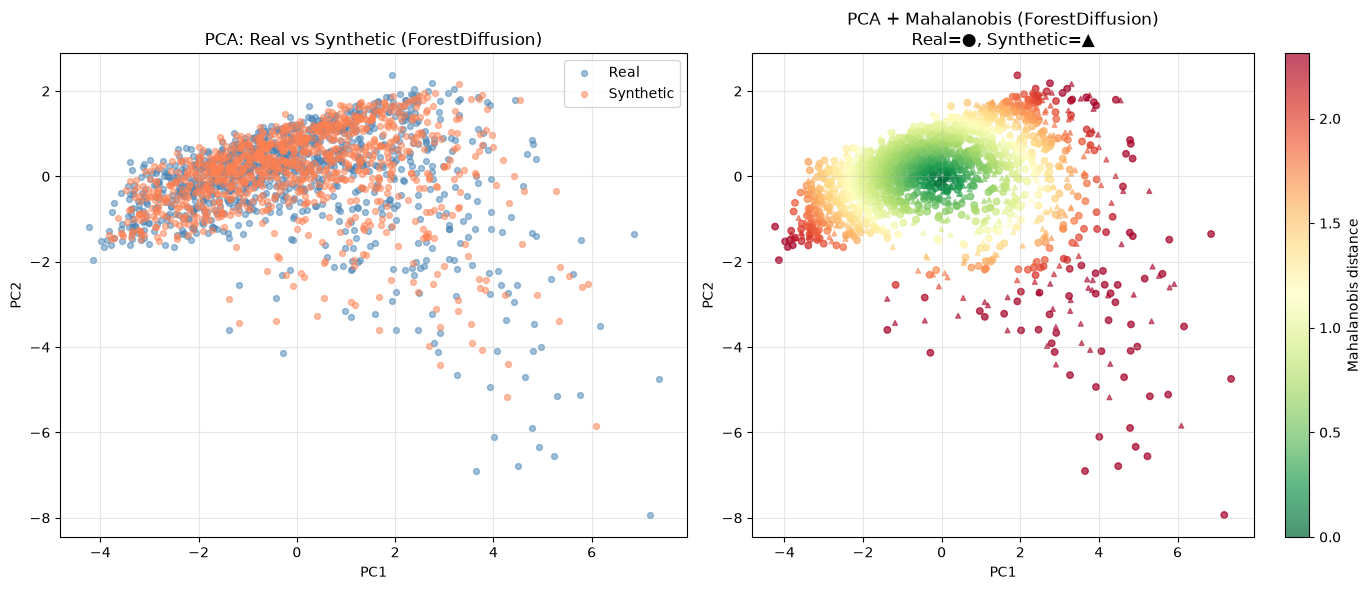

  Real mean MD: 1.1788, Synth mean MD: 1.0910, Delta: -0.0878

Summary: PCA 2D Mahalanobis distances (lower Synth_Mean_MD_2D = better):


,Model,Real_Mean_MD_2D,Synth_Mean_MD_2D,Delta_Synth_minus_Real
1,ForestDiffusion,1.178807,1.091032,-0.087775
0,TabDDPM,1.112763,3.025691,1.912928


In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.linalg import inv, LinAlgError
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

def _mahal_dist_2d(X, mu, inv_cov):
    delta = X - mu
    return np.sqrt(np.maximum(np.einsum("ij,jk,ik->i", delta, inv_cov, delta), 0.0))

# Smart synthetic source detection
if "synthetic_outputs" in globals():
    synth_source = synthetic_outputs
elif "synthetic_data" in globals():
    synth_source = synthetic_data
elif "synthetic_tables" in globals():
    synth_source = synthetic_outputs
else:
    raise NameError("No synthetic source found.")

# Your data and GAN models
model_order = ["TabDDPM", "ForestDiffusion"]
real_df = data.copy()
target_col = "class"
feature_cols = [c for c in real_df.select_dtypes(include=[np.number]).columns if c != target_col]

X_r = real_df[feature_cols].to_numpy(dtype=float)
scaler = StandardScaler().fit(X_r)
X_r_s = scaler.transform(X_r)

rows = []

for model_name in model_order:
    if model_name not in synth_source:
        print(f"✗ {model_name} not in synthetic source, skipping.")
        continue

    synth_df = synth_source[model_name][real_df.columns].copy()
    X_s = synth_df[feature_cols].to_numpy(dtype=float)
    X_s_s = scaler.transform(X_s)

    print(f"\n{'='*60}")
    print(f"Processing {model_name}: {X_r.shape[0]} real vs {X_s.shape[0]} synth")
    print(f"{'='*60}")

    # PCA on combined data
    X_all = np.vstack([X_r_s, X_s_s])
    Z_all = PCA(n_components=2, random_state=42).fit_transform(X_all)

    n_r = len(X_r_s)
    Z_r = Z_all[:n_r]
    Z_s = Z_all[n_r:]

    # Mahalanobis in PCA space (real distribution reference)
    mu_z = np.mean(Z_r, axis=0)
    cov_z = np.cov(Z_r, rowvar=False)
    reg = 1e-6

    try:
        inv_cov_z = inv(cov_z + reg * np.eye(2))
    except LinAlgError:
        inv_cov_z = inv(cov_z + 10 * reg * np.eye(2))

    d_r = _mahal_dist_2d(Z_r, mu_z, inv_cov_z)
    d_s = _mahal_dist_2d(Z_s, mu_z, inv_cov_z)

    # Plot 1: PCA scatter
    fig, axes = plt.subplots(1, len(model_order), figsize=(14, 6))

    ax = axes[0]
    ax.scatter(Z_r[:, 0], Z_r[:, 1], c="steelblue", alpha=0.5, s=18, label="Real")
    ax.scatter(Z_s[:, 0], Z_s[:, 1], c="coral", alpha=0.5, s=18, label="Synthetic")
    ax.set_title(f"PCA: Real vs Synthetic ({model_name})")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Plot 2: Mahalanobis distance color-coded
    ax = axes[1]
    vmax = np.percentile(np.hstack([d_r, d_s]), 95)
    sc = ax.scatter(
        Z_r[:, 0], Z_r[:, 1], c=d_r, cmap="RdYlGn_r", alpha=0.7, s=22, marker="o", vmin=0, vmax=vmax
    )
    ax.scatter(
        Z_s[:, 0], Z_s[:, 1], c=d_s, cmap="RdYlGn_r", alpha=0.55, s=12, marker="^", vmin=0, vmax=vmax
    )
    plt.colorbar(sc, ax=ax, label="Mahalanobis distance")
    ax.set_title(f"PCA + Mahalanobis ({model_name})\nReal=●, Synthetic=▲")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Stats
    print(f"  Real mean MD: {d_r.mean():.4f}, Synth mean MD: {d_s.mean():.4f}, Delta: {d_s.mean()-d_r.mean():+.4f}")

    rows.append({
        "Model": model_name,
        "Real_Mean_MD_2D": float(d_r.mean()),
        "Synth_Mean_MD_2D": float(d_s.mean()),
        "Delta_Synth_minus_Real": float(d_s.mean() - d_r.mean())
    })

# Summary table
if rows:
    summary_df = pd.DataFrame(rows).sort_values("Synth_Mean_MD_2D")
    print("\nSummary: PCA 2D Mahalanobis distances (lower Synth_Mean_MD_2D = better):")
    display(summary_df)
else:
    print("No valid models found.")


In [46]:
import pandas as pd
import numpy as np

def export_all_models_hungarian_mahalanobis_excel(
    real_df: pd.DataFrame,
    synthetic_data: dict,
    hungarian_results: dict,
    num_cols: list,
    filename: str = "Hungarian_Mahalanobis_MAGIC_TabDDPM_ForestDiffusion.xlsx"
):
    # Updated for your GAN models
    model_order = ["TabDDPM", "ForestDiffusion"]

    summary_rows = []

    with pd.ExcelWriter(filename, engine="openpyxl") as writer:
        for model_name in model_order:
            if model_name not in synthetic_data or model_name not in hungarian_results:
                print(f"Skipping {model_name}: missing data or results")
                continue

            synth_df = synthetic_data[model_name].copy()
            _common = [c for c in real_df.columns if c in synth_df.columns]

            synth_df = synth_df[_common]

            row_ind = hungarian_results[model_name]["row_ind"]
            col_ind = hungarian_results[model_name]["col_ind"]

            # Flexible distance key detection
            if "dists" in hungarian_results[model_name]:
                matched_distances = hungarian_results[model_name]["dists"]
            elif "distances" in hungarian_results[model_name]:
                matched_distances = hungarian_results[model_name]["distances"]
            elif "matched_distances" in hungarian_results[model_name]:
                matched_distances = hungarian_results[model_name]["matched_distances"]
            else:
                print(f"No distance array found for {model_name}, skipping")
                continue

            records = []
            for r_i, s_i, dist in zip(row_ind, col_ind, matched_distances):
                rec = {
                    "Model": model_name,
                    "Real_Index": int(r_i),
                    "Synthetic_Index": int(s_i),
                    "Real_Label": f"R{int(r_i)+1}",
                    "Synthetic_Label": f"S{int(s_i)+1}",
                    "Mahalanobis_Distance": float(dist),
                }
                for c in num_cols:
                    rec[f"Real_{c}"] = real_df.iloc[r_i][c]
                    rec[f"Synth_{c}"] = synth_df.iloc[s_i][c]
                records.append(rec)

            matched_df = pd.DataFrame(records)
            sheet_name = model_name[:31]  # Excel sheet name limit
            matched_df.to_excel(writer, sheet_name=sheet_name, index=False)
            print(f"✓ Exported {len(matched_df)} matches for {model_name}")

            summary_rows.append({
                "Model": model_name,
                "Num_Matches": len(matched_df),
                "Mean_Distance": float(np.mean(matched_distances)),
                "Median_Distance": float(np.median(matched_distances)),
                "Std_Distance": float(np.std(matched_distances)),
                "Min_Distance": float(np.min(matched_distances)),
                "Max_Distance": float(np.max(matched_distances)),
            })

        if summary_rows:
            summary_df = pd.DataFrame(summary_rows).sort_values("Mean_Distance")
            summary_df.to_excel(writer, sheet_name="Summary", index=False)
            print("\nSummary table:")
            display(summary_df)

    print(f"\n✅ Excel file created: {filename}")

# ---- Run ----
# Smart source detection + your dataset
if "synthetic_outputs" in globals():
    synth_source = synthetic_outputs
elif "synthetic_data" in globals():
    synth_source = synthetic_data
elif "synthetic_tables" in globals():
    synth_source = synthetic_outputs
else:
    raise NameError("No synthetic source found.")

real_df = data.copy()
target_col = "class"
num_cols = [c for c in real_df.select_dtypes(include=[np.number]).columns if c != target_col]

print(f"Dataset: {len(real_df)} samples, {len(num_cols)} numeric features")
print(f"Target column: {target_col}")

export_all_models_hungarian_mahalanobis_excel(
    real_df=real_df,
    synthetic_data=synth_source,
    hungarian_results=hungarian_results,
    num_cols=num_cols,
    filename="Hungarian_Mahalanobis_MAGIC_TabDDPM_ForestDiffusion.xlsx"
)


Dataset: 1000 samples, 10 numeric features
Target column: class
✓ Exported 1000 matches for TabDDPM
✓ Exported 1000 matches for ForestDiffusion

Summary table:


,Model,Num_Matches,Mean_Distance,Median_Distance,Std_Distance,Min_Distance,Max_Distance
1,ForestDiffusion,1000,1.307832,1.066825,0.947632,0.093491,10.011533
0,TabDDPM,1000,4.284836,1.848010,4.155762,0.471186,21.365905



✅ Excel file created: Hungarian_Mahalanobis_MAGIC_TabDDPM_ForestDiffusion.xlsx


# 8. Privacy Metrics: Membership Inference Attack (MIA)


In [47]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score

def model_loss_per_sample(model, X, y, eps=1e-15):
    proba = model.predict_proba(X)
    n = len(y)
    y_idx = y.astype(int).clip(0, proba.shape[1] - 1)
    p_true = proba[np.arange(n), y_idx] + eps
    return -np.log(p_true)

def privacy_metrics_mia(model, X_train, y_train, X_test, y_test):
    scaler = StandardScaler().fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_test_s = scaler.transform(X_test)

    model.fit(X_train_s, y_train)

    loss_train = model_loss_per_sample(model, X_train_s, y_train)
    loss_test = model_loss_per_sample(model, X_test_s, y_test)

    scores = -np.concatenate([loss_train, loss_test])
    labels = np.concatenate([np.ones(len(loss_train)), np.zeros(len(loss_test))])

    fpr, tpr, _ = roc_curve(labels, scores, pos_label=1)
    auc = roc_auc_score(labels, scores)
    advantage = np.max(tpr - fpr)

    idx_fpr_001 = np.searchsorted(fpr, 0.01, side="right") - 1
    idx_fpr_001 = max(0, idx_fpr_001)
    tpr_at_fpr_001 = tpr[idx_fpr_001] if idx_fpr_001 < len(tpr) else float("nan")

    return {"AUC": auc, "Advantage": advantage, "TPR_at_FPR_001": tpr_at_fpr_001}

# Setup with label encoding
target_col = "class"
feature_cols = [c for c in data.select_dtypes(include=[np.number]).columns if c != target_col]

real_df = data.copy()
model_order = ["TabDDPM", "ForestDiffusion"]

# Encode target labels once
le = LabelEncoder()
y_real_encoded = le.fit_transform(real_df[target_col])

results = []

for model_name in model_order:
    if model_name not in synth_source:
        print(f"✗ {model_name} not in synthetic source")
        continue

    print(f"\n{'='*50}")
    print(f"MIA for {model_name}")
    print(f"{'='*50}")

    synth_df = synth_source[model_name][real_df.columns].copy()

    # Encode synthetic labels using same encoder
    y_synth_encoded = le.transform(synth_df[target_col])

    X_train = real_df[feature_cols].to_numpy(dtype=float)
    y_train = y_real_encoded

    X_test = synth_df[feature_cols].to_numpy(dtype=float)
    y_test = y_synth_encoded

    model = LogisticRegression(max_iter=1000, random_state=42)
    metrics = privacy_metrics_mia(model, X_train, y_train, X_test, y_test)

    metrics["Model"] = model_name
    results.append(metrics)

    print(f"  AUC: {metrics['AUC']:.4f}")
    print(f"  Advantage: {metrics['Advantage']:.4f}")
    print(f"  TPR@FPR=0.01: {metrics['TPR_at_FPR_001']:.4f}")

# Summary
if results:
    summary_df = pd.DataFrame(results).set_index("Model")
    print("\n MIA Results (LOWER AUC = BETTER privacy):")
    display(summary_df.sort_values("AUC"))



MIA for TabDDPM
  AUC: 0.6389
  Advantage: 0.3070
  TPR@FPR=0.01: 0.0010

MIA for ForestDiffusion
  AUC: 0.4929
  Advantage: 0.0160
  TPR@FPR=0.01: 0.0210

 MIA Results (LOWER AUC = BETTER privacy):


,AUC,Advantage,TPR_at_FPR_001
Model,,,
ForestDiffusion,0.492859,0.016,0.021
TabDDPM,0.638859,0.307,0.001


In [48]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, roc_auc_score

def privacy_metrics_mia_mahalanobis(X_train, X_test):
    scaler = StandardScaler().fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_test_s = scaler.transform(X_test)

    mu = np.mean(X_train_s, axis=0)
    cov = np.cov(X_train_s, rowvar=False)
    cov = cov + 1e-6 * np.eye(cov.shape[0])
    cov_inv = np.linalg.pinv(cov)

    diff_train = X_train_s - mu
    diff_test = X_test_s - mu

    md_train = np.sqrt(np.maximum(np.sum((diff_train @ cov_inv) * diff_train, axis=1), 0.0))
    md_test = np.sqrt(np.maximum(np.sum((diff_test @ cov_inv) * diff_test, axis=1), 0.0))

    scores = -np.concatenate([md_train, md_test])
    labels = np.concatenate([np.ones(len(md_train)), np.zeros(len(md_test))])

    fpr, tpr, _ = roc_curve(labels, scores, pos_label=1)
    auc = roc_auc_score(labels, scores)
    advantage = np.max(tpr - fpr)

    idx = np.searchsorted(fpr, 0.01, side="right") - 1
    idx = max(0, idx)
    tpr_at_fpr_001 = tpr[idx] if idx < len(tpr) else float("nan")

    return {
        "AUC": float(auc),
        "Advantage": float(advantage),
        "TPR_at_FPR_001": float(tpr_at_fpr_001),
        "Train_MD_Mean": float(md_train.mean()),
        "Test_MD_Mean": float(md_test.mean()),
    }

feature_cols = [c for c in data.select_dtypes(include=[np.number]).columns
                if c not in ["Group", "Group"]]
X_train = data[feature_cols].to_numpy(dtype=float)

model_order = ["TabDDPM", "ForestDiffusion"]
rows = []

print("Mahalanobis MIA - Real vs Synthetic (TabDDPM & ForestDiffusion)")
print("="*70)

for model_name in model_order:
    if model_name not in synth_source:
        print(f"✗ {model_name} not in synthetic source, skipping")
        continue

    print(f"\n✓ Processing {model_name}...")
    X_test = synth_source[model_name][feature_cols].to_numpy(dtype=float)
    m = privacy_metrics_mia_mahalanobis(X_train, X_test)
    m["Model"] = model_name
    rows.append(m)

# Results table
if rows:
    comparison_df = pd.DataFrame(rows)[
        ["Model", "AUC", "Advantage", "TPR_at_FPR_001", "Train_MD_Mean", "Test_MD_Mean"]
    ].sort_values("AUC", ascending=False).reset_index(drop=True)

    print("\nMIA (Mahalanobis) Results:")
    print("• HIGHER AUC = WORSE privacy (easier to distinguish real vs synthetic)")
    print("• Train/Test MD: How far synthetic data is from real distribution")
    display(comparison_df)

    # Privacy ranking
    print("\nPrivacy Ranking (LOWER AUC = BETTER privacy):")
    ranked = comparison_df.sort_values("AUC").reset_index(drop=True)
    for idx, row in ranked.iterrows():
        rank_emoji = "🥇" if idx == 0 else "🥈" if idx == 1 else "🥉"
        print(f"{rank_emoji} {row['Model']}: AUC={row['AUC']:.3f}")
else:
    print("No valid models found.")


Mahalanobis MIA - Real vs Synthetic (TabDDPM & ForestDiffusion)

✓ Processing TabDDPM...

✓ Processing ForestDiffusion...

MIA (Mahalanobis) Results:
• HIGHER AUC = WORSE privacy (easier to distinguish real vs synthetic)
• Train/Test MD: How far synthetic data is from real distribution


,Model,AUC,Advantage,TPR_at_FPR_001,Train_MD_Mean,Test_MD_Mean
0,TabDDPM,0.694686,0.340,0.032,2.993396,6.041177
1,ForestDiffusion,0.423350,0.003,0.009,2.993396,2.677654



Privacy Ranking (LOWER AUC = BETTER privacy):
🥇 ForestDiffusion: AUC=0.423
🥈 TabDDPM: AUC=0.695
